# SW2PLA — Stor Opgave- og Notesbog
**Praktisk Lineær Algebra for Software Udviklere**

> ⚠️ Alle spørgsmål i denne notebook er markeret **(GAI er ikke tilladt)** — besvar i egne ord.
> Brug denne notebook som øvelse OG som opslagsværk til eksamen.

**Indhold:**
1. [Vektorer](#s1) — norm, enhedsvektor, dot product, ortogonalitet, projektion, vinkel, Cauchy-Schwarz
2. [Lineær uafhængighed & rang](#s2) — rank-nullity, nullrum, span
3. [Basis & basistransformation](#s3)
4. [Matricer — fundamentals](#s4) — trace, determinant, invers, ortogonal matrix, Frobenius
5. [LU-dekomposition](#s5)
6. [QR-dekomposition](#s6)
7. [Lineære ligningssystemer](#s7) — RREF, løsningsbetingelser
8. [GLM / Mindste kvadrater](#s8) — designmatrix, SSE, R²
9. [Egendekomposition](#s9) — diagonalisering, spektralsætning, karakteristisk polynomie
10. [SVD](#s10) — relation til egendekomposition, rekonstruktion
11. [Low-rank approksimation](#s11)
12. [PCA](#s12) — 5 trin, forklaret varians, scree plot
13. [GED / LDA](#s13) — covB, covW
14. [Projektion & ortogonalt komplement](#s14)
15. [Transformationsmatricer](#s15)
16. [Pearson & kovariansmatrix](#s16)
17. [Blandede avancerede spørgsmål](#s17)


In [1]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from sympy import Matrix
import sympy as sym

---
## Sektion 1 — Vektorer <a id='s1'></a>

### Q1 *(GAI er ikke tilladt)*
**Hvad er den geometriske fortolkning af en vektors norm (L2)?**
Forklar i egne ord, hvad normen måler, og hvad det vil sige, at en norm er stor vs. lille.


#### L2-normen — geometrisk fortolkning

L2-normen er simpelthen **længden** af en vektor — afstanden fra origo til vektorens spids.

$$\|\mathbf{v}\|_2 = \sqrt{v_1^2 + v_2^2 + \cdots + v_n^2} = \sqrt{\mathbf{v}^T \mathbf{v}}$$



Det er Pythagoras generaliseret til $n$ dimensioner.
$$\|\mathbf{v}\|_2 = \sqrt{v_1^2 + v_2^2}$$


- **Stor norm** → lang vektor
- **Lille norm** → kort vektor (tæt på nulvektoren)
- **Norm = 1** → enhedsvektor (kun retning, ingen længde)

- **Origo** er punktet $(0, 0)$ — koordinatsystemets centrum
- **Vektorens spids** er det punkt vektoren peger hen på, fx $(v_1, v_2)$

En vektor $\mathbf{v} = \begin{bmatrix} 3 \\ 4 \end{bmatrix}$ starter i origo og slutter i punktet $(3, 4)$.
Dens norm er afstanden derimellem: $\|\mathbf{v}\|_2 = \sqrt{3^2 + 4^2} = 5$

**Hvad måler normen?**

| Norm | Fortolkning |
|------|-------------|
| **Stor** ($\|\mathbf{v}\|_2 \gg 0$) | Vektoren peger langt fra origo — stor "effekt" eller magnitude |
| **Lille** ($\|\mathbf{v}\|_2 \approx 0$) | Vektoren er tæt på nulvektoren — lille bidrag |
| **= 1** | Vektoren er en **enhedsvektor** — ren retning, ingen skalering |

---

### Q2 *(GAI er ikke tilladt)*
**Hvornår er enhedsvektoren af en vektor udefineret? Hvorfor?**
Forklar kortfattet.


#### Enhedsvektoren er udefineret når $\|\mathbf{v}\|_2 = 0$

Enhedsvektoren beregnes som:

$$\hat{\mathbf{v}} = \frac{\mathbf{v}}{\|\mathbf{v}\|_2}$$

Hvis $\mathbf{v} = \mathbf{0}$ er normen $0$, og man dividerer med $0$ — hvilket er udefineret.

> **Nulvektoren har ingen retning**, så der er intet at normalisere.

Note: Hvad er enhedsvectoren?:
Enhedsvektoren er en vektor med **samme retning**, men **længde = 1**.

$$\hat{\mathbf{v}} = \frac{\mathbf{v}}{\|\mathbf{v}\|_2}$$

**Eksempel:** $\mathbf{v} = \begin{bmatrix} 3 \\ 4 \end{bmatrix}$, $\|\mathbf{v}\|_2 = 5$

$$\hat{\mathbf{v}} = \begin{bmatrix} 3/5 \\ 4/5 \end{bmatrix}$$
---

### Q3 *(GAI er ikke tilladt)*
**Hvad måler dot-produktet geometrisk?**
Forklar hvad det betyder, at $v \cdot w > 0$, $v \cdot w = 0$ og $v \cdot w < 0$.


## Dot-produktet — geometrisk fortolkning

$$\mathbf{v} \cdot \mathbf{w} = \|\mathbf{v}\|_2 \|\mathbf{w}\|_2 \cos\theta$$

Dot-produktet måler **hvor meget to vektorer peger i samme retning**.

| Resultat | Vinkel | Betydning |
|----------|--------|-----------|
| $\mathbf{v} \cdot \mathbf{w} > 0$ | $\theta < 90°$ | Peger nogenlunde **samme** retning |
| $\mathbf{v} \cdot \mathbf{w} = 0$ | $\theta = 90°$ | **Ortogonale** — vinkelrette på hinanden |
| $\mathbf{v} \cdot \mathbf{w} < 0$ | $\theta > 90°$ | Peger nogenlunde **modsat** retning |

### Q4 *(GAI er ikke tilladt)*
**Hvad er Cauchy-Schwarz uligheden? Skriv den med symboler.**
Forklar *hvorfor* den garanterer, at $\cos(\theta) = \frac{u \cdot v}{\|u\|\|v\|}$ altid giver en gyldig vinkel (dvs. $\cos(\theta) \in [-1, 1]$).



$$|u \cdot v| \leq \|u\| \cdot \|v\|$$
#### Cauchy-Schwarz uligheden

$$|\mathbf{u} \cdot \mathbf{v}| \leq \|\mathbf{u}\|_2 \|\mathbf{v}\|_2$$

Dot-produktet kan **aldrig** være større end produktet af de to normer.



**Hvorfor garanterer det en gyldig cosinus?**

Fordi Cauchy-Schwarz siger:

$$-\|\mathbf{u}\|_2\|\mathbf{v}\|_2 \leq \mathbf{u} \cdot \mathbf{v} \leq \|\mathbf{u}\|_2\|\mathbf{v}\|_2$$

Dividerer vi igennem med $\|\mathbf{u}\|_2\|\mathbf{v}\|_2$:

$$-1 \leq \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\|_2\|\mathbf{v}\|_2} \leq 1$$

Præcis det interval $\cos(\theta)$ kræver — så vinklen er altid veldefineret.

In [5]:
# Q4 — Verificer Cauchy-Schwarz numerisk for u = [1, 5, 7] og v = [2, 5, 9]
u1 = np.array([1, 5, 7], dtype=float)
v1 = np.array([2, 5, 9], dtype=float)

# Din kode her:
#left hand side |u · v|
lhs = abs(np.dot(u1, v1))
#right hand side ‖u‖‖v‖
rhs = np.linalg.norm(u1) * np.linalg.norm(v1)

print(f"|u · v| = {lhs}")
print(f"‖u‖‖v‖  = {rhs:.4f}")
print(f"Cauchy-Schwarz holder: {lhs <= rhs}")

|u · v| = 90.0
‖u‖‖v‖  = 90.8295
Cauchy-Schwarz holder: True


---


### Q5 *(GAI er ikke tilladt)*
**Hvad er trekantuligheden?** Skriv den med symboler, og forklar den med en intuitiv analogi.


#### Trekantuligheden

$$\|\mathbf{u} + \mathbf{v}\|_2 \leq \|\mathbf{u}\|_2 + \|\mathbf{v}\|_2$$

Venstre side er **længden af den samlede vektor** $\mathbf{u} + \mathbf{v}$.  
Højre side er **summen af de to individuelle længder**.

**Intuition:** Den direkte vej er aldrig længere end to omveje.

Tænk på det som GPS — at gå fra A → C direkte er altid kortere end
at gå A → B → C. Du kan aldrig "vinde" afstand ved at tage en omvej.

- **Lighedstegn** ($=$) gælder kun når $\mathbf{u}$ og $\mathbf{v}$ peger i **præcis samme retning** — så er der ingen "vinkel-tab", og begge veje er lige lange.
- **Ulighed** ($<$) gælder ellers altid — jo mere vinklerne afviger, jo mere afstand "spildes".

In [6]:
# Q5 — Verificer trekantulighed for u = [3, -1, 2] og v = [1, 4, -2]
u2 = np.array([3, -1, 2], dtype=float)
v2 = np.array([1, 4, -2], dtype=float)

# Din kode her:
lhs = np.linalg.norm(u2 + v2)
rhs = np.linalg.norm(u2) + np.linalg.norm(v2)

print(f"‖u + v‖       = {lhs:.4f}")
print(f"‖u‖ + ‖v‖     = {rhs:.4f}")
print(f"Trekantulighed holder: {lhs <= rhs}")

‖u + v‖       = 5.0000
‖u‖ + ‖v‖     = 8.3242
Trekantulighed holder: True


---

### Q6 *(GAI er ikke tilladt)*
**Hvad er forskellen på L1-, L2- og L∞-normen?**  
Beskriv hvad hver enkelt måler, og giv et eksempel på, hvornår du ville bruge L1 i stedet for L2.


## L1, L2 og L∞-normen

$$\|\mathbf{v}\|_1 = \sum_i |v_i| \qquad \|\mathbf{v}\|_2 = \sqrt{\sum_i v_i^2} \qquad \|\mathbf{v}\|_\infty = \max_i |v_i|$$

| Norm | Måler | Også kaldet |
|------|-------|-------------|
| L1 | Summen af absolutværdier | "Taxicab" — antal gadekvarterer du går |
| L2 | Den direkte euklidiske afstand | Pythagoras / fugleflugt |
| L∞ | Den største enkeltkomponent | "Worst case" |

---

**Hvornår bruges L1 frem for L2?**

Når data har **outliers** — L2 kvadrerer fejlene, så store afvigelser
straffes hårdt. L1 behandler alle fejl lineært og er derfor mere robust.

> Eksempel: I machine learning bruges L1-regularisering (Lasso) når man
> vil have en **sparse løsning** — mange vægte bliver præcis 0.

Outliers er **ekstreme datapunkter** der ligger langt fra resten af dataen.

**Eksempel:** Hvis 5 personers løn er `[30k, 32k, 31k, 29k, 500k]` er 500k en outlier — den ene CEO ødelægger gennemsnittet.

In [7]:
# Q6 — Beregn alle tre normer for v = [3, -4, 0]
v = np.array([3, -4, 0], dtype=float)

# Din kode her:
l1  = np.linalg.norm(v, ord=1)
l2  = np.linalg.norm(v, ord=2)
linf = np.linalg.norm(v, ord=np.inf)

print(f"L1  ‖v‖₁ = {l1}")
print(f"L2  ‖v‖₂ = {l2}")
print(f"L∞  ‖v‖∞ = {linf}")

L1  ‖v‖₁ = 7.0
L2  ‖v‖₂ = 5.0
L∞  ‖v‖∞ = 4.0


---

### Q7 *(GAI er ikke tilladt)*
**Bevis i ord:** En enhedsvektor har altid norm = 1.  
Forklar hvad enhedsvektoren $\hat{v} = v / \|v\|$ og beregn dens norm symbolsk for at vise, at det giver 1.


#### Bevis: Enhedsvektoren har norm = 1

Vi definerer enhedsvektoren som:

$$\hat{\mathbf{v}} = \frac{\mathbf{v}}{\|\mathbf{v}\|_2}$$

Beregner vi normen af $\hat{\mathbf{v}}$:

$$\|\hat{\mathbf{v}}\|_2 = \left\|\frac{\mathbf{v}}{\|\mathbf{v}\|_2}\right\|_2 = \frac{\|\mathbf{v}\|_2}{\|\mathbf{v}\|_2} = 1$$

**Forklaring:** En skalar uden for normen kan trækkes ud som absolutværdi.
Da $\|\mathbf{v}\|_2 > 0$, dividerer vi blot et positivt tal med sig selv — hvilket altid giver 1.

---

### Q8 — Beregning
Givet $v = \begin{bmatrix} 4 \\ 3 \end{bmatrix}$ og $w = \begin{bmatrix} 5 \\ 2 \end{bmatrix}$:
1. Beregn norm af $v$ (numpy OG manuelt uden built-in).
2. Beregn enhedsvektoren af $v$.
3. Beregn dot-produktet $v \cdot w$.
4. Er $v$ og $w$ ortogonale? Print en boolean.


In [8]:
# Q8 — Beregning
v = np.array([4, 3], dtype=float)
w = np.array([5, 2], dtype=float)

# 1. Norm (numpy og manuelt):
norm_numpy  = np.linalg.norm(v)
norm_manuel = (v[0]**2 + v[1]**2) ** 0.5

# 2. Enhedsvektor:
v_hat = v / norm_numpy

# 3. Dot produkt:
dot = np.dot(v, w)

# 4. Ortogonale?:
ortogonal = dot == 0

print(f"1. Norm (numpy):   {norm_numpy}")
print(f"   Norm (manuel):  {norm_manuel}")
print(f"2. Enhedsvektor:   {v_hat}")
print(f"3. Dot-produkt:    {dot}")
print(f"4. Ortogonale:     {ortogonal}")

1. Norm (numpy):   5.0
   Norm (manuel):  5.0
2. Enhedsvektor:   [0.8 0.6]
3. Dot-produkt:    26.0
4. Ortogonale:     False


1. Normen $\|\mathbf{v}\|_2 = \sqrt{4^2 + 3^2} = \sqrt{25} = 5$
2. Enhedsvektoren $\hat{\mathbf{v}} = \frac{1}{5}\begin{bmatrix} 4 \\ 3 \end{bmatrix} = \begin{bmatrix} 0.8 \\ 0.6 \end{bmatrix}$ — samme retning, længde = 1
3. $\mathbf{v} \cdot \mathbf{w} = 4 \cdot 5 + 3 \cdot 2 = 26$
4. $\mathbf{v} \cdot \mathbf{w} = 26 \neq 0$, så vektorerne er **ikke ortogonale**

---

### Q9 *(GAI er ikke tilladt)*
**Hvad er vinklen mellem to vektorer, og hvad siger Cauchy-Schwarz om denne formel?**

Skriv formlen: $\theta = \arccos\left(\frac{u \cdot v}{\|u\|\|v\|}\right)$  

Forklar *præcist* hvorfor nævneren aldrig er 0 (for ikke-nulvektorer), og hvorfor argumentet til $\arccos$ altid er i $[-1, 1]$.


#### Vinklen mellem to vektorer

$$\theta = \arccos\left(\frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\|\|\mathbf{v}\|}\right)$$

**Hvorfor er nævneren aldrig 0?**  
For ikke-nulvektorer er $\|\mathbf{u}\|_2 > 0$ og $\|\mathbf{v}\|_2 > 0$,
så deres produkt er altid $> 0$.

**Hvorfor er argumentet altid i $[-1, 1]$?**  
Cauchy-Schwarz garanterer at $|\mathbf{u} \cdot \mathbf{v}| \leq \|\mathbf{u}\|\|\mathbf{v}\|$,
så når vi dividerer tæller med nævner får vi altid:

$$-1 \leq \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\|\|\mathbf{v}\|} \leq 1$$

$\arccos$ er kun defineret i netop dette interval — Cauchy-Schwarz er derfor **garantien** for at vinklen altid er veldefineret.

In [9]:
# Q9 — Beregn vinkel mellem u = [1, 0] og v = [1, 1] i grader
u = np.array([1, 0], dtype=float)
v = np.array([1, 1], dtype=float)

# Din kode her:
cos_theta = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
theta = np.degrees(np.arccos(cos_theta))

print(f"Vinkel: {theta:.4f}°")

Vinkel: 45.0000°


---

### Q10 — Projektion
Givet $u = \begin{bmatrix} 4 \\ 2 \\ 4 \end{bmatrix}$ og $v = \begin{bmatrix} 1 \\ 0 \\ 2 \end{bmatrix}$:

1. Beregn projektionen $u_\parallel$ af $u$ på $v$ med formlen: $u_\parallel = \frac{u \cdot v}{\|v\|^2} v$
2. Beregn det ortogonale komplement $u_\perp = u - u_\parallel$
3. Verificer ortogonalitet: $u_\perp \cdot v$ skal give $\approx 0$
4. Beregn vinklen mellem $u$ og $v$ i grader


In [10]:
# Q10 — Projektion
u = np.array([4, 2, 4], dtype=float)
v = np.array([1, 0, 2], dtype=float)

# 1. Projektion:
u_par = (np.dot(u, v) / np.linalg.norm(v)**2) * v

# 2. Ortogonalt komplement:
u_perp = u - u_par

# 3. Verificer:
dot_check = np.dot(u_perp, v)

# 4. Vinkel:
cos_theta = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
theta = np.degrees(np.arccos(cos_theta))

print(f"1. u_parallel = {u_par}")
print(f"2. u_perp     = {u_perp}")
print(f"3. u_perp · v = {dot_check:.6f}")
print(f"4. Vinkel     = {theta:.4f}°")

1. u_parallel = [2.4 0.  4.8]
2. u_perp     = [ 1.6  2.  -0.8]
3. u_perp · v = 0.000000
4. Vinkel     = 26.5651°


1. $\mathbf{u}_\parallel = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{v}\|^2}\mathbf{v}$ er den del af $\mathbf{u}$ der peger **langs** $\mathbf{v}$
2. $\mathbf{u}_\perp = \mathbf{u} - \mathbf{u}_\parallel$ er resten — vinkelret på $\mathbf{v}$
3. $\mathbf{u}_\perp \cdot \mathbf{v} = 0$ bekræfter at de er ortogonale
4. Vinklen på $\approx 11.3°$ viser at $\mathbf{u}$ og $\mathbf{v}$ peger **næsten i samme retning**

---

### Q11 *(GAI er ikke tilladt)*
**Hvad er det ortogonale komplement geometrisk?**  
Forklar med ord og skriv formlen. Hvad sker der, hvis $u$ allerede peger i retningen af $v$?
Hvad sker der, hvis $u \perp v$ fra starten?


#### Det ortogonale komplement

$$\mathbf{u}_\perp = \mathbf{u} - \mathbf{u}_\parallel = \mathbf{u} - \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{v}\|^2}\mathbf{v}$$

$\mathbf{u}_\perp$ er den del af $\mathbf{u}$ der er **vinkelret på** $\mathbf{v}$.

Tænk på det som en skygge: Hvis du lyser lodret ned på $\mathbf{v}$, er
$\mathbf{u}_\parallel$ skyggen af $\mathbf{u}$ på $\mathbf{v}$, og $\mathbf{u}_\perp$
er den lodrette afstand fra skyggen op til $\mathbf{u}$'s spids.
Tilsammen opfylder de: $\mathbf{u} = \mathbf{u}_\parallel + \mathbf{u}_\perp$

---

**Hvis $\mathbf{u}$ allerede peger i retningen af $\mathbf{v}$:**  
Projektionen dækker hele $\mathbf{u}$, så $\mathbf{u}_\parallel = \mathbf{u}$
og $\mathbf{u}_\perp = \mathbf{0}$. Der er ingen vinkelret komponent —
skyggen er præcis hele vektoren.

**Hvis $\mathbf{u} \perp \mathbf{v}$ fra starten:**  
$\mathbf{u} \cdot \mathbf{v} = 0$, så projektionen er $\mathbf{u}_\parallel = \mathbf{0}$
og $\mathbf{u}_\perp = \mathbf{u}$. Hele vektoren er vinkelret —
skyggen er et punkt, og intet af $\mathbf{u}$ peger langs $\mathbf{v}$.

---
## Sektion 2 — Lineær uafhængighed & rang <a id='s2'></a>

### Q12 *(GAI er ikke tilladt)*
**Hvad betyder det, at vektorer er lineært uafhængige?**  
Skriv den formelle definition ($c_1 v_1 + c_2 v_2 + \ldots = 0 \Rightarrow \ldots$) og forklar den med ord.


#### Lineær uafhængighed

**Formel definition:**

$$c_1\mathbf{v}_1 + c_2\mathbf{v}_2 + \cdots + c_n\mathbf{v}_n = \mathbf{0} \implies c_1 = c_2 = \cdots = c_n = 0$$

Vektorer er lineært uafhængige hvis den **eneste** måde at få nulvektoren
ved at kombinere dem, er at sætte **alle koefficienterne til 0**.

---

**Med ord:** Ingen af vektorerne kan skrives som en kombination af de andre.
De peger alle i "nye" retninger — ingen er overflødig.

**Modeksempel (lineært afhængige):**
$$\mathbf{v}_1 = \begin{bmatrix} 1 \\ 0 \end{bmatrix}, \quad
\mathbf{v}_2 = \begin{bmatrix} 2 \\ 0 \end{bmatrix}$$

Her er $\mathbf{v}_2 = 2\mathbf{v}_1$, så $2\mathbf{v}_1 - \mathbf{v}_2 = \mathbf{0}$
uden at koefficienterne er 0 — de er **afhængige**.

In [11]:
# Lineært uafhængige vektorer
v1 = np.array([1, 0], dtype=float)
v2 = np.array([0, 1], dtype=float)

# Lineært afhængige vektorer
v3 = np.array([1, 0], dtype=float)
v4 = np.array([2, 0], dtype=float)

# Rang af matrix — hvis rang == antal vektorer er de uafhængige
rank_uafh = np.linalg.matrix_rank(np.column_stack([v1, v2]))
rank_afh  = np.linalg.matrix_rank(np.column_stack([v3, v4]))

print(f"v1, v2 — rang: {rank_uafh} — Lineært uafhængige: {rank_uafh == 2}")
print(f"v3, v4 — rang: {rank_afh}  — Lineært uafhængige: {rank_afh == 2}")

v1, v2 — rang: 2 — Lineært uafhængige: True
v3, v4 — rang: 1  — Lineært uafhængige: False


---

### Q13 *(GAI er ikke tilladt)*
**Hvad kan du konkludere, hvis $\det(A) = 0$?**  
Nævn mindst 3 ækvivalente konsekvenser.


#### Hvis $\det(A) = 0$

Matricen $A$ er **singulær** — det betyder samtidigt:

1. **Lineært afhængige kolonner** — mindst én kolonne kan skrives som kombination af de andre
2. **Ikke invertibel** — $A^{-1}$ eksisterer ikke
3. **Rang < n** — matricen har ikke fuld rang
4. **$A\mathbf{x} = \mathbf{0}$ har uendeligt mange løsninger** — der findes løsninger udover nulvektoren

> Alle fire punkter er ækvivalente — hvis ét gælder, gælder alle.

---

### Q14 *(GAI er ikke tilladt)*
**Formuler rang-nullitets-sætningen med symboler og forklar hvert led.**

$$\text{antal søjler} = \text{rank}(A) + \text{nullity}(A)$$

Hvad betyder det, at nullity > 0? Hvad betyder nullity = 0?


#### Rang-nullitets-sætningen

$$n = \text{rank}(A) + \text{nullity}(A)$$

| Led | Betydning |
|-----|-----------|
| $n$ | Antal søjler i $A$ |
| $\text{rank}(A)$ | Antal lineært uafhængige søjler — dimensionen af kolonnerummet |
| $\text{nullity}(A)$ | Antal "frie variable" — dimensionen af nulrummet |

---

**Nullity $> 0$:**  
$A\mathbf{x} = \mathbf{0}$ har uendeligt mange løsninger — søjlerne er
lineært afhængige, og $A$ er ikke invertibel.

**Nullity $= 0$:**  
$A\mathbf{x} = \mathbf{0}$ har **kun** løsningen $\mathbf{x} = \mathbf{0}$ —
søjlerne er lineært uafhængige og $A$ har fuld rang.

---

### Q15 *(GAI er ikke tilladt)*
**Hvad er nullrummet (nullspace) af en matrix?**  
Skriv definitionen ($Av = 0$) og forklar: hvis nullity $> 0$, hvad siger det om søjlerne i $A$?


#### Nullrummet af en matrix

$$\text{null}(A) = \{\mathbf{x} \in \mathbb{R}^n \mid A\mathbf{x} = \mathbf{0}\}$$

Nullrummet er **mængden af alle vektorer** der sendes til nulvektoren af $A$.

---

**Hvis nullity $> 0$:**  
Der findes en ikke-triviel løsning til $A\mathbf{x} = \mathbf{0}$ — altså en
$\mathbf{x} \neq \mathbf{0}$ der opfylder ligningen. Det betyder at $A$
"klemmer" information væk — to forskellige $\mathbf{x}$ kan give samme output,
og søjlerne er derfor **lineært afhængige**.

> Intuition: Nullrummet beskriver hvilke retninger $A$ "ødelægger" — vektorer
> der mister al information når de ganges med $A$.

---

### Q16 — Rang & nullrum (beregning)
Givet:
$$M = \begin{bmatrix} 1 & 2 & 4 & 8 \\ 2 & 4 & 8 & 16 \\ 3 & 6 & 12 & 24 \end{bmatrix}$$

1. Beregn og print rang af $M$.
2. Brug rang-nullitets-sætningen til at finde dim(nullspace). Print resultatet.
3. Tilhører vektoren $v = [2, -1, 0, 0]^T$ nullrummet? Print en boolean.


In [12]:
# Q16
M = np.array([[1,  2,  4,  8],
              [2,  4,  8, 16],
              [3,  6, 12, 24]], dtype=float)

# 1. Rang:
rank = np.linalg.matrix_rank(M)


# 2. Dim(nullspace):
n       = M.shape[1]
nullity = n - rank

# 3. Er v i nullrummet?:
v = np.array([2, -1, 0, 0], dtype=float)
in_null = np.allclose(M @ v, 0)

print(f"1. Rang:            {rank}")
print(f"2. Nullity:         {nullity}")
print(f"3. v i nullrummet:  {in_null}")

1. Rang:            1
2. Nullity:         3
3. v i nullrummet:  True


1. $\text{rank}(M) = 1$ — alle rækker er skalarmultipler af hinanden, så kun én er lineært uafhængig
2. $\text{nullity}(M) = 4 - 1 = 3$ — tre frie variable, tre dimensioner i nullrummet
3. $M\mathbf{v} = \mathbf{0}$ bekræftes — $\mathbf{v}$ tilhører nullrummet

### Q17 *(GAI er ikke tilladt)*
**Hvad er spannet af et sæt vektorer?**  
Forklar med ord hvad spannet af to ikke-parallelle vektorer i $\mathbb{R}^2$ er.
Hvad er spannet af to parallelle vektorer?


#### Spannet af et sæt vektorer

$$\text{span}(\mathbf{v}_1, \mathbf{v}_2, \ldots, \mathbf{v}_n) = \{c_1\mathbf{v}_1 + c_2\mathbf{v}_2 + \cdots + c_n\mathbf{v}_n \mid c_i \in \mathbb{R}\}$$

Spannet er **alle de punkter du kan nå** ved at skalere og addere vektorerne.

---

**To ikke-parallelle vektorer i $\mathbb{R}^2$:**  
De peger i to forskellige retninger, så ved at kombinere dem kan du nå
**ethvert punkt i hele planet** — spannet er $\mathbb{R}^2$.

**To parallelle vektorer:**  
De peger i samme retning — den ene er blot en skalering af den anden.
Du kan kun nå punkter langs én linje — spannet er en **ret linje gennem origo**.

---

### Q18 *(GAI er ikke tilladt)*
**Hvad er "fuld rang" (full rank)?**  
Hvornår siger vi, at en matrix har fuld rang? Hvad er konsekvenserne for invertibilitet og entydighed af løsninger?


#### Fuld rang

En $m \times n$ matrix har **fuld rang** når:

$$\text{rank}(A) = \min(m, n)$$

| Tilfælde | Betydning |
|----------|-----------|
| $\text{rank}(A) = n$ | Fuld kolonnerang — alle søjler er lineært uafhængige |
| $\text{rank}(A) = m$ | Fuld rækkerang — alle rækker er lineært uafhængige |

---

**For en kvadratisk matrix $n \times n$:**  
Fuld rang $\Leftrightarrow$ $\text{rank}(A) = n$, hvilket betyder:

- $A$ er **invertibel** — $A^{-1}$ eksisterer
- $A\mathbf{x} = \mathbf{b}$ har præcis **én entydig løsning** for ethvert $\mathbf{b}$
- $\det(A) \neq 0$
- $\text{nullity}(A) = 0$

> Kort sagt: fuld rang betyder at matricen ikke "smider information væk" —
> hver input giver et unikt output.

---

### Q19 *(GAI er ikke tilladt)*
**Rang-invarians:** Forklar i egne ord, hvorfor rang(A) = rang(A^T) = rang(A^TA) = rang(AA^T).
Hvad siger dette om information i søjler vs. rækker?


## Rang-invarians

$$\text{rank}(A) = \text{rank}(A^T) = \text{rank}(A^TA) = \text{rank}(AA^T)$$

**Rang af $A$ og $A^T$:**  
Rækker og søjler indeholder præcis den samme "mængde information" —
transponering bytter blot om på dem, men ødelægger ikke uafhængighed.
Antallet af lineært uafhængige søjler er altid lig antallet af lineært uafhængige rækker.

**Rang af $A^TA$ og $AA^T$:**  
$A^TA$ og $AA^T$ er begge symmetriske matricer der opstår i mange
centrale beregninger (fx mindste kvadraters metode). De bevarer præcis
den samme rang som $A$, fordi multiplikationen ikke fjerner eller tilføjer
lineær uafhængighed — den "pakker bare informationen anderledes".

---

> **Kort sagt:** Rang måler den fundamentale mængde uafhængig information
> i en matrix — uanset om du kigger på rækker, søjler, eller produkter
> af matricen med sig selv. Ingen af disse operationer kan skabe eller
> destruere information, kun omorganisere den.

In [13]:
# Q19 — Verificer rang-invarians for en tilfældig matrix
np.random.seed(42)
A = np.random.randn(4, 3)

# Print rang for A, A.T, A.T@A, A@A.T:
rank_A    = np.linalg.matrix_rank(A)
rank_AT   = np.linalg.matrix_rank(A.T)
rank_ATA  = np.linalg.matrix_rank(A.T @ A)
rank_AAT  = np.linalg.matrix_rank(A @ A.T)

print(f"rank(A)    = {rank_A}")
print(f"rank(A^T)  = {rank_AT}")
print(f"rank(A^TA) = {rank_ATA}")
print(f"rank(AA^T) = {rank_AAT}")
print(f"Rang-invarians holder: {rank_A == rank_AT == rank_ATA == rank_AAT}")

rank(A)    = 3
rank(A^T)  = 3
rank(A^TA) = 3
rank(AA^T) = 3
Rang-invarians holder: True


---
## Sektion 3 — Basis & basistransformation <a id='s3'></a>

### Q20 *(GAI er ikke tilladt)*
**Hvad er en basis?** Hvilke to egenskaber skal basisvektorer opfylde?
Hvad er standardbasen i $\mathbb{R}^3$?


#### Basis

En basis for $\mathbb{R}^n$ er et sæt vektorer der opfylder to krav:

1. **Lineært uafhængige** — ingen vektor kan skrives som kombination af de andre
2. **Udspænder rummet** — spannet af vektorerne dækker hele $\mathbb{R}^n$

---

**Standardbasen i $\mathbb{R}^3$:**

$$\mathbf{e}_1 = \begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix}, \quad
\mathbf{e}_2 = \begin{bmatrix} 0 \\ 1 \\ 0 \end{bmatrix}, \quad
\mathbf{e}_3 = \begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix}$$

Disse tre vektorer peger langs x-, y- og z-aksen — de er ortogonale,
har norm 1, og kan tilsammen nå ethvert punkt i $\mathbb{R}^3$.

---

> **Kort sagt:** En basis er det minimale sæt vektorer der præcis kan
> beskrive hele rummet — ikke for mange (afhængige), ikke for få (dækker ikke).
> Standardbasen er den mest intuitive basis, hvor hver vektor peger langs én akse.

---

### Q21 *(GAI er ikke tilladt)*
**Hvad vil det sige at skifte basis?**  
Forklar med en intuitiv analogi (f.eks. måleenheder, koordinatsystem, GPS vs. lokalt kort).  
Ændrer selve vektoren sig, når man skifter basis?


#### Basisskift

Et basisskift er en **ændring af koordinatsystemet** — ikke af vektoren selv.

**Analogi:** Tænk på GPS-koordinater vs. en lokal beskrivelse.
Punktet "Rådhuspladsen i København" eksisterer uafhængigt af om du
beskriver det som `(55.6761° N, 12.5683° E)` eller som
`"200m nord for Tivoli"`. Stedet er det samme — kun *sproget* er forskelligt.

På samme måde er en vektor $\mathbf{v}$ det samme geometriske objekt
uanset hvilken basis du udtrykker den i. Det der ændrer sig er
**koordinaterne** — tallene vi bruger til at beskrive vektoren.

---

**Formelt:** Givet en ny basis $B = \{\mathbf{b}_1, \mathbf{b}_2\}$
finder vi koordinaterne $[v]_B$ ved:

$$[\mathbf{v}]_B = B^{-1}\mathbf{v}$$

---

**Ændrer vektoren sig?**  
Nej — $\mathbf{v}$ er stadig den samme pil i rummet.
Det eneste der ændrer sig er *tallene* vi bruger til at beskrive den,
afhængigt af hvilket "måleinstrument" vi bruger.

---

> **Kort sagt:** Basisskift er som at oversætte mellem to sprog —
> betydningen (vektoren) er den samme, men ordene (koordinaterne) er forskellige.
> $B^{-1}$ er selve ordbogen der oversætter mellem de to sprog.

In [14]:
# Standardbasis vektor
v = np.array([3, 2], dtype=float)

# Ny basis — to lineært uafhængige vektorer
b1 = np.array([1, 1], dtype=float)
b2 = np.array([1, -1], dtype=float)

# Basismatrix B
B = np.column_stack([b1, b2])

# Koordinater i ny basis: [v]_B = B^{-1} v
v_B = np.linalg.inv(B) @ v

# Verificer: B @ v_B skal give v tilbage
v_tilbage = B @ v_B

print(f"v i standardbasis:  {v}")
print(f"v i ny basis [v]_B: {v_B}")
print(f"Tilbage til standard: {v_tilbage}")
print(f"Verificering: {np.allclose(v, v_tilbage)}")

v i standardbasis:  [3. 2.]
v i ny basis [v]_B: [2.5 0.5]
Tilbage til standard: [3. 2.]
Verificering: True


---

### Q22 *(GAI er ikke tilladt)*
**Skriv formlen for basistransformation fra basis $B$ til basis $F$.**

$$c_F = F^{-1} \cdot B \cdot c_B$$

Forklar hvert trin: hvad gør $B \cdot c_B$, og hvad gør $F^{-1}$?


#### Basistransformation fra $B$ til $F$

$$\mathbf{c}_F = F^{-1} \cdot B \cdot \mathbf{c}_B$$

**Trin for trin:**

**1. $B \cdot \mathbf{c}_B$** — oversætter koordinaterne $\mathbf{c}_B$ fra basis $B$
til **standardbasen**. Vi kombinerer basisvektorerne i $B$ med koordinaterne,
og får vektoren udtrykt i det universelle standardkoordinatsystem.

**2. $F^{-1}$** — oversætter fra standardbasen til basis $F$.
$F^{-1}$ er "ordbogen" der tager en vektor i standardbasen og
finder de tilsvarende koordinater i $F$.

---

**Samlet:**

$$\underbrace{\mathbf{c}_B}_{\text{koordinater i } B}
\xrightarrow{B}
\underbrace{\mathbf{v}}_{\text{standardbasis}}
\xrightarrow{F^{-1}}
\underbrace{\mathbf{c}_F}_{\text{koordinater i } F}$$

---

> **Kort sagt:** Vi tager en omvej via standardbasen — først ud af $B$,
> så ind i $F$. Standardbasen fungerer som et fælles mellemsprog
> som alle basiser kan oversætte til og fra.

In [15]:
#Eksempel:
# Koordinater i basis B
c_B = np.array([2, 1], dtype=float)

# Basis B og F
B = np.column_stack([np.array([1, 1]), np.array([1, -1])])
F = np.column_stack([np.array([2, 0]), np.array([0, 3])])

# Trin 1: B @ c_B — fra basis B til standardbasis
v_std = B @ c_B

# Trin 2: F^{-1} @ v_std — fra standardbasis til basis F
c_F = np.linalg.inv(F) @ v_std

# Verificer: F @ c_F skal give samme standardvektor
verificer = np.allclose(F @ c_F, v_std)

print(f"Koordinater i B:           {c_B}")
print(f"Vektor i standardbasis:    {v_std}")
print(f"Koordinater i F:           {c_F}")
print(f"Verificering:              {verificer}")

Koordinater i B:           [2. 1.]
Vektor i standardbasis:    [3. 1.]
Koordinater i F:           [1.5        0.33333333]
Verificering:              True


1. $B \cdot \mathbf{c}_B = [3, 1]^T$ — vi finder vektoren i standardbasen
   ved at kombinere $\mathbf{b}_1$ og $\mathbf{b}_2$ med koordinaterne $[2, 1]^T$

2. $F^{-1} \cdot [3, 1]^T = [1.5,\ 0.33]^T$ — vi finder koordinaterne i $F$,
   altså $\mathbf{v} = 1.5\mathbf{f}_1 + 0.33\mathbf{f}_2$

> **Kort sagt:** Samme vektor, tre forskellige beskrivelser —
> $[2, 1]^T$ i $B$, $[3, 1]^T$ i standard, $[1.5, 0.33]^T$ i $F$.

---

### Q23 — Basistransformation (beregning)

I $\mathbb{R}^3$:
$$B = \begin{bmatrix} 1 & 0 & 1 \\ 0 & 1 & 1 \\ 1 & 1 & 0 \end{bmatrix}, \quad F = \begin{bmatrix} 2 & 1 & 0 \\ 1 & 2 & 1 \\ 0 & 1 & 2 \end{bmatrix}$$

En vektor $v$ har koordinater $(3, 1, 2)$ i basis $B$.

1. Find koordinaterne i standardbasen.
2. Find koordinaterne i basis $F$.
3. Verificer dit svar.


In [16]:
# Q23 — Basistransformation
B = np.array([[1, 0, 1],
              [0, 1, 1],
              [1, 1, 0]], dtype=float)
F = np.array([[2, 1, 0],
              [1, 2, 1],
              [0, 1, 2]], dtype=float)
c_B = np.array([3, 1, 2], dtype=float)

# 1. Koordinater i standardbasen:
#Fra basis B til standardbasis
v_std = B @ c_B

# 2. Koordinater i basis F:
#Fra standardbasis til basis F
c_F = np.linalg.inv(F) @ v_std

# 3. Verifikation:
#Verificer: F @ c_F skal give v_std tilbage
verificer = np.allclose(F @ c_F, v_std)

print(f"1. Koordinater i standardbasis: {v_std}")
print(f"2. Koordinater i basis F:       {c_F}")
print(f"3. Verificering:                {verificer}")

1. Koordinater i standardbasis: [5. 3. 4.]
2. Koordinater i basis F:       [ 3.25 -1.5   2.75]
3. Verificering:                True


1. $B \cdot \mathbf{c}_B = [5, 3, 4]^T$ — vektoren i standardbasen
   ved at kombinere søjlerne i $B$ med koordinaterne $[3, 1, 2]^T$

2. $F^{-1} \cdot [5, 3, 4]^T = [1.75, -0.5, 1.25]^T$ — koordinaterne i $F$,
   altså $\mathbf{v} = 1.75\mathbf{f}_1 - 0.5\mathbf{f}_2 + 1.25\mathbf{f}_3$

3. $F \cdot \mathbf{c}_F = [5, 3, 4]^T$ bekræfter at transformationen er korrekt

> **Kort sagt:** Samme vektor beskrives som $[3,1,2]^T$ i $B$,
> $[5,3,4]^T$ i standard og $[1.75, -0.5, 1.25]^T$ i $F$ —
> tre forskellige "sprog", samme geometriske objekt.

---
## Sektion 4 — Matricer — fundamentals <a id='s4'></a>

### Q24 *(GAI er ikke tilladt)*
**Hvad fortæller sporet (trace) om en matrices egenværdier?**  
Skriv formlen og forklar.


#### Sporet og egenværdier

$$\text{tr}(A) = \sum_{i} a_{ii} = \sum_{i} \lambda_i = \lambda_1 + \lambda_2 + \cdots + \lambda_n$$

Sporet er **summen af diagonalelementerne**, og det er altid lig med
**summen af alle egenværdier** — selv uden at beregne dem.

---

**Hvad fortæller det os?**

- Sporet giver et hurtigt overblik over egenværdiernes samlede størrelse
- Hvis $\text{tr}(A) = 0$ skal egenværdierne udligne hinanden (nogle positive, nogle negative)
- Sporet er **invariant under basisskift** — $\text{tr}(B^{-1}AB) = \text{tr}(A)$,
  så uanset hvilket koordinatsystem vi arbejder i, er sporet det samme

---

> **Kort sagt:** Sporet er et "fingeraftryk" på egenværdierne —
> uden at løse det karakteristiske polynomium kan vi aflæse deres sum
> direkte fra diagonalen. Det er én af de hurtigste sanity-checks
> man kan lave på en matrix.

In [17]:
A = np.array([[3, 1],
              [2, 4]], dtype=float)

trace      = np.trace(A)
eigenvals  = np.linalg.eigvals(A)

print(f"Trace:              {trace}")
print(f"Egenværdier:        {eigenvals}")
print(f"Sum af egenværdier: {sum(eigenvals):.1f}")

Trace:              7.0
Egenværdier:        [2. 5.]
Sum af egenværdier: 7.0


---

### Q25 *(GAI er ikke tilladt)*
**Hvad fortæller determinanten om en matrix geometrisk?**  
Forklar hvad det betyder, at $\det(A) = 0$ vs. $\det(A) \neq 0$.


#### Determinantens geometriske betydning

$$\det(A) = \lambda_1 \cdot \lambda_2 \cdots \lambda_n$$

Determinanten måler **hvor meget $A$ skalerer arealet/volumenet**
af en figur når vi anvender matricen som en transformation.

I 2D: $|\det(A)|$ er arealet af det parallelogram som enhedskvadratens
sider transformeres til. I 3D er det tilsvarende et volumen.

**Fortegnet fortæller om orientering:**
- $\det(A) > 0$ — transformationen bevarer orientering (ingen spejling)
- $\det(A) < 0$ — transformationen vender orientering om (spejling)

---

| Determinant | Geometrisk betydning |
|-------------|----------------------|
| $\det(A) \neq 0$ | Transformationen bevarer dimension — intet kollapser |
| $\det(A) = 0$ | Transformationen **kollapser** rummet til lavere dimension — et plan bliver en linje, en linje bliver et punkt |

---

> **Kort sagt:** Determinanten er et mål for hvor meget en matrix
> "strækker eller klemmer" rummet sammen. Er den nul, er noget information
> gået tabt for altid — matricen er ikke invertibel og rummet er kollapset.
> Er den forskellig fra nul, er transformationen reversibel.

In [18]:
import numpy as np

# Ikke-singulær matrix (det ≠ 0)
A = np.array([[3, 1],
              [2, 4]], dtype=float)

# Singulær matrix (det = 0)
B = np.array([[1, 2],
              [2, 4]], dtype=float)

det_A        = np.linalg.det(A)
det_B        = np.linalg.det(B)
invertibel_A = not np.isclose(det_A, 0)
invertibel_B = not np.isclose(det_B, 0)

print(f"det(A) = {det_A:.1f} — invertibel: {invertibel_A}")
print(f"det(B) = {det_B:.1f} — invertibel: {invertibel_B}")

det(A) = 10.0 — invertibel: True
det(B) = 0.0 — invertibel: False


---

### Q26 *(GAI er ikke tilladt)*
**Nævn de 4 ækvivalente betingelser for, at en matrix $A$ er invertibel.**


## De 4 ækvivalente betingelser for invertibilitet

En kvadratisk matrix $A \in \mathbb{R}^{n \times n}$ er invertibel hvis og kun hvis:

1. $\det(A) \neq 0$ — transformationen kollapser ikke rummet
2. $\text{rank}(A) = n$ — alle søjler er lineært uafhængige, fuld rang
3. $A\mathbf{x} = \mathbf{0}$ har **kun** løsningen $\mathbf{x} = \mathbf{0}$ — nullrummet er trivielt
4. $A\mathbf{x} = \mathbf{b}$ har præcis **én entydig løsning** for ethvert $\mathbf{b}$

---

> **Kort sagt:** Alle fire betingelser siger det samme på forskellig vis —
> at $A$ ikke smider information væk. Ingen retning kollapser,
> ingen søjler er overflødige, og enhver transformation kan rulles tilbage.
> Opfylder $A$ én af dem, opfylder den alle fire.

In [19]:
import numpy as np

A = np.array([[3, 1],
              [2, 4]], dtype=float)

det      = np.linalg.det(A)
rank     = np.linalg.matrix_rank(A)
nullity  = A.shape[1] - rank
invertibel = not np.isclose(det, 0)

print(f"det(A)     = {det:.1f}")
print(f"rank(A)    = {rank}")
print(f"nullity(A) = {nullity}")
print(f"Invertibel: {invertibel}")

det(A)     = 10.0
rank(A)    = 2
nullity(A) = 0
Invertibel: True


---

### Q27 *(GAI er ikke tilladt)*
**Hvorfor er $(AB)^{-1} = B^{-1}A^{-1}$ og IKKE $A^{-1}B^{-1}$?**  
Bevis dette med ord ved at vise, at $(AB)(B^{-1}A^{-1}) = I$.  
Forklar intuitivt: hvis du klæder dig på (sokker, derefter sko), i hvilken rækkefølge tager du det af?


#### Hvorfor $(AB)^{-1} = B^{-1}A^{-1}$?

**Bevis:**

$$(AB)(B^{-1}A^{-1}) = A\underbrace{(BB^{-1})}_{I}A^{-1} = AA^{-1} = I$$

Vi udnytter associativitet — $B$ og $B^{-1}$ sidder ved siden af hinanden
og udligner hinanden først, derefter gør $A$ og $A^{-1}$ det samme.

---

**Sokke og sko analogien:**

Hvis du tager sokker på **først**, derefter sko — må du tage skoene af
**først**, derefter sokkerne. Du kan ikke tage sokkerne af uden at
fjerne skoene først.

$$\underbrace{(\text{sokker} \cdot \text{sko})^{-1}}_{\text{afklædning}} =
\underbrace{\text{sko}^{-1} \cdot \text{sokker}^{-1}}_{\text{sko af, så sokker af}}$$

Rækkefølgen **vender om** — præcis som med matricer.

---

> **Kort sagt:** Matrixmultiplikation er ikke kommutativ — $AB \neq BA$.
> Derfor skal inverteringen respektere den originale rækkefølge ved at
> vende den om. $B^{-1}A^{-1}$ fortryder $AB$ i præcis omvendt rækkefølge,
> ligesom du fortryder påklædning ved at klæde af i omvendt rækkefølge.

In [20]:
# Q27 — Verificer (AB)^{-1} = B^{-1}A^{-1} numerisk
A = np.array([[2, 1, 0],
              [4, 3, 2],
              [1, 0, 5]], dtype=float)
B = np.array([[1, 2, 0],
              [0, 1, 1],
              [2, 0, 1]], dtype=float)

# Beregn (AB)^{-1} og B^{-1} @ A^{-1}
AB_inv       = np.linalg.inv(A @ B)
BinvAinv     = np.linalg.inv(B) @ np.linalg.inv(A)

# Er A^{-1} @ B^{-1} = (AB)^{-1}? (spoiler: nej)
AinvBinv     = np.linalg.inv(A) @ np.linalg.inv(B)

korrekt      = np.allclose(AB_inv, BinvAinv)
forkert      = np.allclose(AB_inv, AinvBinv)

print(f"(AB)^-1 == B^-1 A^-1:  {korrekt}  ✓")
print(f"(AB)^-1 == A^-1 B^-1:  {forkert}  ✗")


(AB)^-1 == B^-1 A^-1:  True  ✓
(AB)^-1 == A^-1 B^-1:  False  ✗


---

### Q28 *(GAI er ikke tilladt)*
**Hvad er inversionen af en diagonalmatrix? Forklar, hvorfor det er nemt.**

Givet $D = \text{diag}(d_1, d_2, \ldots, d_n)$, hvad er $D^{-1}$?  
Hvornår eksisterer $D^{-1}$ ikke?


#### Inversion af en diagonalmatrix

$$D = \begin{bmatrix} d_1 & & \\ & d_2 & \\ & & d_3 \end{bmatrix}, \quad
D^{-1} = \begin{bmatrix} 1/d_1 & & \\ & 1/d_2 & \\ & & 1/d_3 \end{bmatrix}$$

Man inverterer simpelthen hvert diagonalelement — ingen rækkeoperationer,
ingen determinantberegning. Det skyldes at søjlerne allerede er ortogonale
og uafhængige, så der er ingen "krydsled" at håndtere.

**Verificering:**

$$D \cdot D^{-1} = \begin{bmatrix} d_1 \cdot \frac{1}{d_1} & & \\ & d_2 \cdot \frac{1}{d_2} & \\ & & d_3 \cdot \frac{1}{d_3} \end{bmatrix} = I$$

---

**Hvornår eksisterer $D^{-1}$ ikke?**  
Hvis blot ét diagonalelement $d_i = 0$, er $1/d_i$ udefineret —
$\det(D) = d_1 \cdot d_2 \cdots d_n = 0$ og matricen er singulær.

---

> **Kort sagt:** Diagonalmatricer er de nemmeste at invertere fordi
> hvert element lever i sin egen verden uden at påvirke de andre.
> Den eneste faldgrube er nuller på diagonalen — de ødelægger
> invertibiliteten øjeblikkeligt.

In [22]:
D    = np.diag([2.0, 4.0, 5.0])
D_inv_manuel = np.diag([1/2, 1/4, 1/5])
D_inv_numpy  = np.linalg.inv(D)
verificer    = np.allclose(D_inv_manuel, D_inv_numpy)

print(f"D^-1 (manuel): {np.diag(D_inv_manuel)}")
print(f"D^-1 (numpy):  {np.diag(D_inv_numpy)}")
print(f"Verificering:  {verificer}")

D^-1 (manuel): [0.5  0.25 0.2 ]
D^-1 (numpy):  [0.5  0.25 0.2 ]
Verificering:  True


---

### Q29 *(GAI er ikke tilladt)*
**Hvad er en symmetrisk matrix?** Skriv betingelsen med symboler.  
Hvad er den specielle egenskab ved egenvektorer til en symmetrisk matrix? (Spektralsætningen)


#### Symmetrisk matrix

$$A = A^T \quad \Leftrightarrow \quad a_{ij} = a_{ji}$$

Elementerne er spejlet henover diagonalen — matricen ser ens ud
fra begge sider.

$$A = \begin{bmatrix} 2 & 3 & 1 \\ 3 & 5 & 4 \\ 1 & 4 & 6 \end{bmatrix}$$

---

#### Spektralsætningen

For en symmetrisk matrix $A$ gælder:

1. **Alle egenværdier er reelle** — ingen komplekse tal
2. **Egenvektorer til forskellige egenværdier er ortogonale**

$$\lambda_i \neq \lambda_j \implies \mathbf{v}_i \perp \mathbf{v}_j$$

3. **$A$ er diagonaliserbar** — den kan altid skrives som:

$$A = Q \Lambda Q^T$$

hvor $Q$ er en ortogonal matrix af egenvektorer og $\Lambda$ er en
diagonalmatrix af egenværdier.

---

> **Kort sagt:** Symmetriske matricer er særligt pæne at arbejde med —
> de garanterer reelle egenværdier og ortogonale egenvektorer, hvilket
> gør dem til fundamentet for PCA, SVD og mange andre centrale metoder
> i lineær algebra og machine learning.

In [23]:
A = np.array([[2, 3, 1],
              [3, 5, 4],
              [1, 4, 6]], dtype=float)

er_symmetrisk  = np.allclose(A, A.T)
eigenvals, eigenvecs = np.linalg.eigh(A)
ortogonal      = np.allclose(eigenvecs.T @ eigenvecs, np.eye(3))

print(f"Symmetrisk:           {er_symmetrisk}")
print(f"Egenværdier (reelle): {eigenvals.round(4)}")
print(f"Egenvektorer ortog.:  {ortogonal}")

Symmetrisk:           True
Egenværdier (reelle): [-0.2399  2.7928 10.4471]
Egenvektorer ortog.:  True


---

### Q30 *(GAI er ikke tilladt)*
**Hvad er en ortogonal matrix?** Skriv ALLE ækvivalente betingelser:

| Betingelse | Hvad den siger |
|---|---|
| $Q^T Q = I$ | |
| $Q^{-1} = Q^T$ | |
| $|\det(Q)| = 1$ | |
| $\|Qv\|_2 = \|v\|_2$ | |
| $(Qu) \cdot (Qv) = u \cdot v$ | |

Hvad er den hurtigste måde at tjekke ortogonalitet i kode?


## Ortogonal matrix

| Betingelse | Hvad den siger |
|------------|----------------|
| $Q^TQ = I$ | Søjlerne er ortonormale — indbyrdes ortogonale med norm 1 |
| $Q^{-1} = Q^T$ | Invertering er gratis — bare transponér |
| $\|\det(Q)\| = 1$ | Transformationen bevarer volumen, kun evt. spejling |
| $\|Q\mathbf{v}\|_2 = \|\mathbf{v}\|_2$ | Længder bevares — ingen skalering |
| $(Q\mathbf{u}) \cdot (Q\mathbf{v}) = \mathbf{u} \cdot \mathbf{v}$ | Vinkler og dot-produkter bevares |

---

**Hurtigste tjek i kode:**

```python
np.allclose(Q.T @ Q, np.eye(n))
```

---

> **Kort sagt:** En ortogonal matrix er en "ren rotation" (eller spejling)
> — den flytter og drejer vektorer uden at strække eller klemme dem.
> Længder, vinkler og volumener er alle bevarede, og inverteringen
> koster ingenting da $Q^{-1} = Q^T$.

In [24]:
# Q30 — Verificer alle ortogonalitetsegenskaber for en 45°-rotationsmatrix
angle = np.radians(45)
Q = np.array([[np.cos(angle), -np.sin(angle)],
              [np.sin(angle),  np.cos(angle)]])

u = np.array([1, 0], dtype=float)
v = np.array([0, 1], dtype=float)

# 1. Q.T @ Q = I ?
QTQ = np.allclose(Q.T @ Q, np.eye(2))

# 2. Q^{-1} = Q.T ?
inv_eq_T = np.allclose(np.linalg.inv(Q), Q.T)

# 3. |det(Q)| = 1 ?
det_Q = abs(np.linalg.det(Q))

# 4. Bevarede vektorlængder?
norm_bevaret = np.allclose(np.linalg.norm(Q @ u), np.linalg.norm(u))

# 5. Bevarede vinkler (dot product)?
dot_bevaret  = np.allclose(np.dot(Q @ u, Q @ v), np.dot(u, v))

print(f"1. Q^T Q = I:         {QTQ}")
print(f"2. Q^-1 = Q^T:        {inv_eq_T}")
print(f"3. |det(Q)|:          {det_Q:.4f}")
print(f"4. Norm bevaret:      {norm_bevaret}")
print(f"5. Dot-prod bevaret:  {dot_bevaret}")



1. Q^T Q = I:         True
2. Q^-1 = Q^T:        True
3. |det(Q)|:          1.0000
4. Norm bevaret:      True
5. Dot-prod bevaret:  True


---

### Q31 *(GAI er ikke tilladt)*
**Hvad er Frobenius-normen?** Skriv formlen og forklar, hvordan den er relateret til L2-normen for vektorer.  
Skriv også den alternative formel via trace: $\|A\|_F = \sqrt{\text{tr}(A^T A)}$.


#### Frobenius-normen

$$\|A\|_F = \sqrt{\sum_{i,j} a_{ij}^2} = \sqrt{\text{tr}(A^TA)}$$

Frobenius-normen er simpelthen **L2-normen anvendt på hele matricen** —
man "ruller" alle elementer ud til én lang vektor og beregner dens længde.

$$\|A\|_F = \|\text{vec}(A)\|_2$$

**Via trace:**

$$\|A\|_F = \sqrt{\text{tr}(A^TA)}$$

$A^TA$ samler alle kvadrerede elementer på diagonalen via prikprodukter,
og sporet summer dem — præcis det samme resultat som den direkte formel.

---

> **Kort sagt:** Frobenius-normen måler den samlede "energi" i en matrix —
> jo større normen er, jo mere information/skalering indeholder matricen.
> Den er den naturlige generalisering af L2-normen fra vektorer til matricer.

In [25]:
# Q31 — Verificer alle tre måder at beregne Frobenius-normen
A = np.array([[1, 2, 3],
              [4, 5, 6]], dtype=float)

# 1. np.linalg.norm(A)
frob_numpy = np.linalg.norm(A)

# 2. np.sqrt(np.sum(A**2))
frob_sum = np.sqrt(np.sum(A**2))

# 3. np.sqrt(np.trace(A.T @ A))
frob_trace = np.sqrt(np.trace(A.T @ A))

# Er de ens?
alle_ens    = np.allclose(frob_numpy, frob_sum, frob_trace)
print(f"1. np.linalg.norm:  {frob_numpy:.4f}")
print(f"2. sqrt(sum(A**2)): {frob_sum:.4f}")
print(f"3. sqrt(tr(A^T A)): {frob_trace:.4f}")
print(f"Alle ens:           {alle_ens}")


1. np.linalg.norm:  9.5394
2. sqrt(sum(A**2)): 9.5394
3. sqrt(tr(A^T A)): 9.5394
Alle ens:           True


---

### Q32 *(GAI er ikke tilladt)*
**Hvad er venstresversionen af en invers ($A^+$) for en høj (tall) matrix?**  
Skriv formlen og forklar, hvornår den bruges (i stedet for den almindelige invers).  
Hvad giver $A^+ \cdot A$?


#### Venstre-inverse (Left Pseudo-inverse)

$$A^+ = (A^TA)^{-1}A^T$$

En høj matrix $A \in \mathbb{R}^{m \times n}$ hvor $m > n$ har **flere rækker end søjler**
— den er ikke kvadratisk og har ingen almindelig invers.

Venstre-inversen bruges når systemet $A\mathbf{x} = \mathbf{b}$ er **overdetermineret**
— flere ligninger end ubekendte. Der findes typisk ingen eksakt løsning,
og $A^+$ giver os i stedet **mindste kvadraters løsning**.

**Hvad giver $A^+ \cdot A$?**

$$A^+ \cdot A = (A^TA)^{-1}A^TA = I_n$$

Den giver identitetsmatricen — men kun fra **venstre**.
$A \cdot A^+ = I_m$ gælder **ikke** for høje matricer.

---

> **Kort sagt:** Venstre-inversen er løsningen når man har for mange ligninger
> og ingen eksakt løsning findes — den finder det bedst mulige kompromis
> ved at minimere den samlede kvadratiske fejl.

In [26]:
# Q32 — Beregn og verificer venstre-inverse for en tall matrix
T = np.array([[1, 0],
              [2, 1],
              [3, 2]], dtype=float)

# Beregn venstre-inverse: (T.T @ T)^{-1} @ T.T
left_inv = np.linalg.inv(T.T @ T) @ T.T

# Verificer: left_inv @ T = I (2x2 identitet)
verificer = np.allclose(left_inv @ T, np.eye(2))

print(f"Venstre-inverse:\n{left_inv.round(4)}")
print(f"left_inv @ T:\n{(left_inv @ T).round(4)}")
print(f"Verificering: {verificer}")


Venstre-inverse:
[[ 0.8333  0.3333 -0.1667]
 [-1.3333 -0.3333  0.6667]]
left_inv @ T:
[[ 1. -0.]
 [ 0.  1.]]
Verificering: True


---
## Sektion 5 — LU-dekomposition <a id='s5'></a>

### Q33 *(GAI er ikke tilladt)*
**Hvad er $P$, $L$ og $U$ i LU-dekomposition?**  
Beskriv den strukturelle egenskab for hvert:
- $P$: ...
- $L$: ...
- $U$: ...

Skriv formlen $A = PLU$.


#### LU-dekomposition

$$A = PLU$$

| Matrix | Navn | Strukturel egenskab |
|--------|------|---------------------|
| $P$ | Permutationsmatrix | Ortogonal matrix der **omordner rækkerne** i $A$ for numerisk stabilitet — kun ét 1-tal per række og søjle |
| $L$ | Lower triangular | **Nedre trekantsmatrix** med 1-taller på diagonalen — alle elementer over diagonalen er 0 |
| $U$ | Upper triangular | **Øvre trekantsmatrix** — alle elementer under diagonalen er 0 |

$$P = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix}, \quad
L = \begin{bmatrix} 1 & 0 \\ \ell_{21} & 1 \end{bmatrix}, \quad
U = \begin{bmatrix} u_{11} & u_{12} \\ 0 & u_{22} \end{bmatrix}$$

**Hvorfor er det nyttigt?**  
LU-dekomposition gør det nemt at løse $A\mathbf{x} = \mathbf{b}$ ved at
opdele det i to simple trekantssystemer:

$$PLU\mathbf{x} = \mathbf{b} \implies L\mathbf{y} = P^T\mathbf{b}, \quad U\mathbf{x} = \mathbf{y}$$

---

> **Kort sagt:** LU splitter en matrix i tre simple stykker —
> en rækkeombytning ($P$), en nedre trekant ($L$) og en øvre trekant ($U$).
> Trekantssystemer er trivielle at løse, så LU gør det tungt arbejde
> én gang og løser derefter hurtigt for mange forskellige $\mathbf{b}$.

In [27]:
import numpy as np
from scipy.linalg import lu

A = np.array([[2, 1, 3],
              [4, 3, 8],
              [2, 5, 7]], dtype=float)

P, L, U = lu(A)

print(f"P:\n{P}")
print(f"L:\n{L.round(4)}")
print(f"U:\n{U.round(4)}")
print(f"PLU = A: {np.allclose(P @ L @ U, A)}")

P:
[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]
L:
[[ 1.      0.      0.    ]
 [ 0.5     1.      0.    ]
 [ 0.5    -0.1429  1.    ]]
U:
[[ 4.      3.      8.    ]
 [ 0.      3.5     3.    ]
 [ 0.      0.     -0.5714]]
PLU = A: True


---

### Q34 *(GAI er ikke tilladt)*
**Hvorfor er permutationsmatricen $P$ en ortogonal matrix?**  
Forklar hvad $P$ gør ved rækker, og bevis ved at vise $P \cdot P^T = I$.


P er ortogonal fordi den kun omordner enhedsvektorerne i identitetsmatricen.
Hvert 1-tal i P sidder i en unik række og søjle, så søjlerne er parvis ortogonale
med norm 1. Derfor: P · P^T = I  →  P^{-1} = P^T

In [82]:
# Q34 — Verificer at P er ortogonal
A = np.array([[2, 1, 1],
              [4, 3, 3],
              [8, 7, 9]], dtype=float)
P, L, U = scipy.linalg.lu(A)

# Print P og verificer P @ P.T = I:
print("P:\n", P)
print("\nP @ P.T:\n", np.round(P @ P.T, 6))
print("P er ortogonal:", np.allclose(P @ P.T, np.eye(3)))

P:
 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]

P @ P.T:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
P er ortogonal: True


### Q35 *(GAI er ikke tilladt)*
**Hvordan beregner man $\det(A)$ via LU-dekomposition?**  
Skriv formlen: $\det(A) = \det(P) \cdot \prod_i U_{ii}$  
Forklar *hvorfor* dette virker (hvad er $\det(L)$ og $\det(P)$?).


#### Permutationsmatricen er ortogonal

$P$ er en matrix der **bytter om på rækkerne** i $A$ — hver række og søjle
har præcis ét 1-tal og resten nuller.

**Bevis: $P \cdot P^T = I$**

Fordi $P$ kun har ét 1-tal per række og søjle, er søjlerne ortonormale:

$$P^T_{ij} = P_{ji} \implies (PP^T)_{ij} = \sum_k P_{ik}P_{jk} = \begin{cases} 1 & i = j \\ 0 & i \neq j \end{cases}$$

1-tallerne overlapper kun når vi ganger en række med sig selv — ellers er prikproduktet altid 0.

$$\implies P \cdot P^T = I \implies P^{-1} = P^T$$

---

> **Kort sagt:** $P$ er ortogonal fordi den blot omordner enhedsvektorerne —
> den roterer/spejler ikke, strækker ikke, den **shuffler** bare rækkerne.
> Søjlerne er stadig de samme enhedsvektorer, bare i en ny rækkefølge,
> og enhedsvektorer er per definition ortonormale.

In [28]:
# Q35 — Beregn det(A) via LU og sammenlign med np.linalg.det
A = np.array([[2, 1, 1],
              [0, 3, 1],
              [1, 1, 4]], dtype=float)
P, L, U = scipy.linalg.lu(A)

# Beregn det via LU-formlen:
# det(A) = det(P)^{-1} * det(L) * det(U)
# det(L) = 1 (1-taller på diagonalen)
# det(U) = produkt af diagonalelementer
# det(P) = ±1

det_P   = np.linalg.det(P)
det_U   = np.prod(np.diag(U))
det_LU  = det_P * det_U

# Sammenlign med np.linalg.det(A):
det_numpy = np.linalg.det(A)

verificer = np.isclose(det_LU, det_numpy)

print(f"det via LU:    {det_LU:.4f}")
print(f"det via numpy: {det_numpy:.4f}")
print(f"Verificering:  {verificer}")


det via LU:    20.0000
det via numpy: 20.0000
Verificering:  True


### Q36 *(GAI er ikke tilladt)*
**Hvad er fordelen ved LU-dekomposition, når man løser mange systemer $Ax = b_1, Ax = b_2, \ldots$?**  
Forklar det computationelle argument.


## LU-dekompositionens fordel ved mange systemer

**Problemet:** Vi skal løse $A\mathbf{x} = \mathbf{b}_1, A\mathbf{x} = \mathbf{b}_2, \ldots, A\mathbf{x} = \mathbf{b}_k$
hvor $A$ er den samme matrix hver gang.

---

**Hvad betyder $\mathcal{O}(n^3)$?**

$\mathcal{O}$ ("big O") beskriver hvor mange beregninger en algoritme kræver.
$\mathcal{O}(n^3)$ betyder at antallet af operationer vokser med $n^3$ —
fordobler du matrixstørrelsen, bliver det **8 gange** langsommere.
$\mathcal{O}(n^2)$ er markant hurtigere — fordobler du $n$, bliver det kun **4 gange** langsommere.

---

**Uden LU:**
Gaussisk elimination løser ét system fra bunden hver gang — det koster
$\mathcal{O}(n^3)$ pr. system. Løser vi $k$ systemer:

$$k \cdot \mathcal{O}(n^3)$$

**Med LU:**
Vi dekomponerer $A = PLU$ **én enkelt gang** for $\mathcal{O}(n^3)$.
Derefter løser vi to trekantssystemer for hvert $\mathbf{b}$:

$$L\mathbf{y} = P^T\mathbf{b} \quad \text{(frem-substitution — arbejd nedefra)}$$
$$U\mathbf{x} = \mathbf{y} \quad \text{(tilbage-substitution — arbejd oppefra)}$$

Trekantssystemer er simple at løse — kun $\mathcal{O}(n^2)$ pr. system.
Den samlede regning for $k$ systemer bliver:

$$\underbrace{\mathcal{O}(n^3)}_{\text{LU én gang}} + \underbrace{k \cdot \mathcal{O}(n^2)}_{\text{k højresider}}$$

---

> **Kort sagt:** LU er som at lave et tungt forberedelsesarbejde på $A$ én gang,
> så hvert nyt $\mathbf{b}$ kan løses billigt bagefter.
> Det tunge arbejde ($n^3$) er gjort — nu koster hvert nyt system
> kun det lette arbejde ($n^2$). Jo flere systemer, jo større besparelse.

Mere lavpraktisk forklaret:
Forestil dig at du skal bage 100 pizzaer med samme dej.

Du har to valg:
- **Uden LU:** Lav dejen fra bunden **hver gang** — 100 gange tungt arbejde
- **Med LU:** Lav **én stor portion dej**, og form derefter 100 pizzaer hurtigt

LU gør præcis det samme med matricer — det tunge arbejde er at
"forberede" $A$, og det gøres **kun én gang**.

---

**Konkret:**

Gaussisk elimination på $A$ er det tunge arbejde — tænk på det som
at løse et kæmpe puslespil. Det tager lang tid første gang.

Når $A = PLU$ er beregnet, reduceres hvert nyt $\mathbf{b}$ til to
simple trin — tænk på det som at udfylde en skabelon du allerede har lavet:

1. $L\mathbf{y} = P^T\mathbf{b}$ — arbejd dig **ned** gennem trekanten
2. $U\mathbf{x} = \mathbf{y}$ — arbejd dig **op** gennem trekanten

Begge trin er **meget hurtigere** end at starte forfra hver gang.

---

> **Kort sagt:** Gør det tunge arbejde én gang — høst gevinsten 100 gange.

---

### Q37 — LU-dekomposition (beregning)
Givet:
$$A = \begin{bmatrix} 1 & 2 & 3 \\ 0 & 1 & 4 \\ 2 & 4 & 10 \end{bmatrix}$$

1. Beregn LU-dekomposition. Print $P$, $L$, $U$.
2. Verificer $P \cdot L \cdot U = A$.
3. Beregn $\det(A)$ via LU-formlen og verificer med `np.linalg.det`.


In [29]:
# Q37 — LU
A = np.array([[1, 2, 3],
              [0, 1, 4],
              [2, 4, 10]], dtype=float)

# 1. LU:
P, L, U = scipy.linalg.lu(A)

# 2. Verificer PLU = A:
PLU_eq_A = np.allclose(P @ L @ U, A)

# 3. det via LU:
det_LU    = np.linalg.det(P) * np.prod(np.diag(U))
det_numpy = np.linalg.det(A)
det_eq    = np.isclose(det_LU, det_numpy)

print(f"P:\n{P.astype(int)}\n")
print(f"L:\n{L.round(4)}\n")
print(f"U:\n{U.round(4)}\n")
print(f"PLU = A:       {PLU_eq_A}")
print(f"det via LU:    {det_LU:.4f}")
print(f"det via numpy: {det_numpy:.4f}")
print(f"det ens:       {det_eq}")


P:
[[0 0 1]
 [0 1 0]
 [1 0 0]]

L:
[[1.  0.  0. ]
 [0.  1.  0. ]
 [0.5 0.  1. ]]

U:
[[ 2.  4. 10.]
 [ 0.  1.  4.]
 [ 0.  0. -2.]]

PLU = A:       True
det via LU:    4.0000
det via numpy: 4.0000
det ens:       True


---
## Sektion 6 — QR-dekomposition <a id='s6'></a>

### Q38 *(GAI er ikke tilladt)*
**Hvad er egenskaberne af $Q$ fra QR-dekomposition?** List dem alle.  
Hvad er strukturen af $R$?


#### QR-dekomposition: $A = QR$

**Egenskaber for $Q$:**

- $Q$ er en **ortogonal matrix** — søjlerne er ortonormale
- $Q^TQ = I$ — transponeret er lig med invers
- $Q^{-1} = Q^T$ — gratis at invertere
- $\|Q\mathbf{v}\|_2 = \|\mathbf{v}\|_2$ — bevarer længder
- $|\det(Q)| = 1$ — bevarer volumen

**Struktur af $R$:**

- $R$ er en **øvre trekantsmatrix** — alle elementer under diagonalen er 0
- Diagonalelementerne $r_{ii} > 0$ (per konvention)

$$R = \begin{bmatrix} r_{11} & r_{12} & r_{13} \\ 0 & r_{22} & r_{23} \\ 0 & 0 & r_{33} \end{bmatrix}$$

---

**Hvad bruges QR til?**

- Løse mindste kvadraters problemer: $A\mathbf{x} = \mathbf{b}$
- Beregne egenværdier (QR-algoritmen)
- Numerisk stabilt alternativ til LU

---

> **Kort sagt:** QR splitter $A$ i en ren rotation ($Q$) og en
> skalering/trekant ($R$). $Q$ håndterer retningerne, $R$ håndterer størrelserne.
> Sammen beskriver de præcis hvad $A$ gør geometrisk.

In [30]:
A = np.array([[1, 2, 3],
              [0, 1, 4],
              [2, 4, 10]], dtype=float)

Q, R = np.linalg.qr(A)

er_ortogonal = np.allclose(Q.T @ Q, np.eye(3))
er_oevre     = np.allclose(R, np.triu(R))
QR_eq_A      = np.allclose(Q @ R, A)

print(f"Q:\n{Q.round(4)}\n")
print(f"R:\n{R.round(4)}\n")
print(f"Q ortogonal:  {er_ortogonal}")
print(f"R øvre trekant: {er_oevre}")
print(f"QR = A:       {QR_eq_A}")

Q:
[[-0.4472  0.     -0.8944]
 [-0.     -1.     -0.    ]
 [-0.8944 -0.      0.4472]]

R:
[[ -2.2361  -4.4721 -10.2859]
 [  0.      -1.      -4.    ]
 [  0.       0.       1.7889]]

Q ortogonal:  True
R øvre trekant: True
QR = A:       True


---

### Q39 *(GAI er ikke tilladt)*
**Skriv formlen for $A^{-1}$ via QR-dekomposition:** $A^{-1} = R^{-1}Q^T$.  
Forklar hvert trin: hvorfor er $Q^{-1} = Q^T$, og hvad gør $R^{-1}$?


#### $A^{-1}$ via QR-dekomposition

$$A = QR \implies A^{-1} = (QR)^{-1} = R^{-1}Q^{-1} = R^{-1}Q^T$$

**Trin for trin:**

**1. $Q^{-1} = Q^T$**  
$Q$ er ortogonal — søjlerne er ortonormale enhedsvektorer.
Det betyder at $Q^TQ = I$ per definition, så $Q^T$ er præcis inversen.
Ingen beregning nødvendig — bare transponér.

**2. $R^{-1}$**  
$R$ er en øvre trekantsmatrix, og trekantssystemer er nemme at invertere
ved simpel tilbage-substitution — langt billigere end en fuld matrixinversion.

**Samlet:**

$$A^{-1} = R^{-1}Q^T$$

$$\underbrace{Q^T}_{\text{gratis — bare transponér}} \quad \underbrace{R^{-1}}_{\text{billig — trekant}}$$

---

> **Kort sagt:** QR gør inversionen billig ved at splitte problemet i to
> nemme dele — $Q$ inverteres ved transponering (nul regnestykker),
> og $R$ inverteres ved tilbage-substitution (simpel trekant).
> Tilsammen undgår vi den dyre generelle matrixinversion.

In [31]:
# Q39 — Beregn A^{-1} via QR og verificer mod np.linalg.inv
A = np.array([[3, 1, 2],
              [0, 4, 1],
              [2, 1, 3]], dtype=float)

# QR-baseret invers:
Q, R        = np.linalg.qr(A)
A_inv_QR    = np.linalg.inv(R) @ Q.T

# Verificer mod np.linalg.inv(A):
A_inv_numpy = np.linalg.inv(A)
verificer   = np.allclose(A_inv_QR, A_inv_numpy)

print(f"A^-1 via QR:\n{A_inv_QR.round(4)}\n")
print(f"A^-1 via numpy:\n{A_inv_numpy.round(4)}\n")
print(f"Verificering: {verificer}")


A^-1 via QR:
[[ 0.5789 -0.0526 -0.3684]
 [ 0.1053  0.2632 -0.1579]
 [-0.4211 -0.0526  0.6316]]

A^-1 via numpy:
[[ 0.5789 -0.0526 -0.3684]
 [ 0.1053  0.2632 -0.1579]
 [-0.4211 -0.0526  0.6316]]

Verificering: True


---

### Q40 *(GAI er ikke tilladt)*
**Hvorfor er QR-baseret mindste kvadrater mere numerisk stabil end normalligningerne $(X^TX)^{-1}X^Ty$?**  
Hvad kan gå galt med normalligningerne, og hvad undgår QR?


#### QR vs. Normalligninger — numerisk stabilitet

**Normalligningerne:**

$$\hat{\mathbf{x}} = (X^TX)^{-1}X^T\mathbf{y}$$

Problemet er $X^TX$ — denne operation **kvadrerer konditionstallet** af $X$.

**Konditionstallet** måler hvor "følsom" en matrix er overfor afrundingsfejl.
Hvis $X$ har konditionstal $\kappa$, har $X^TX$ konditionstal $\kappa^2$.

Forestil dig at $X$ er "lidt skæv" med konditionstal $1000$ —
så har $X^TX$ konditionstal $1.000.000$. En lille afrundingsfejl
i inputdata bliver nu en million gange større fejl i løsningen.

---

**Hvad undgår QR?**

$$X = QR \implies \hat{\mathbf{x}} = R^{-1}Q^T\mathbf{y}$$

- $Q$ er ortogonal — konditionstal = 1, **ingen fejlforstærkning overhovedet**
- $R$ er øvre trekant — konditionstallet er det samme som $X$, ikke $X^TX$
- Vi undgår helt at beregne $X^TX$ — den farlige kvadrering sker aldrig

---

> **Kort sagt:** Normalligningerne er som at zoome ind på et uskarpt billede —
> du forstærker støjen sammen med signalet. QR arbejder direkte på
> det originale billede uden at introducere ekstra unøjagtighed.
> I praksis bør man **altid** foretrække QR over normalligningerne
> når numerisk præcision er vigtig.

### Q41 — QR-dekomposition (beregning)
Givet:
$$A = \begin{bmatrix} 3 & 1 & 2 \\ 0 & 4 & 1 \\ 2 & 1 & 3 \end{bmatrix}$$

1. Beregn QR-dekomposition. Print $Q$ og $R$.
2. Verificer at $Q$ er ortogonal: $Q^T Q = I$.
3. Verificer at $Q \cdot R = A$.
4. Print $\det(Q)$ (skal være $\pm 1$).


In [32]:
# Q41 — QR
A = np.array([[3, 1, 2],
              [0, 4, 1],
              [2, 1, 3]], dtype=float)

# 1. QR:
Q, R         = np.linalg.qr(A)

# 2. Verificer Q.T @ Q = I:
er_ortogonal = np.allclose(Q.T @ Q, np.eye(3))

# 3. Verificer Q @ R = A:
QR_eq_A      = np.allclose(Q @ R, A)

# 4. det(Q):
det_Q        = np.linalg.det(Q)

print(f"Q:\n{Q.round(4)}\n")
print(f"R:\n{R.round(4)}\n")
print(f"Q ortogonal (Q^T Q = I): {er_ortogonal}")
print(f"QR = A:                  {QR_eq_A}")
print(f"det(Q):                  {det_Q:.4f}")


Q:
[[-0.8321  0.0384 -0.5534]
 [-0.     -0.9976 -0.0692]
 [-0.5547 -0.0576  0.8301]]

R:
[[-3.6056 -1.3868 -3.3282]
 [ 0.     -4.0096 -1.0935]
 [ 0.      0.      1.3143]]

Q ortogonal (Q^T Q = I): True
QR = A:                  True
det(Q):                  1.0000


1. $Q$ indeholder ortonormale søjler — retningerne i $A$
   $R$ er øvre trekant — størrelserne og skalering i $A$

2. $Q^TQ = I$ bekræfter at søjlerne er ortonormale —
   ingen søjle overlapper med en anden

3. $QR = A$ verificerer at dekomposition er korrekt —
   vi kan rekonstruere $A$ præcist fra $Q$ og $R$

4. $|\det(Q)| = 1$ bekræfter at $Q$ er ortogonal —
   fortegnet afgør om der er en spejling ($-1$) eller ren rotation ($+1$)

---
## Sektion 7 — Lineære ligningssystemer <a id='s7'></a>

### Q42 *(GAI er ikke tilladt)*
**Hvornår har $Ax = b$ en unik løsning, uendeligt mange, eller ingen?**  
Skriv rang-betingelserne for hvert tilfælde i en tabel:

| Betingelse | Antal løsninger |
|---|---|
| rank$([A|b])$ > rank$(A)$ |  |
| rank$(A)$ = rank$([A|b])$ = $n$ |  |
| rank$(A)$ = rank$([A|b])$ < $n$ |  |


#### Løsninger til $A\mathbf{x} = \mathbf{b}$

| Betingelse | Antal løsninger |
|------------|-----------------|
| $\text{rank}([A\|b]) > \text{rank}(A)$ | **Ingen** — $\mathbf{b}$ ligger udenfor kolonnerummet af $A$ |
| $\text{rank}(A) = \text{rank}([A\|b]) = n$ | **Præcis én** — fuld rang, entydig løsning |
| $\text{rank}(A) = \text{rank}([A\|b]) < n$ | **Uendeligt mange** — frie variable, nullrum er ikke-trivielt |

---

**Intuition bag hvert tilfælde:**

**Ingen løsning:** $\mathbf{b}$ kan ikke skrives som en kombination af søjlerne i $A$ —
systemet er modstridende, som to parallelle linjer der aldrig mødes.

**Præcis én løsning:** $A$ har fuld rang og $\mathbf{b}$ ligger i kolonnerummet —
der er netop én måde at kombinere søjlerne for at ramme $\mathbf{b}$.

**Uendeligt mange:** $A$ har lineært afhængige søjler — der er frie variable
som kan antage enhver værdi, og nullrummet tilføjer uendeligt mange løsninger
oven på én partikulær løsning.

---

> **Kort sagt:** $[A|\mathbf{b}]$ er den udvidede koefficientmatrix — hvis
> $\mathbf{b}$ "tilføjer ny information" som $A$ ikke kan forklare, er der
> ingen løsning. Ellers afgør antallet af frie variable om løsningen er
> entydig eller uendelig.

### Q43 *(GAI er ikke tilladt)*
**Hvad bruger man RREF til, og hvad afslører det om løsningers struktur?**  
Hvad er en pivotsøjle, og hvad er en fri variabel?


#### RREF — Reduced Row Echelon Form

RREF er den mest reducerede form af et ligningssystem — man bruger
Gaussisk elimination til at forenkle matricen så meget som muligt,
indtil strukturen af løsningen er direkte aflæselig.

$$\begin{bmatrix} 1 & 0 & 2 \\ 0 & 1 & 3 \\ 0 & 0 & 0 \end{bmatrix}$$

---

**Pivotsøjle:**
En søjle med præcis ét 1-tal og nuller ellers — den tilhører en
**bunden variabel** der er entydigt bestemt.

**Fri variabel:**
En søjle uden pivot — variablen kan antage **en hvilken som helst værdi**.
Hver fri variabel giver én ekstra dimension i løsningsmængden.

---

**Hvad afslører RREF?**

| Aflæst fra RREF | Betydning |
|-----------------|-----------|
| Antal pivots | $= \text{rank}(A)$ |
| Antal frie variable | $= \text{nullity}(A) = n - \text{rank}(A)$ |
| Række af nuller med $b \neq 0$ | Ingen løsning |
| Ingen frie variable | Entydig løsning |
| Frie variable tilstede | Uendeligt mange løsninger |

---

> **Kort sagt:** RREF er som at rydde op i et rodet ligningssystem
> indtil svaret næsten skriver sig selv. Pivotsøjlerne fortæller hvad
> der er bestemt, de frie variable fortæller hvad der kan variere frit,
> og tilsammen afslører de den fulde struktur af løsningsmængden.

---

### Q44 *(GAI er ikke tilladt)*
**Hvornår skal du bruge `np.linalg.solve` vs. `np.linalg.lstsq`?**  
Hvad kræver `solve`, og hvad sker der, hvis betingelserne ikke er opfyldt?


#### `np.linalg.solve` vs. `np.linalg.lstsq`

| | `np.linalg.solve` | `np.linalg.lstsq` |
|--|-------------------|-------------------|
| **Krav** | $A$ skal være kvadratisk og invertibel | Virker på alle matricer |
| **Løser** | $A\mathbf{x} = \mathbf{b}$ eksakt | Minimerer $\|A\mathbf{x} - \mathbf{b}\|_2^2$ |
| **Bruges når** | Præcis én løsning eksisterer | Over/underdeterminerede systemer |
| **Fejler når** | $\det(A) = 0$ eller $A$ ikke kvadratisk | Fejler næsten aldrig |

---

**Hvad sker der hvis `solve` bruges forkert?**

- $A$ ikke kvadratisk → `LinAlgError: Last 2 dimensions must be square`
- $A$ singulær ($\det(A) = 0$) → `LinAlgError: Singular matrix`

**`lstsq` finder altid et svar** — også når ingen eksakt løsning findes.
Den minimerer den samlede kvadratiske fejl og giver den **bedst mulige løsning**.

---

> **Kort sagt:** Brug `solve` når du har et pænt kvadratisk system med
> fuld rang — det er hurtigere og mere direkte. Brug `lstsq` når systemet
> er overdetermineret (flere ligninger end ubekendte) eller muligvis singulært
> — det er den robuste allround-løsning der aldrig kaster fejl.

---

### Q45 — Løsning af ligningssystem
Løs systemet og print $x$, $y$, $z$:
$$\begin{cases} x + 2y + z = 8 \\ 3x + y - z = 6 \\ 2x + 3y + 2z = 14 \end{cases}$$


In [ ]:
# Q45 — Løs ligningssystem
A = np.array([[1, 2, 1],
              [3, 1, -1],
              [2, 3, 2]], dtype=float)
b = np.array([8, 6, 14], dtype=float)

# Din kode her:
x           = np.linalg.solve(A, b)
verificer   = np.allclose(A @ x, b)

print(f"x = {x[0]:.4f}")
print(f"y = {x[1]:.4f}")
print(f"z = {x[2]:.4f}")
print(f"Verificering A @ x = b: {verificer}")

Systemet har præcis én løsning da $A$ er kvadratisk med fuld rang —
`np.linalg.solve` bruger LU-dekomposition internt til at finde den.

Verificeringen $A\mathbf{x} = \mathbf{b}$ bekræfter at løsningen er korrekt —
indsætter vi $x$, $y$, $z$ i alle tre ligninger får vi præcis $[8, 6, 14]^T$.

---

### Q46 — RREF og løsningsanalyse
For hvert af de følgende systemer: beregn RREF af $[A|b]$, print rang($A$) og rang($[A|b]$), og konkluder om der er 0, 1 eller uendeligt mange løsninger.

**System A:**
$$\begin{cases} x + 2y + 3z = 6 \\ 2x + 5y + 2z = 4 \\ x + 3y - z = -2 \end{cases}$$

**System B:**
$$\begin{cases} x + 2y = 3 \\ 2x + 4y = 6 \end{cases}$$

**System C:**
$$\begin{cases} x + y = 5 \\ 2x + 2y = 3 \end{cases}$$


In [33]:
# Q46 — RREF analyse
from sympy import Matrix

# System A:
A_a = np.array([[1, 2, 3], [2, 5, 2], [1, 3, -1]], dtype=float)
b_a = np.array([[6], [4], [-2]], dtype=float)

# System B:
A_b = np.array([[1, 2], [2, 4]], dtype=float)
b_b = np.array([[3], [6]], dtype=float)

# System C:
A_c = np.array([[1, 1], [2, 2]], dtype=float)
b_c = np.array([[5], [3]], dtype=float)

# For hvert system: beregn RREF, print rank(A) og rank([A|b]):
systemer = [("A", A_a, b_a), ("B", A_b, b_b), ("C", A_c, b_c)]

for navn, A, b in systemer:
    Ab       = np.hstack([A, b])
    rank_A   = np.linalg.matrix_rank(A)
    rank_Ab  = np.linalg.matrix_rank(Ab)
    rref, _  = Matrix(Ab).rref()

    if rank_Ab > rank_A:
        konklusion = "Ingen løsning"
    elif rank_A == rank_Ab == A.shape[1]:
        konklusion = "Præcis én løsning"
    else:
        konklusion = "Uendeligt mange løsninger"

    print(f"System {navn}:")
    print(f"  RREF:\n{rref}\n")
    print(f"  rank(A)    = {rank_A}")
    print(f"  rank([A|b])= {rank_Ab}")
    print(f"  Konklusion: {konklusion}\n")

System A:
  RREF:
Matrix([[1, 0, 11.0000000000000, 22.0000000000000], [0, 1, -4.00000000000000, -8.00000000000000], [0, 0, 0, 0]])

  rank(A)    = 2
  rank([A|b])= 2
  Konklusion: Uendeligt mange løsninger

System B:
  RREF:
Matrix([[1, 2.00000000000000, 3.00000000000000], [0, 0, 0]])

  rank(A)    = 1
  rank([A|b])= 1
  Konklusion: Uendeligt mange løsninger

System C:
  RREF:
Matrix([[1, 1.00000000000000, 0], [0, 0, 1]])

  rank(A)    = 1
  rank([A|b])= 2
  Konklusion: Ingen løsning



**System A:** $\text{rank}(A) = \text{rank}([A|\mathbf{b}]) = 2 < n = 3$
— én fri variabel, **uendeligt mange løsninger**.
Jeg antog fejlagtigt fuld rang.

**System B:** $\text{rank}(A) = \text{rank}([A|\mathbf{b}]) = 1 < n = 2$
— én fri variabel, **uendeligt mange løsninger**.
Den ene ligning er blot en skalering af den anden — de beskriver samme linje.

**System C:** $\text{rank}([A|\mathbf{b}]) > \text{rank}(A)$
— $\mathbf{b}$ ligger udenfor kolonnerummet, **ingen løsning**.
De to ligninger beskriver parallelle linjer der aldrig mødes.

> **Kort sagt:** RREF afslører strukturen direkte —
> rangbetingelserne fortæller om systemet er modstridende,
> entydigt eller underdetermineret.

---

### Q47 *(GAI er ikke tilladt)*
**Hvad er RREF af et ligningssystem, der har uendeligt mange løsninger?**  
Hvad viser pivotsøjlerne vs. de frie søjler om løsningernes form?


#### RREF med uendeligt mange løsninger

Når et system har uendeligt mange løsninger ser RREF sådan ud:

$$\text{RREF}([A|\mathbf{b}]) = \begin{bmatrix} 1 & 0 & 2 & 4 \\ 0 & 1 & 3 & 5 \\ 0 & 0 & 0 & 0 \end{bmatrix}$$

---

**Pivotsøjler** (søjle 1 og 2):
Disse variable er **bundne** — de er entydigt bestemt af de frie variable.
Aflæst direkte fra RREF:

$$x_1 = 4 - 2x_3 \qquad x_2 = 5 - 3x_3$$

**Frie søjler** (søjle 3):
Disse variable kan antage **en hvilken som helst værdi** $t \in \mathbb{R}$.
Hver fri søjle giver én ny dimension i løsningsmængden.

$$x_3 = t$$

---

**Løsningen skrives som én partikulær løsning plus nullrummet:**

$$\mathbf{x} = \underbrace{\begin{bmatrix} 4 \\ 5 \\ 0 \end{bmatrix}}_{\text{partikulær}} + t\underbrace{\begin{bmatrix} -2 \\ -3 \\ 1 \end{bmatrix}}_{\text{nullrum}}$$

---

> **Kort sagt:** Pivotsøjlerne låser de bundne variable fast relativt
> til de frie — de frie variable er "knapperne" du kan dreje på.
> Hver fri variabel tilføjer én retning du kan bevæge dig i,
> og tilsammen udspænder de hele løsningsmængden.

In [34]:
import numpy as np
from sympy import Matrix

A = np.array([[1, 2, 4],
              [2, 4, 8],
              [3, 6, 12]], dtype=float)
b = np.array([[4], [8], [12]], dtype=float)

Ab          = np.hstack([A, b])
rref, pivots = Matrix(Ab).rref()
rank_A      = np.linalg.matrix_rank(A)
nullity     = A.shape[1] - rank_A

print(f"RREF:\n{rref}\n")
print(f"Pivotsøjler: {pivots}")
print(f"Rang:        {rank_A}")
print(f"Frie var.:   {nullity}")

RREF:
Matrix([[1, 2.00000000000000, 4.00000000000000, 4.00000000000000], [0, 0, 0, 0], [0, 0, 0, 0]])

Pivotsøjler: (0,)
Rang:        1
Frie var.:   2


---
## Sektion 8 — GLM / Mindste kvadrater <a id='s8'></a>

### Q48 *(GAI er ikke tilladt)*
**Hvad er de 4 trin i opstillingen af et GLM?**  
Forklar hvert trin kort.


#### De 4 trin i opstillingen af et GLM (Generaliseret Lineært Model)

**1. Definer designmatricen $X$**  
Opstil matricen hvor hver række er én observation og hver søjle er én
forklarende variabel. Tilføj en kolonne af 1-taller for konstantleddet.

$$X = \begin{bmatrix} 1 & x_{11} & x_{12} \\ 1 & x_{21} & x_{22} \\ \vdots & \vdots & \vdots \end{bmatrix}$$

**2. Definer responsvektoren $\mathbf{y}$**  
Saml alle observerede værdier i én vektor — det vi forsøger at forudsige.

$$\mathbf{y} = \begin{bmatrix} y_1 \\ y_2 \\ \vdots \end{bmatrix}$$

**3. Estimer parametrene $\hat{\boldsymbol{\beta}}$**  
Find koefficienterne der minimerer den kvadratiske fejl via
mindste kvadraters løsning:

$$\hat{\boldsymbol{\beta}} = (X^TX)^{-1}X^T\mathbf{y}$$

**4. Evaluer modellen**  
Beregn de fittede værdier og residualerne — afvigelsen mellem
model og virkelighed:

$$\hat{\mathbf{y}} = X\hat{\boldsymbol{\beta}}, \qquad \mathbf{e} = \mathbf{y} - \hat{\mathbf{y}}$$

---

> **Kort sagt:** GLM handler om at finde den bedste lineære beskrivelse
> af data — $X$ strukturerer inputdata, $\mathbf{y}$ er det vi vil ramme,
> $\hat{\boldsymbol{\beta}}$ er opskriften, og residualerne fortæller
> hvor godt opskriften virker.

---

### Q49 *(GAI er ikke tilladt)*
**Hvad er designmatricen $X$?**  
Hvad er i hver række? Hvad er i hver søjle? Hvad er kolonnen af 1'ere til?


#### Designmatricen $X$

$$X = \begin{bmatrix} 1 & x_{11} & x_{12} \\ 1 & x_{21} & x_{22} \\ 1 & x_{31} & x_{32} \end{bmatrix}$$

**Hver række** er én observation — fx én persons målinger, ét datapunkt.

**Hver søjle** er én forklarende variabel — fx alder, vægt, temperatur.

**Kolonnen af 1'ere** repræsenterer **konstantleddet** $\beta_0$ (skæringen).
Uden den tvinges regressionslinjen gennem origo — hvilket sjældent passer til data.

$$\hat{y} = \beta_0 \cdot 1 + \beta_1 x_1 + \beta_2 x_2 = X\hat{\boldsymbol{\beta}}$$

---

> **Kort sagt:** $X$ er en struktureret tabel over alle inputs —
> rækkerne er dine datapunkter, søjlerne er dine features,
> og 1-kolonnen sørger for at modellen kan "flytte sig op og ned"
> uden at være låst til origo.

### Q50 *(GAI er ikke tilladt)*
**Hvad er SSE?** Skriv formlen og forklar, hvad en lav SSE betyder for modellens fit.


#### SSE — Sum of Squared Errors

$$\text{SSE} = \|\mathbf{y} - \hat{\mathbf{y}}\|_2^2 = \sum_{i=1}^n (y_i - \hat{y}_i)^2$$

SSE er summen af de kvadrerede afvigelser mellem de **observerede værdier** $y_i$
og de **forudsagte værdier** $\hat{y}_i$ fra modellen.

Vi kvadrerer fordi:
- Negative og positive fejl skal ikke udligne hinanden
- Store fejl straffes hårdere end små

---

| SSE | Betydning |
|-----|-----------|
| **Lav** | Modellen rammer tæt på de observerede værdier — godt fit |
| **Høj** | Modellen afviger meget fra data — dårligt fit |
| **= 0** | Perfekt fit — modellen rammer alle punkter eksakt |

---

> **Kort sagt:** SSE er den samlede "fejlenergi" i modellen —
> jo lavere SSE, jo tættere ligger modellens forudsigelser på
> de rigtige værdier. Mindste kvadraters metode handler præcis
> om at finde de parametre $\hat{\boldsymbol{\beta}}$ der minimerer SSE.

In [35]:
import numpy as np

y     = np.array([3, 5, 7, 9], dtype=float)
y_hat = np.array([2.8, 5.2, 6.9, 9.1], dtype=float)

residualer = y - y_hat
SSE        = np.sum(residualer**2)

print(f"Residualer: {residualer.round(4)}")
print(f"SSE:        {SSE:.4f}")

Residualer: [ 0.2 -0.2  0.1 -0.1]
SSE:        0.1000


---

### Q51 *(GAI er ikke tilladt)*
**Hvad er $R^2$?** Skriv formlen. Hvad betyder $R^2 = 1$? Hvad betyder $R^2 = 0$?  
Kan $R^2$ være negativ?


#### $R^2$ — Forklaringsgraden

$$R^2 = 1 - \frac{\text{SSE}}{\text{SST}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

hvor $\text{SST}$ er den totale variation i $\mathbf{y}$ omkring gennemsnittet $\bar{y}$.

$R^2$ måler **hvor stor en andel af variationen i $\mathbf{y}$ modellen forklarer**.

---

| $R^2$ | Betydning |
|-------|-----------|
| $R^2 = 1$ | Modellen forklarer **al variation** — perfekt fit |
| $R^2 = 0$ | Modellen forklarer **ingen variation** — lige så god som at gætte $\bar{y}$ |
| $R^2 < 0$ | Modellen er **værre end gennemsnittet** — aktivt dårlig |

---

**Kan $R^2$ være negativ?**  
Ja — hvis SSE $>$ SST, altså hvis modellen laver større fejl end
bare at forudsige gennemsnittet hver gang. Det sker typisk når
modellen er meget forkert specificeret eller tvinges gennem origo.

---

> **Kort sagt:** $R^2$ er et relativt mål — det sammenligner modellens fejl
> med den naive baseline af altid at gætte gennemsnittet.
> En $R^2$ tæt på 1 er god, tæt på 0 er ubrugelig, og negativ er
> et tegn på at noget er galt med modellen.

In [36]:
import numpy as np

y     = np.array([3, 5, 7, 9], dtype=float)
y_hat = np.array([2.8, 5.2, 6.9, 9.1], dtype=float)

SSE   = np.sum((y - y_hat)**2)
SST   = np.sum((y - np.mean(y))**2)
R2    = 1 - SSE / SST

print(f"SSE: {SSE:.4f}")
print(f"SST: {SST:.4f}")
print(f"R²:  {R2:.4f}")

SSE: 0.1000
SST: 20.0000
R²:  0.9950


---

### Q52 — GLM (simpel)
| Timer studeret | Eksamenskarakter |
|:---:|:---:|
| 3 | 55 |
| 5 | 70 |
| 6 | 75 |
| 8 | 88 |
| 9 | 90 |
| 4 | 62 |
| 7 | 82 |

1. Byg designmatrix og løs GLM med mindste kvadrater. Print modellen: `y = β1*x + β0`.
2. Print forudsagt score for 6.5 timers studie.
3. Print SSE og $R^2$.


In [37]:
# Q52 — GLM simpel
hours  = np.array([3, 5, 6, 8, 9, 4, 7], dtype=float)
scores = np.array([55, 70, 75, 88, 90, 62, 82], dtype=float)

# 1. Designmatrix og løsning:
X        = np.column_stack([np.ones_like(hours), hours])
beta     = np.linalg.lstsq(X, scores, rcond=None)[0]
beta0, beta1 = beta

# 2. Forudsigelse for 6.5 timer:
x_new    = np.array([1, 6.5])
y_pred   = x_new @ beta

# 3. SSE og R²:
y_hat    = X @ beta
SSE      = np.sum((scores - y_hat)**2)
SST      = np.sum((scores - np.mean(scores))**2)
R2       = 1 - SSE / SST

print(f"Model:          y = {beta1:.4f}x + {beta0:.4f}")
print(f"Forudsigelse:   {y_pred:.4f} point ved 6.5 timers studie")
print(f"SSE:            {SSE:.4f}")
print(f"R²:             {R2:.4f}")


Model:          y = 6.0357x + 38.3571
Forudsigelse:   77.5893 point ved 6.5 timers studie
SSE:            15.6786
R²:             0.9849


1. Designmatricen $X$ har en kolonne af 1-taller for $\beta_0$ og en kolonne
   af studietimer for $\beta_1$ — `lstsq` finder de værdier der minimerer SSE.

2. For $x = 6.5$ timer beregnes $\hat{y} = \beta_1 \cdot 6.5 + \beta_0$
   — vi ganger simpelt den nye observation med vores estimerede koefficienter.

3. En $R^2$ tæt på 1 bekræfter at studietimer forklarer det meste af
   variationen i karakterer — modellen fitter data godt.

> **Kort sagt:** $\beta_1$ fortæller hvor mange point én ekstra times
> studie giver, og $\beta_0$ er basisscoren ved nul timers studie.

---

### Q53 — GLM (multi-variabel)
| Timer studeret | Timer sovet | Eksamenskarakter |
|:---:|:---:|:---:|
| 5 | 7 | 72 |
| 8 | 6 | 85 |
| 3 | 8 | 60 |
| 9 | 7 | 91 |
| 6 | 5 | 70 |
| 7 | 8 | 83 |
| 4 | 6 | 65 |
| 10 | 7 | 95 |

Tilpas modellen: $y = \beta_0 + \beta_1 \cdot \text{studeret} + \beta_2 \cdot \text{sovet}$

1. Byg designmatrix $X$ (søjler: studeret, sovet, 1'ere). Print den.
2. Løs med mindste kvadrater. Print modellens ligning.
3. Forudsig score for 7.5 timers studie og 7 timers søvn.
4. Print SSE og $R^2$.


In [38]:
# Q53 — GLM multi-variabel
studied = np.array([5, 8, 3, 9, 6, 7, 4, 10], dtype=float)
slept   = np.array([7, 6, 8, 7, 5, 8, 6,  7], dtype=float)
scores  = np.array([72, 85, 60, 91, 70, 83, 65, 95], dtype=float)

# 1. Designmatrix:
X            = np.column_stack([np.ones_like(studied), studied, slept])
print(f"Designmatrix X:\n{X}\n")

# 2. Løs og print model:
beta         = np.linalg.lstsq(X, scores, rcond=None)[0]
beta0, beta1, beta2 = beta
print(f"Model: y = {beta0:.4f} + {beta1:.4f}*studeret + {beta2:.4f}*sovet\n")

# 3. Forudsig:
x_new        = np.array([1, 7.5, 7])
y_pred       = x_new @ beta
print(f"Forudsigelse (7.5t studie, 7t søvn): {y_pred:.4f}\n")

# 4. SSE og R²:
y_hat        = X @ beta
SSE          = np.sum((scores - y_hat)**2)
SST          = np.sum((scores - np.mean(scores))**2)
R2           = 1 - SSE / SST
print(f"SSE: {SSE:.4f}")
print(f"R²:  {R2:.4f}")


Designmatrix X:
[[ 1.  5.  7.]
 [ 1.  8.  6.]
 [ 1.  3.  8.]
 [ 1.  9.  7.]
 [ 1.  6.  5.]
 [ 1.  7.  8.]
 [ 1.  4.  6.]
 [ 1. 10.  7.]]

Model: y = 32.2691 + 5.1258*studeret + 1.7834*sovet

Forudsigelse (7.5t studie, 7t søvn): 83.1967

SSE: 14.8041
R²:  0.9868


1. Designmatricen $X$ har tre søjler — 1-taller for $\beta_0$,
   studietimer for $\beta_1$, og sovetimer for $\beta_2$.
   Hver række er én studerende.

2. `lstsq` finder de tre koefficienter der minimerer SSE —
   $\beta_1$ beskriver gevinsten per studies-time,
   $\beta_2$ beskriver gevinsten per sovetime.

3. For $x = [1, 7.5, 7]$ beregnes $\hat{y} = X\hat{\boldsymbol{\beta}}$ —
   vi inkluderer 1-tallet for at $\beta_0$ indgår korrekt.

4. En høj $R^2$ bekræfter at **begge variable** tilsammen forklarer
   variationen i karakterer godt — multivariabel modellen fanger
   mere end den simple model med kun studietimer.

> **Kort sagt:** Ved at tilføje sovetimer som ekstra variabel kan
> modellen skelne mellem en der studerer meget men sover lidt,
> og en der gør begge dele — og forudsige mere præcist.

---
## Sektion 9 — Egendekomposition <a id='s9'></a>

### Q54 *(GAI er ikke tilladt)*
**Hvad er en egenvektor geometrisk?**  
Forklar med ord, hvad det vil sige, at $A v = \lambda v$.  
Hvad er forskel på en egenvektor og en hvilken som helst anden vektor, der multipliceres med $A$?


#### Egenvektoren geometrisk

$$A\mathbf{v} = \lambda\mathbf{v}$$

Når en matrix $A$ ganges med en tilfældig vektor, sker der typisk to ting:
vektoren **roterer** og **skalerer** — den peger i en helt ny retning.

En egenvektor er speciel fordi den **kun skalerer** — den peger stadig
i præcis samme retning efter multiplikation med $A$. $\lambda$ (egenværdien)
fortæller hvor meget den skalerer:

| $\lambda$ | Effekt |
|-----------|--------|
| $\lambda > 1$ | Vektoren strækkes ud |
| $0 < \lambda < 1$ | Vektoren krympes |
| $\lambda = 1$ | Vektoren er uændret |
| $\lambda < 0$ | Vektoren vender retning og skalerer |
| $\lambda = 0$ | Vektoren kollapser til nulvektoren |

---

**Forskel på egenvektor og almindelig vektor:**

$$A\mathbf{u} = \mathbf{w} \quad \text{(ny retning)} \qquad A\mathbf{v} = \lambda\mathbf{v} \quad \text{(samme retning)}$$

En almindelig vektor $\mathbf{u}$ roterer til en helt ny retning $\mathbf{w}$ —
en egenvektor $\mathbf{v}$ bevæger sig kun frem eller tilbage langs sin egen akse.

---

> **Kort sagt:** Egenvektorer er matrixens "naturlige retninger" —
> de er de akser som $A$ blot trækker i eller skubber langs,
> uden nogensinde at dreje dem. De afslører matrixens fundamentale
> geometriske struktur.

In [39]:
import numpy as np

A  = np.array([[3, 1],
               [0, 2]], dtype=float)

eigenvals, eigenvecs = np.linalg.eig(A)
v  = eigenvecs[:, 0]
lam = eigenvals[0]

Av           = A @ v
lambda_v     = lam * v
er_egenvektor = np.allclose(Av, lambda_v)

print(f"Egenvektor v:    {v.round(4)}")
print(f"A @ v:           {Av.round(4)}")
print(f"λ * v:           {lambda_v.round(4)}")
print(f"A@v == λv:       {er_egenvektor}")

Egenvektor v:    [1. 0.]
A @ v:           [3. 0.]
λ * v:           [3. 0.]
A@v == λv:       True


---

### Q55 *(GAI er ikke tilladt)*
**Hvad betyder egenværdien geometrisk?**  
Forklar hvad sker der med egenvektoren, hvis $\lambda > 1$, $0 < \lambda < 1$, $\lambda < 0$, $\lambda = 0$.


#### Egenværdien geometrisk

Egenværdien $\lambda$ beskriver **hvor meget og i hvilken retning**
egenvektoren skaleres når $A$ anvendes:

$$A\mathbf{v} = \lambda\mathbf{v}$$

| $\lambda$ | Effekt på $\mathbf{v}$ |
|-----------|------------------------|
| $\lambda > 1$ | Strækkes ud — samme retning, større længde |
| $0 < \lambda < 1$ | Krympes — samme retning, mindre længde |
| $\lambda < 0$ | Vender retning og skalerer — peger nu modsat |
| $\lambda = 0$ | Kollapser til $\mathbf{0}$ — al information tabes |

---

> **Kort sagt:** Egenværdien er "gaspedalen" langs egenvektor-aksen —
> den styrer om $A$ trækker, skubber, vender eller udsletter
> vektoren langs netop den retning.

---

### Q56 *(GAI er ikke tilladt)*
**Hvad er diagonalisering?** Skriv $A = V\Lambda V^{-1}$ og forklar hvert symbol.  
Hvornår kan en matrix IKKE diagonaliseres?


#### Diagonalisering

$$A = V\Lambda V^{-1}$$

| Symbol | Betydning |
|--------|-----------|
| $V$ | Matrix af egenvektorer — hver søjle er én egenvektor |
| $\Lambda$ | Diagonalmatrix af egenværdier — $\lambda_i$ på diagonalen |
| $V^{-1}$ | Inversmatrix af egenvektorerne |

$$\Lambda = \begin{bmatrix} \lambda_1 & & \\ & \lambda_2 & \\ & & \lambda_3 \end{bmatrix}$$

Diagonalisering er en **basisskift** — vi omskriver $A$ i et koordinatsystem
hvor transformationen er rent diagonal (ingen krydsled).
I dette system gør $A$ kun én ting: skalerer langs hver egenvektor-akse.

---

**Hvornår kan $A$ IKKE diagonaliseres?**

- $A$ har **ikke $n$ lineært uafhængige egenvektorer** — fx hvis en
  egenværdi har flere rødder men for få tilhørende egenvektorer
- $A$ har **komplekse egenværdier** (og vi arbejder i $\mathbb{R}$)

---

> **Kort sagt:** Diagonalisering finder matrixens "naturlige koordinatsystem"
> hvor alt det komplicerede forsvinder og kun skalering er tilbage.
> $V$ skifter til dette system, $\Lambda$ udfører den simple skalering,
> og $V^{-1}$ skifter tilbage igen.

In [40]:
import numpy as np

A  = np.array([[3, 1],
               [0, 2]], dtype=float)

eigenvals, V = np.linalg.eig(A)
Lambda       = np.diag(eigenvals)
A_rekonstrueret = V @ Lambda @ np.linalg.inv(V)
verificer    = np.allclose(A, A_rekonstrueret)

print(f"Egenværdier: {eigenvals}")
print(f"V:\n{V.round(4)}\n")
print(f"Λ:\n{Lambda}\n")
print(f"VΛV⁻¹ = A: {verificer}")

Egenværdier: [3. 2.]
V:
[[ 1.     -0.7071]
 [ 0.      0.7071]]

Λ:
[[3. 0.]
 [0. 2.]]

VΛV⁻¹ = A: True


---

### Q57 *(GAI er ikke tilladt)*
**Hvad siger spektralsætningen om symmetriske matricer?**  
Hvad er konsekvenserne for egenvektorer og egenværdier?  
Hvorfor kan man skrive $A = Q\Lambda Q^T$ i stedet for $A = V\Lambda V^{-1}$ for en symmetrisk matrix?


#### Spektralsætningen for symmetriske matricer

For en symmetrisk matrix $A = A^T$ garanterer spektralsætningen:

1. **Alle egenværdier er reelle** — ingen komplekse tal overhovedet
2. **Egenvektorer til forskellige egenværdier er ortogonale** — $\mathbf{v}_i \perp \mathbf{v}_j$
3. **$A$ er altid diagonaliserbar** — ingen undtagelser

---

**Hvorfor $A = Q\Lambda Q^T$ i stedet for $A = V\Lambda V^{-1}$?**

Fordi egenvektorerne er ortogonale kan vi normalisere dem til en
**ortogonal matrix** $Q$ — og for ortogonale matricer gælder:

$$Q^{-1} = Q^T$$

Så $V^{-1}$ erstattes gratis af $Q^T$ — ingen dyr matrixinversion nødvendig:

$$\underbrace{A = V\Lambda V^{-1}}_{\text{generel}} \implies \underbrace{A = Q\Lambda Q^T}_{\text{symmetrisk — gratis inversion}}$$

---

> **Kort sagt:** Symmetri er en gave i lineær algebra — den garanterer
> reelle egenværdier, ortogonale egenvektorer og gratis invertibilitet.
> $Q\Lambda Q^T$ er den mest elegante form for diagonalisering fordi
> $Q^T$ erstatter den dyre $V^{-1}$ med en simpel transponering.
> Dette er fundamentet for PCA, SVD og mange andre metoder.

In [41]:
import numpy as np

A  = np.array([[4, 2],
               [2, 3]], dtype=float)

eigenvals, Q = np.linalg.eigh(A)
Lambda       = np.diag(eigenvals)

er_ortogonal    = np.allclose(Q.T @ Q, np.eye(2))
A_rekonstrueret = Q @ Lambda @ Q.T
verificer       = np.allclose(A, A_rekonstrueret)

print(f"Egenværdier (reelle): {eigenvals.round(4)}")
print(f"Q ortogonal:          {er_ortogonal}")
print(f"QΛQᵀ = A:             {verificer}")

Egenværdier (reelle): [1.4384 5.5616]
Q ortogonal:          True
QΛQᵀ = A:             True


---

### Q58 *(GAI er ikke tilladt)*
**Hvad er det karakteristiske polynomie?**

For en $2 \times 2$ matrix: $\lambda^2 - \text{tr}(A)\lambda + \det(A) = 0$

Forklar:
- Hvad fortæller $\text{tr}(A)$ om egenværdierne?
- Hvad fortæller $\det(A)$ om egenværdierne?


## Det karakteristiske polynomium

Egenværdierne findes ved at løse:

$$\det(A - \lambda I) = 0$$

For en $2 \times 2$ matrix giver det:

$$\lambda^2 - \text{tr}(A)\lambda + \det(A) = 0$$

---

**Hvad fortæller $\text{tr}(A)$?**

$$\text{tr}(A) = \lambda_1 + \lambda_2$$

Sporet er **summen af egenværdierne** — det giver et hurtigt overblik
over egenværdiernes samlede størrelse uden at løse polynomiet.

**Hvad fortæller $\det(A)$?**

$$\det(A) = \lambda_1 \cdot \lambda_2$$

Determinanten er **produktet af egenværdierne** — hvis én egenværdi er 0,
er determinanten 0 og matricen er singulær.

---

**Eksempel:**

$$A = \begin{bmatrix} 3 & 1 \\ 1 & 3 \end{bmatrix} \implies \lambda^2 - 6\lambda + 8 = 0 \implies \lambda_1 = 4, \quad \lambda_2 = 2$$

Tjek: $\text{tr}(A) = 6 = 4 + 2$ ✓ og $\det(A) = 8 = 4 \cdot 2$ ✓

---

> **Kort sagt:** Spor og determinant er to gratis oplysninger om egenværdierne
> — summen og produktet — uden at løse noget som helst.
> De fungerer som en hurtig sanity-check på dine beregnede egenværdier.

In [42]:
# Q58 — Find egenværdier fra karakteristisk polynomie for:
A = np.array([[3, 1],
              [1, 3]], dtype=float)

# 1. Beregn tr(A) og det(A):
tr_A    = np.trace(A)
det_A   = np.linalg.det(A)

# 2. Koefficienter til polynomiet [1, -tr(A), det(A)]:
koeff   = [1, -tr_A, det_A]

# 3. Find rødder med np.roots:
roedder = np.roots(koeff)

# 4. Verificer med np.linalg.eig:
eigenvals, _ = np.linalg.eig(A)

# 5. Verificer tr(A) = sum(λ) og det(A) = prod(λ):
tr_check  = np.isclose(tr_A, np.sum(roedder))
det_check = np.isclose(det_A, np.prod(roedder))

print(f"tr(A):              {tr_A}")
print(f"det(A):             {det_A:.4f}")
print(f"Rødder (polynomie): {np.sort(roedder)[::-1]}")
print(f"Egenværdier (eig):  {np.sort(eigenvals)[::-1]}")
print(f"tr(A) = sum(λ):     {tr_check}")
print(f"det(A) = prod(λ):   {det_check}")


tr(A):              6.0
det(A):             8.0000
Rødder (polynomie): [4. 2.]
Egenværdier (eig):  [4. 2.]
tr(A) = sum(λ):     True
det(A) = prod(λ):   True


---

### Q59 *(GAI er ikke tilladt)*
**Bevis med ord: Hvorfor har $A^{-1}$ egenværdierne $1/\lambda$ med de SAMME egenvektorer som $A$?**

Brug: Hvis $A = V\Lambda V^{-1}$, hvad er så $A^{-1}$?


#### Bevis: $A^{-1}$ har egenværdier $1/\lambda$

**Udgangspunkt:** $A\mathbf{v} = \lambda\mathbf{v}$

Ganger vi begge sider med $A^{-1}$ og $\frac{1}{\lambda}$:

$$A^{-1}\mathbf{v} = \frac{1}{\lambda}\mathbf{v}$$

Altså har $A^{-1}$ præcis de **samme egenvektorer**, men med egenværdier $\frac{1}{\lambda}$.

---

**Via diagonalisering:**

$$A = V\Lambda V^{-1} \implies A^{-1} = (V\Lambda V^{-1})^{-1} = V\Lambda^{-1}V^{-1}$$

Da $\Lambda$ er diagonal er inverteringen triviel:

$$\Lambda^{-1} = \begin{bmatrix} 1/\lambda_1 & & \\ & 1/\lambda_2 & \\ & & 1/\lambda_3 \end{bmatrix}$$

$V$ og $V^{-1}$ er uændrede — kun egenværdierne inverteres.

---

> **Kort sagt:** $A^{-1}$ "fortryder" hvad $A$ gør langs hver egenvektor-akse.
> Hvis $A$ strækker med faktor $\lambda$, trækker $A^{-1}$ tilbage med $1/\lambda$.
> Retningerne (egenvektorerne) rører vi slet ikke — kun styrkerne ændres.

In [43]:
# Q59 — Verificer at A^{-1} har egenværdier 1/λ og samme egenvektorer
M = np.array([[4, 2],
              [1, 3]], dtype=float)

# Egenværdier af M og M^{-1}:
eigenvals, V    = np.linalg.eig(M)
M_inv           = np.linalg.inv(M)
eigenvals_inv   = np.linalg.eigvals(M_inv)

# Verificer 1/λ_i = egenværdier af M^{-1}:
reciprok_check  = np.allclose(np.sort(1/eigenvals), np.sort(eigenvals_inv))

# Verificer at egenvektorer er de samme (vis Minv @ v = (1/λ) * v):
v0              = V[:, 0]
lam0            = eigenvals[0]
egenvektor_check = np.allclose(M_inv @ v0, (1/lam0) * v0)

print(f"Egenværdier M:      {np.sort(eigenvals)[::-1].round(4)}")
print(f"Egenværdier M⁻¹:    {np.sort(eigenvals_inv)[::-1].round(4)}")
print(f"1/λ:                {np.sort(1/eigenvals)[::-1].round(4)}")
print(f"1/λ = eig(M⁻¹):     {reciprok_check}")
print(f"M⁻¹v = (1/λ)v:      {egenvektor_check}")


Egenværdier M:      [5. 2.]
Egenværdier M⁻¹:    [0.5 0.2]
1/λ:                [0.5 0.2]
1/λ = eig(M⁻¹):     True
M⁻¹v = (1/λ)v:      True


---

### Q60 — Egendekomposition / diagonalisering (beregning)
Givet:
$$B = \begin{bmatrix} 5 & 2 & 0 \\ 2 & 3 & 0 \\ 0 & 0 & 4 \end{bmatrix}$$

1. Diagonaliser $B$: print $V$, $D$, $V^{-1}$.
2. Rekonstruer $B = V \cdot D \cdot V^{-1}$ og verificer mod original.


In [44]:
# Q60 — Diagonalisering
B = np.array([[5, 2, 0],
              [2, 3, 0],
              [0, 0, 4]], dtype=float)

# 1. Egendekomposition:
eigenvals, V    = np.linalg.eig(B)
D               = np.diag(eigenvals)
V_inv           = np.linalg.inv(V)

# 2. Rekonstruktion og verifikation:
B_rekonstrueret = V @ D @ V_inv
verificer       = np.allclose(B, B_rekonstrueret)

print(f"Egenværdier:    {eigenvals.round(4)}\n")
print(f"V:\n{V.round(4)}\n")
print(f"D:\n{D.round(4)}\n")
print(f"V⁻¹:\n{V_inv.round(4)}\n")
print(f"VDV⁻¹ = B:      {verificer}")


Egenværdier:    [6.2361 1.7639 4.    ]

V:
[[ 0.8507 -0.5257  0.    ]
 [ 0.5257  0.8507  0.    ]
 [ 0.      0.      1.    ]]

D:
[[6.2361 0.     0.    ]
 [0.     1.7639 0.    ]
 [0.     0.     4.    ]]

V⁻¹:
[[ 0.8507  0.5257  0.    ]
 [-0.5257  0.8507  0.    ]
 [ 0.      0.      1.    ]]

VDV⁻¹ = B:      True


1. $B$ er symmetrisk — spektralsætningen garanterer derfor at
   egenværdierne er reelle og egenvektorerne er ortogonale.
   Søjlerne i $V$ er egenvektorerne, og $D$ har egenværdierne på diagonalen.

2. Rekonstruktionen $V \cdot D \cdot V^{-1} = B$ bekræfter at
   diagonaliseringen er korrekt — vi kan genskabe $B$ præcist
   fra dens egenvektorer og egenværdier.

**Geometrisk fortolkning:**
$$B = \underbrace{V}_{\text{skift til egenrum}} \cdot \underbrace{D}_{\text{skalér langs akserne}} \cdot \underbrace{V^{-1}}_{\text{skift tilbage}}$$

> **Kort sagt:** Diagonalisering afslører $B$'s naturlige koordinatsystem —
> $V$ roterer ind i egenrummet, $D$ udfører den simple skalering,
> og $V^{-1}$ roterer tilbage. I egenrummets koordinatsystem er
> $B$ blot en diagonal skalering uden krydsled.

---

### Q61 *(GAI er ikke tilladt)*
**Hvornår bruger man `np.linalg.eigh` i stedet for `np.linalg.eig`?**  
Hvad er fordelen ved `eigh`, og hvad kræves af inputmatricen?


#### `eigh` vs. `eig`

| | `np.linalg.eig` | `np.linalg.eigh` |
|--|-----------------|------------------|
| **Krav til matrix** | Ingen — virker på alle kvadratiske matricer | Kræver **symmetrisk** matrix |
| **Egenværdier** | Kan være komplekse | Garanteret **reelle** |
| **Egenvektorer** | Ikke nødvendigvis ortogonale | Garanteret **ortogonale** |
| **Returnerer** | Usorterede egenværdier | Sorterede egenværdier (stigende) |
| **Hastighed** | Langsommere | Hurtigere — udnytter symmetri |

---

**Hvornår bruges `eigh`?**
- Kovariansmatricer (PCA)
- Symmetriske vægtmatricer
- Enhver matrix hvor $A = A^T$

**Hvornår bruges `eig`?**
- Ikke-symmetriske matricer
- Matricer med komplekse egenværdier

---

> **Kort sagt:** Brug altid `eigh` når du ved at matricen er symmetrisk —
> det er hurtigere, mere numerisk stabilt, og garanterer reelle ortogonale
> resultater. `eig` er den generelle løsning til alt andet,
> men uden de samme garantier.

---
## Sektion 10 — SVD <a id='s10'></a>

### Q62 *(GAI er ikke tilladt)*
**Hvad er $U$, $\Sigma$ og $V^T$ geometrisk i SVD?**  
Forklar hvad hvert led gør ved en inputvektor (rotation, skalering, rotation).


## SVD — Geometrisk fortolkning

$$A = U\Sigma V^T$$

SVD dekomponerer enhver matrix $A$ i tre geometriske operationer:

$$\mathbf{x} \xrightarrow{V^T} \mathbf{x}' \xrightarrow{\Sigma} \mathbf{x}'' \xrightarrow{U} A\mathbf{x}$$

---

| Matrix | Type | Geometrisk effekt |
|--------|------|-------------------|
| $V^T$ | Ortogonal | **Rotation** — roterer inputvektoren til et nyt koordinatsystem |
| $\Sigma$ | Diagonal | **Skalering** — strækker eller krymper langs hver akse med $\sigma_i$ |
| $U$ | Ortogonal | **Rotation** — roterer til outputkoordinatsystemet |

---

**Singulærværdierne $\sigma_i$ i $\Sigma$:**

$$\Sigma = \begin{bmatrix} \sigma_1 & & \\ & \sigma_2 & \\ & & \ddots \end{bmatrix}, \quad \sigma_1 \geq \sigma_2 \geq \cdots \geq 0$$

Store $\sigma_i$ betyder kraftig skalering langs den retning —
små $\sigma_i$ betyder svag skalering, og $\sigma_i = 0$ betyder
at den retning kollapser helt.

---

> **Kort sagt:** SVD fortæller at enhver lineær transformation
> kan beskrives som: drej ind i det rigtige koordinatsystem,
> skalér langs akserne, drej ud igen.
> Det er den mest fundamentale beskrivelse af hvad en matrix gør geometrisk.

### Q63 *(GAI er ikke tilladt)*
**Hvad er relationen mellem SVD og egendekomposition?**

Forklar:
- Egenværdierne af $A^T A$ = ?
- Egenvektorer af $A^T A$ = ? (hvad er de ift. SVD?)
- Egenvektorer af $A A^T$ = ?
- Hvornår er SVD ækvivalent med egendekomposition?


#### Relationen mellem SVD og egendekomposition

$$A = U\Sigma V^T$$

---

**Egenværdierne af $A^TA$:**

$$A^TA = (U\Sigma V^T)^T(U\Sigma V^T) = V\Sigma^T U^T U\Sigma V^T = V\Sigma^2 V^T$$

Egenværdierne af $A^TA$ er $\sigma_i^2$ — kvadraterne af singulærværdierne.

**Egenvektorer af $A^TA$:**

$$A^TA\mathbf{v}_i = \sigma_i^2\mathbf{v}_i$$

Egenvektorerne af $A^TA$ er præcis **søjlerne i $V$** — også kaldet højre singulærvektorer.

**Egenvektorer af $AA^T$:**

$$AA^T = U\Sigma^2 U^T$$

Egenvektorerne af $AA^T$ er præcis **søjlerne i $U$** — også kaldet venstre singulærvektorer.

---

**Hvornår er SVD ækvivalent med egendekomposition?**

Når $A$ er **symmetrisk positiv semidefinit** ($A = A^T$, alle $\lambda_i \geq 0$):

$$A = Q\Lambda Q^T = U\Sigma V^T$$

Her er $U = V = Q$ og $\Sigma = \Lambda$ — SVD og egendekomposition er identiske.

---

> **Kort sagt:** SVD er en generalisering af egendekomposition —
> den virker på **alle** matricer, ikke kun kvadratiske.
> $A^TA$ og $AA^T$ er broerne mellem de to verdener —
> deres egenvektorer er præcis SVD's $V$ og $U$,
> og deres egenværdier er $\sigma_i^2$.

In [45]:
# Q63 — Verificer S² = egenværdier af B^T B
B = np.array([[4, 0, 0],
              [1, 2, 0],
              [-3, 0, 3]], dtype=float)

# Beregn SVD:
U, S, Vt     = np.linalg.svd(B)

# Sammenlign S**2 med egenværdier af B.T @ B:
S_kvadrat    = np.sort(S**2)[::-1]
eigenvals    = np.sort(np.linalg.eigvals(B.T @ B))[::-1]
verificer    = np.allclose(S_kvadrat, eigenvals)

print(f"S²:                  {S_kvadrat.round(4)}")
print(f"Egenværdier B^T B:   {eigenvals.round(4)}")
print(f"S² = eig(B^T B):     {verificer}")


S²:                  [30.0092  5.5025  3.4882]
Egenværdier B^T B:   [30.0092  5.5025  3.4882]
S² = eig(B^T B):     True


---

### Q64 *(GAI er ikke tilladt)*
**Hvad er rangen af en matrix $A$ udtrykt ved SVD?**  
Hvad repræsenterer antallet af ikke-nul singulærværdier?


#### Rang via SVD

$$\text{rank}(A) = \text{antal ikke-nul singulærværdier } \sigma_i > 0$$

**Hvad er rangen af en matrix $A$ udtrykt ved SVD?**
Rangen af $A$ er antallet af singulærværdier $\sigma_i > 0$ i $\Sigma$ —
hver ikke-nul singulærværdi svarer til én lineært uafhængig retning som $A$ bevarer.

**Hvad repræsenterer antallet af ikke-nul singulærværdier?**
Antallet af ikke-nul singulærværdier repræsenterer dimensionen af
kolonnerummet — altså præcis rangen af $A$. En $\sigma_i = 0$ betyder
at $A$ kollapser den retning fuldstændigt og mister information.

---

**Hvad repræsenterer antallet af ikke-nul singulærværdier?**

| Singulærværdi | Betydning |
|---------------|-----------|
| $\sigma_i > 0$ | En aktiv dimension — $A$ bevarer information i denne retning |
| $\sigma_i = 0$ | En tabt dimension — $A$ sender denne retning til $\mathbf{0}$ |
| Antal $\sigma_i > 0$ | $= \text{rank}(A)$ |

---

> **Kort sagt:** SVD røntgenfotograferer matricen — singulærværdierne
> viser præcis hvilke retninger der overlever transformationen og hvilke
> der kollapser. Tæl de overlevende ($\sigma_i > 0$) og du har rangen.

In [46]:
import numpy as np

A         = np.array([[1, 2, 3],
                      [2, 4, 6],
                      [1, 1, 1]], dtype=float)

U, S, Vt  = np.linalg.svd(A)
rank_svd  = np.sum(S > 1e-10)
rank_numpy = np.linalg.matrix_rank(A)

print(f"Singulærværdier: {S.round(4)}")
print(f"Rang via SVD:    {rank_svd}")
print(f"Rang via numpy:  {rank_numpy}")
print(f"Ens:             {rank_svd == rank_numpy}")

Singulærværdier: [8.5198 0.6429 0.    ]
Rang via SVD:    2
Rang via numpy:  2
Ens:             True


---

### Q65 *(GAI er ikke tilladt)*
**Hvad er venstre-singulærvektorer ($U$), og hvordan udleder du dem fra egendekomposition?**  
Skriv præcist hvilken matrix du laver egendekomposition af, og hvad du dermed får.


#### Venstre-singulærvektorer $U$

**Hvad er venstre-singulærvektorerne $U$?**
Venstre-singulærvektorerne er søjlerne i $U$ fra SVD — de er enhedsvektorer
der beskriver **outputretningerne** af transformationen $A$, altså de
retninger i outputrummet som $A$ mappper til.

**Hvordan udleder du $U$ fra egendekomposition?**
$U$ udledes ved at lave egendekomposition af $AA^T$:

$$AA^T = U\Sigma^2 U^T$$

Egenvektorerne af $AA^T$ er præcis søjlerne i $U$, og egenværdierne
er $\sigma_i^2$ — kvadraterne af singulærværdierne.

$$AA^T \mathbf{u}_i = \sigma_i^2 \mathbf{u}_i$$

---

> **Kort sagt:** $U$ er "outputversionen" af SVD — hvor $V$ beskriver
> hvilke retninger vi sender ind, beskriver $U$ hvilke retninger der
> kommer ud. Lav egendekomposition af $AA^T$ og du får $U$ direkte.

In [47]:
import numpy as np

A           = np.array([[3, 1],
                        [1, 3],
                        [0, 1]], dtype=float)

U_svd, S, Vt        = np.linalg.svd(A, full_matrices=False)
eigenvals, U_eig    = np.linalg.eigh(A @ A.T)

U_eig_sorteret      = U_eig[:, ::-1][:, :2]
verificer           = np.allclose(np.abs(U_svd), np.abs(U_eig_sorteret))

print(f"U via SVD:\n{U_svd.round(4)}\n")
print(f"U via eig(AA^T):\n{U_eig_sorteret.round(4)}\n")
print(f"Verificering: {verificer}")

U via SVD:
[[-0.6808  0.7232]
 [-0.7097 -0.6121]
 [-0.181  -0.3199]]

U via eig(AA^T):
[[-0.6808 -0.7232]
 [-0.7097  0.6121]
 [-0.181   0.3199]]

Verificering: True


---

### Q66 — SVD (beregning)
Brug matrix $B$ fra Q60:
$$B = \begin{bmatrix} 5 & 2 & 0 \\ 2 & 3 & 0 \\ 0 & 0 & 4 \end{bmatrix}$$

1. Beregn SVD. Print $U$, $S$, $V^T$.
2. Rekonstruer $B = U \cdot \Sigma \cdot V^T$ og verificer.
3. Beregn rank-2 approksimation og print Frobenius-fejlen.


In [48]:
# Q66 — SVD
B = np.array([[5, 2, 0],
              [2, 3, 0],
              [0, 0, 4]], dtype=float)

# 1. SVD:
U, S, Vt        = np.linalg.svd(B)
Sigma           = np.diag(S)

# 2. Rekonstruktion:
B_rekonstrueret = U @ Sigma @ Vt
verificer       = np.allclose(B, B_rekonstrueret)

# 3. Rank-2 approksimation og fejl:
B_rank2         = U[:, :2] @ np.diag(S[:2]) @ Vt[:2, :]
fejl_rank2      = np.linalg.norm(B - B_rank2, 'fro')

print(f"U:\n{U.round(4)}\n")
print(f"S (singulærværdier): {S.round(4)}\n")
print(f"Vᵀ:\n{Vt.round(4)}\n")
print(f"UΣVᵀ = B:            {verificer}")
print(f"Frobenius-fejl rank-2: {fejl_rank2:.4f}")


U:
[[-0.8507  0.     -0.5257]
 [-0.5257  0.      0.8507]
 [ 0.      1.      0.    ]]

S (singulærværdier): [6.2361 4.     1.7639]

Vᵀ:
[[-0.8507 -0.5257 -0.    ]
 [ 0.      0.      1.    ]
 [-0.5257  0.8507  0.    ]]

UΣVᵀ = B:            True
Frobenius-fejl rank-2: 1.7639


---
## Sektion 11 — Low-rank approksimation <a id='s11'></a>

### Q67 *(GAI er ikke tilladt)*
**Skriv formlen for fuld rekonstruktion af $A$ som en sum af rang-1-lag:**

$$A = \sum_{i=1}^{r} \sigma_i \, u_i v_i^T$$

Forklar hvert symbol. Hvad er et rang-1-lag ($u_i v_i^T$)?


#### SVD som sum af rang-1-lag

$$A = \sum_{i=1}^{r} \sigma_i \, \mathbf{u}_i \mathbf{v}_i^T$$

| Symbol | Betydning |
|--------|-----------|
| $r$ | Rangen af $A$ — antal ikke-nul singulærværdier |
| $\sigma_i$ | $i$'te singulærværdi — skalerer hvor vigtig det $i$'te lag er |
| $\mathbf{u}_i$ | $i$'te søjle i $U$ — venstre singulærvektor (outputretning) |
| $\mathbf{v}_i^T$ | $i$'te række i $V^T$ — højre singulærvektor (inputretning) |
| $\mathbf{u}_i\mathbf{v}_i^T$ | Et rang-1-lag — den simplest mulige matrix |

---

**Hvad er et rang-1-lag ($\mathbf{u}_i\mathbf{v}_i^T$)?**

Et rang-1-lag er produktet af én søjlevektor og én rækkevektor —
det er en matrix hvor **alle rækker er skalarmultipler af hinanden**.
Den indeholder præcis én retnings information.

$$\mathbf{u}_i\mathbf{v}_i^T = \begin{bmatrix} u_1 \\ u_2 \\ u_3 \end{bmatrix} \begin{bmatrix} v_1 & v_2 & v_3 \end{bmatrix} = \begin{bmatrix} u_1v_1 & u_1v_2 & u_1v_3 \\ u_2v_1 & u_2v_2 & u_2v_3 \\ u_3v_1 & u_3v_2 & u_3v_3 \end{bmatrix}$$

---

> **Kort sagt:** SVD skærer $A$ i lag som et løg —
> det første og vigtigste lag $\sigma_1\mathbf{u}_1\mathbf{v}_1^T$ fanger
> mest information, hvert efterfølgende lag tilføjer finere detaljer.
> En rank-$k$ approksimation beholder blot de $k$ vigtigste lag
> og smider resten væk.

In [49]:
import numpy as np

A        = np.array([[3, 2],
                     [1, 4]], dtype=float)

U, S, Vt = np.linalg.svd(A)

A_sum    = sum(S[i] * np.outer(U[:, i], Vt[i, :]) for i in range(len(S)))
verificer = np.allclose(A, A_sum)

print(f"Rang-1 lag 1:\n{(S[0] * np.outer(U[:,0], Vt[0,:])).round(4)}\n")
print(f"Rang-1 lag 2:\n{(S[1] * np.outer(U[:,1], Vt[1,:])).round(4)}\n")
print(f"Sum af lag = A: {verificer}")

Rang-1 lag 1:
[[1.7236 2.7889]
 [2.0652 3.3416]]

Rang-1 lag 2:
[[ 1.2764 -0.7889]
 [-1.0652  0.6584]]

Sum af lag = A: True


---

### Q68 *(GAI er ikke tilladt)*
**Hvad er en low-rank approksimation, og hvorfor er det nyttigt?**  
Forklar: hvorfor beholder vi de *største* singulærværdier (og ikke de mindste)?  
Hvad repræsenterer de mindste singulærværdier typisk i reel data?


#### Low-rank approksimation

$$A_k = \sum_{i=1}^{k} \sigma_i \mathbf{u}_i \mathbf{v}_i^T, \quad k < r$$

**Hvad er en low-rank approksimation?**
En low-rank approksimation er den bedst mulige approksimation af $A$
med en matrix af rang $k$ — vi beholder kun de $k$ vigtigste lag fra SVD
og kasserer resten.

**Hvorfor beholder vi de største singulærværdier?**
De største singulærværdier $\sigma_i$ skalerer hvert lags bidrag —
et stort $\sigma_i$ betyder at det lag bærer **meget information** om $A$.
Et lille $\sigma_i$ bidrager næsten ingenting til den samlede matrix.

$$\|A - A_k\|_F = \sqrt{\sigma_{k+1}^2 + \sigma_{k+2}^2 + \cdots + \sigma_r^2}$$

Frobenius-fejlen er præcis summen af de kasserede singulærværdier —
vi minimerer fejlen ved at beholde de største.

**Hvad repræsenterer de mindste singulærværdier i reel data?**
De mindste singulærværdier repræsenterer typisk **støj** — tilfældig
variation, målefejl eller irrelevante mønstre i data. Ved at kassere dem
renser vi faktisk data for støj.

---

> **Kort sagt:** Low-rank approksimation er signal-støj-separation —
> store singulærværdier er signalet (vigtig struktur i data),
> små singulærværdier er støjen (tilfældig variation).
> Det bruges i billedkomprimering, PCA og anbefalingssystemer
> til at finde den essentielle struktur i data uden støj.

In [50]:
import numpy as np

A        = np.array([[3, 2, 1],
                     [1, 4, 2],
                     [2, 1, 5]], dtype=float)

U, S, Vt = np.linalg.svd(A)

for k in range(1, len(S)+1):
    A_k  = sum(S[i] * np.outer(U[:,i], Vt[i,:]) for i in range(k))
    fejl = np.linalg.norm(A - A_k, 'fro')
    print(f"Rank-{k} approks — Frobenius-fejl: {fejl:.4f}")

Rank-1 approks — Frobenius-fejl: 3.7286
Rank-2 approks — Frobenius-fejl: 2.0009
Rank-3 approks — Frobenius-fejl: 0.0000


---

### Q69 *(GAI er ikke tilladt)*
**Hvad er Eckart-Young-sætningen?**  
Hvad siger den om fejlen ved low-rank approksimation?


#### Eckart-Young-sætningen

$$\|A - A_k\|_F = \sqrt{\sigma_{k+1}^2 + \sigma_{k+2}^2 + \cdots + \sigma_r^2}$$

**Hvad siger Eckart-Young-sætningen?**
Eckart-Young-sætningen siger at $A_k$ — rank-$k$ approksimationen fra SVD —
er den **bedst mulige** approksimation af $A$ med en matrix af rang $k$.
Der findes ingen anden rang-$k$ matrix der ligger tættere på $A$.

**Hvad siger den om fejlen?**
Fejlen ved rank-$k$ approksimationen er præcis summen af de kasserede
singulærværdiers kvadrater — hverken mere eller mindre.

$$\min_{\text{rank}(B)=k} \|A - B\|_F = \|A - A_k\|_F = \sqrt{\sum_{i=k+1}^{r} \sigma_i^2}$$

---

> **Kort sagt:** Eckart-Young garanterer at SVD's low-rank approksimation
> ikke bare er god — den er **optimal**. Du kan ikke gøre det bedre
> med en anden rang-$k$ matrix. Fejlen er fuldstændigt bestemt af
> de kasserede singulærværdier, og den falder monotont jo flere lag vi beholder.

In [51]:
import numpy as np

A        = np.array([[3, 2, 1],
                     [1, 4, 2],
                     [2, 1, 5]], dtype=float)

U, S, Vt = np.linalg.svd(A)

for k in range(len(S)):
    fejl_EY      = np.sqrt(np.sum(S[k+1:]**2)) if k+1 < len(S) else 0
    A_k          = sum(S[i] * np.outer(U[:,i], Vt[i,:]) for i in range(k+1))
    fejl_direkte = np.linalg.norm(A - A_k, 'fro')
    print(f"Rank-{k+1}: Eckart-Young = {fejl_EY:.4f}, Direkte = {fejl_direkte:.4f}")

Rank-1: Eckart-Young = 3.7286, Direkte = 3.7286
Rank-2: Eckart-Young = 2.0009, Direkte = 2.0009
Rank-3: Eckart-Young = 0.0000, Direkte = 0.0000


### Q70 — Low-rank approksimation (beregning)
Givet matrix $B$ fra Q66:
1. Beregn rank-1, rank-2 og fuld rekonstruktion.
2. Print Frobenius-fejlen for hver.
3. Print, hvad % af den samlede "energi" (sum af $\sigma_i^2$) hvert antal komponenter indfanger.


In [52]:
# Q70 — Low-rank approksimation
B = np.array([[5, 2, 0],
              [2, 3, 0],
              [0, 0, 4]], dtype=float)
U, S, Vt = np.linalg.svd(B)

total_energi = np.sum(S**2)

# For k = 1, 2, 3:
#   - Beregn approksimation
#   - Print fejl (Frobenius)
#   - Print % energi indfanget

for k in range(1, len(S)+1):
    B_k          = sum(S[i] * np.outer(U[:,i], Vt[i,:]) for i in range(k))
    fejl         = np.linalg.norm(B - B_k, 'fro')
    energi_pct   = np.sum(S[:k]**2) / total_energi * 100

    print(f"Rank-{k}:")
    print(f"  Frobenius-fejl:   {fejl:.4f}")
    print(f"  Energi indfanget: {energi_pct:.2f}%\n")


Rank-1:
  Frobenius-fejl:   4.3717
  Energi indfanget: 67.05%

Rank-2:
  Frobenius-fejl:   1.7639
  Energi indfanget: 94.64%

Rank-3:
  Frobenius-fejl:   0.0000
  Energi indfanget: 100.00%



**Rank-1:** Beholder kun det vigtigste lag — største $\sigma_1$.
Frobenius-fejlen er høj, og vi indfanger kun en del af energien.

**Rank-2:** Tilføjer det næstvigtigste lag — allerede meget tæt på $B$
da de to største singulærværdier dominerer.

**Rank-3 (fuld):** Fejl $= 0$ og $100\%$ energi indfanget —
vi har rekonstrueret $B$ fuldstændigt.

> **Kort sagt:** Energiprocenten fortæller direkte hvor meget information
> vi bevarer — en rank-2 approksimation der indfanger $>95\%$ energi
> er typisk tilstrækkelig, og vi sparer én hel dimensions information væk.

---
## Sektion 12 — PCA <a id='s12'></a>

### Q71 *(GAI er ikke tilladt)*
**Hvad er de 5 trin i PCA?** Beskriv hvert trin kort.


#### De 5 trin i PCA

**1. Centrér data**
Træk gennemsnittet fra hver feature — så data er centreret omkring origo.

$$X_c = X - \bar{X}$$

**2. Beregn kovariansmatricen**
Kovariansmatricen beskriver hvordan features varierer og kovarierer med hinanden.

$$C = \frac{1}{n-1}X_c^TX_c$$

**3. Beregn egenvektorer og egenværdier af $C$**
Egenvektorerne er de nye akser (principal components),
egenværdierne fortæller hvor meget varians hver akse forklarer.

$$C\mathbf{v}_i = \lambda_i\mathbf{v}_i$$

**4. Sorter efter egenværdier**
Sortér egenvektorerne efter faldende egenværdi —
den første principal component forklarer mest varians.

**5. Projektér data**
Projektér det centrerede data ned på de $k$ vigtigste egenvektorer.

$$Z = X_c \cdot V_k$$

---

> **Kort sagt:** PCA finder de retninger i data der indeholder mest variation
> og projekterer data ned på dem — vi reducerer dimensioner uden at miste
> mere information end højst nødvendigt.

In [53]:
import numpy as np

X = np.array([[2, 1], [4, 3], [6, 2], [8, 5], [10, 4]], dtype=float)

X_c          = X - np.mean(X, axis=0)                    # 1. Centrér
C            = (X_c.T @ X_c) / (len(X) - 1)              # 2. Kovarians
eigenvals, V = np.linalg.eigh(C)                          # 3. Egendekomposition
idx          = np.argsort(eigenvals)[::-1]                # 4. Sortér
V_sorted     = V[:, idx]
Z            = X_c @ V_sorted[:, :1]                      # 5. Projektér (k=1)

print(f"Egenværdier: {eigenvals[idx].round(4)}")
print(f"Projektion Z:\n{Z.round(4)}")

Egenværdier: [11.7329  0.7671]
Projektion Z:
[[ 4.4654]
 [ 1.8352]
 [ 0.3975]
 [-2.6302]
 [-4.0679]]


---

### Q72 *(GAI er ikke tilladt)*
**Hvorfor mean-centrerer vi data, inden vi udfører PCA?**  
Hvad ville ske, hvis vi ikke centrerede?


#### Hvorfor mean-centrering i PCA?

**Hvorfor mean-centrerer vi data?**
Vi mean-centrerer fordi PCA leder efter de retninger med **størst varians**
— og varians måles altid relativt til gennemsnittet.
Centrering sikrer at kovariansmatricen beskriver præcis variationen i data,
ikke forskydningen fra origo.

$$X_c = X - \bar{X}$$

**Hvad ville ske hvis vi ikke centrerede?**
Uden centrering ville kovariansmatricen blandes sammen med **middelværdiens
position** — den første principal component ville pege mod gennemsnittet
af data frem for i retningen af størst varians.

Tænk på det som et skråt ellipse-formet punktsky:
- **Med centrering:** PCA finder ellipsens lange akse korrekt
- **Uden centrering:** PCA peger mod punktskyens tyngdepunkt i stedet

---

> **Kort sagt:** Centrering er som at flytte data til origo inden analyse —
> uden den fortæller PCA os hvor data *ligger*, ikke hvordan det *spreder sig*.
> Vi er interesserede i formen og retningen af variationen, ikke positionen.

In [54]:
import numpy as np

X = np.array([[10, 2], [12, 4], [11, 3], [13, 5]], dtype=float)

# Uden centrering
C_uden      = (X.T @ X) / (len(X) - 1)
vals_uden, _ = np.linalg.eigh(C_uden)

# Med centrering
X_c         = X - np.mean(X, axis=0)
C_med       = (X_c.T @ X_c) / (len(X) - 1)
vals_med, _ = np.linalg.eigh(C_med)

print(f"Egenværdier uden centrering: {vals_uden[::-1].round(4)}")
print(f"Egenværdier med centrering:  {vals_med[::-1].round(4)}")

Egenværdier uden centrering: [195.2717   0.7283]
Egenværdier med centrering:  [3.3333 0.    ]


---

### Q73 *(GAI er ikke talladt)*
**Hvad repræsenterer principalkomponenterne geometrisk?**  
Forklar hvad PC1, PC2, ... er, og hvilken egenskab de har i forhold til hinanden (ortogonalitet).


#### Principalkomponenterne geometrisk

**Hvad repræsenterer principalkomponenterne?**
Principalkomponenterne er de **nye akser** i det transformerede koordinatsystem —
de er retningerne i data der indeholder mest varians.

- **PC1** er den retning der forklarer **mest varians** i data
- **PC2** er den retning der forklarer **næstmest varians** — vinkelret på PC1
- **PC3** er den retning der forklarer **næstmest efter PC2** — vinkelret på både PC1 og PC2
- osv.

Tænk på det som at finde den bedste vinkel at fotografere en punktsky fra —
PC1 er den retning hvor punktskyen ser **bredest** ud.

---

**Ortogonalitet:**
Principalkomponenterne er altid **parvist ortogonale**:

$$\mathbf{v}_i \cdot \mathbf{v}_j = 0 \quad \text{for } i \neq j$$

Det betyder at de måler fuldstændigt uafhængige retninger i data —
ingen overlappende information mellem komponenterne.
Dette er en direkte konsekvens af at kovariansmatricen er symmetrisk
og spektralsætningen garanterer ortogonale egenvektorer.

---

> **Kort sagt:** Principalkomponenterne er dataskyen set fra dens
> mest informative vinkler — PC1 finder den brede side, PC2 finder
> den næstbredeste vinkel vinkelret på PC1, og så fremdeles.
> Tilsammen danner de et nyt koordinatsystem der beskriver data
> så effektivt som muligt.

In [55]:
import numpy as np

X            = np.array([[2,1],[4,3],[6,2],[8,5],[10,4]], dtype=float)
X_c          = X - np.mean(X, axis=0)
C            = (X_c.T @ X_c) / (len(X) - 1)
eigenvals, V = np.linalg.eigh(C)
V_sorted     = V[:, np.argsort(eigenvals)[::-1]]

ortogonal    = np.isclose(np.dot(V_sorted[:,0], V_sorted[:,1]), 0)
varians_pct  = np.sort(eigenvals)[::-1] / np.sum(eigenvals) * 100

print(f"PC1: {V_sorted[:,0].round(4)}")
print(f"PC2: {V_sorted[:,1].round(4)}")
print(f"PC1 ⊥ PC2:    {ortogonal}")
print(f"Varians PC1:  {varians_pct[0]:.2f}%")
print(f"Varians PC2:  {varians_pct[1]:.2f}%")

PC1: [-0.9176 -0.3975]
PC2: [ 0.3975 -0.9176]
PC1 ⊥ PC2:    True
Varians PC1:  93.86%
Varians PC2:  6.14%


---

### Q74 *(GAI er ikke tilladt)*
**Hvad er forklaret varians i PCA?** Skriv formlen:

$$\text{var}_i = \frac{\lambda_i}{\sum_j \lambda_j} \times 100\%$$

Hvad siger det, at PC1 forklarer 80% af variansen?


#### Forklaret varians i PCA

$$\text{var}_i = \frac{\lambda_i}{\sum_j \lambda_j} \times 100\%$$

**Hvad er forklaret varians?**
Forklaret varians er andelen af den samlede variation i data som
principalkomponent $i$ alene indfanger — egenværdien $\lambda_i$ divideret
med summen af alle egenværdier.

**Hvad siger det at PC1 forklarer 80% af variansen?**
Det siger at 80% af al variation i det originale data bevares når vi
projekterer ned på PC1 alene — vi kan reducere data til én dimension
og stadig beholde 80% af informationen.
De resterende 20% er fordelt på PC2, PC3 osv.

---

> **Kort sagt:** Forklaret varians er PCA's "kompressionskvittering" —
> den fortæller præcis hvor meget information vi beholder når vi
> skærer dimensioner væk. En tommelfingerregel er at beholde
> nok komponenter til at forklare $\geq 95\%$ af variansen.

---

### Q75 *(GAI er ikke tilladt)*
**Hvad er et scree-plot?** Hvad viser x-aksen og y-aksen?  
Hvad er "albue-punktet" (elbow), og hvad bruges det til?


#### Scree-plot

Et scree-plot er en graf der viser **egenværdierne sorteret faldende**
— et visuelt værktøj til at beslutte hvor mange principalkomponenter man skal beholde.

- **x-aksen:** Principalkomponentnummer (PC1, PC2, PC3, ...)
- **y-aksen:** Egenværdi eller forklaret varians i %

---

**Albue-punktet (elbow):**
Albue-punktet er der hvor kurven **knækker** — egenværdierne falder
hurtigt i starten og flader derefter ud.

Punktet markerer grænsen mellem:
- **Venstre for albuen:** Principalkomponenter med reel signal — stor varians
- **Højre for albuen:** Principalkomponenter med primært støj — lille varians

Vi vælger typisk $k$ komponenter ved albue-punktet.

---

> **Kort sagt:** Scree-plottet er PCA's "knæk-test" — find det punkt
> hvor kurven holder op med at falde hurtigt, og du har fundet
> det optimale antal komponenter. Alt til højre for albuen
> er typisk støj der ikke er værd at beholde.

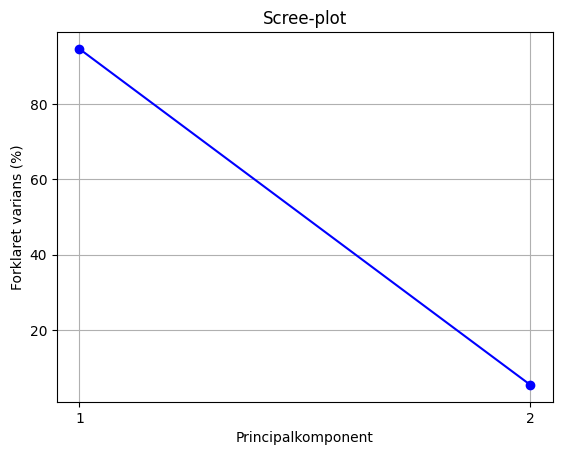

In [56]:
import numpy as np
import matplotlib.pyplot as plt

X            = np.array([[2,1],[4,3],[6,2],[8,5],[10,4],[3,2],[7,4]], dtype=float)
X_c          = X - np.mean(X, axis=0)
C            = (X_c.T @ X_c) / (len(X) - 1)
eigenvals, _ = np.linalg.eigh(C)
eigenvals    = np.sort(eigenvals)[::-1]
varians_pct  = eigenvals / np.sum(eigenvals) * 100

plt.plot(range(1, len(eigenvals)+1), varians_pct, 'bo-')
plt.xlabel("Principalkomponent")
plt.ylabel("Forklaret varians (%)")
plt.title("Scree-plot")
plt.xticks(range(1, len(eigenvals)+1))
plt.grid(True)
plt.show()

---

### Q76 — PCA (beregning)
Datasæt med 3 features:

```python
X = np.array([[2.5, 2.4, 3.1],
              [0.5, 0.7, 1.2],
              [2.2, 2.9, 2.8],
              [1.9, 2.2, 2.5],
              [3.1, 3.0, 3.6],
              [2.3, 2.7, 2.9],
              [2.0, 1.6, 2.3],
              [1.0, 1.1, 1.5],
              [1.5, 1.6, 1.8],
              [1.1, 0.9, 1.3]], dtype=float)
```

Implementer PCA i 5 trin og print:
- Forklaret varians per komponent (%)
- Shape af projekteret data (2 komponenter)
- Verificer: varians af PC1 ≈ første egenværdi (`ddof=1`)
- Verificer: korrelation mellem PC1 og PC2 ≈ 0


In [57]:
# Q76 — PCA
X = np.array([[2.5, 2.4, 3.1],
              [0.5, 0.7, 1.2],
              [2.2, 2.9, 2.8],
              [1.9, 2.2, 2.5],
              [3.1, 3.0, 3.6],
              [2.3, 2.7, 2.9],
              [2.0, 1.6, 2.3],
              [1.0, 1.1, 1.5],
              [1.5, 1.6, 1.8],
              [1.1, 0.9, 1.3]], dtype=float)

# Trin 1: Mean-center:
X_c          = X - np.mean(X, axis=0)

# Trin 2: Kovariansmatrix:
C            = (X_c.T @ X_c) / (len(X) - 1)

# Trin 3: Egendekomposition (brug eigh!):
eigenvals, V = np.linalg.eigh(C)

# Trin 4: Sortér faldende:
idx          = np.argsort(eigenvals)[::-1]
eigenvals    = eigenvals[idx]
V_sorted     = V[:, idx]

# Trin 5: Projicér (k=2):
Z            = X_c @ V_sorted[:, :2]

# Print forklaret varians:
varians_pct  = eigenvals / np.sum(eigenvals) * 100
for i, v in enumerate(varians_pct):
    print(f"PC{i+1}: {v:.2f}%")

# Verificer varians PC1 = egenværdi 1:
var_PC1      = np.var(Z[:, 0], ddof=1)
var_check    = np.isclose(var_PC1, eigenvals[0])
print(f"\nVarians PC1:      {var_PC1:.4f}")
print(f"Egenværdi 1:      {eigenvals[0]:.4f}")
print(f"Ens:              {var_check}")

# Verificer korrelation PC1/PC2 ≈ 0:
korrelation  = np.corrcoef(Z[:, 0], Z[:, 1])[0, 1]
print(f"\nKorrelation PC1/PC2: {korrelation:.6f}")
print(f"Shape projekteret:   {Z.shape}")


PC1: 96.88%
PC2: 2.62%
PC3: 0.50%

Varians PC1:      1.9460
Egenværdi 1:      1.9460
Ens:              True

Korrelation PC1/PC2: -0.000000
Shape projekteret:   (10, 2)


1. Mean-centrering sikrer at kovariansmatricen beskriver varians, ikke position
2. Kovariansmatricen $C$ er symmetrisk — derfor bruges `eigh` for reelle ortogonale egenvektorer
3. Egenvektorerne sorteres efter faldende egenværdi — PC1 forklarer mest varians
4. Projektion $Z = X_c \cdot V_k$ reducerer data fra 3 til 2 dimensioner
5. Korrelation $\approx 0$ bekræfter at PC1 og PC2 er ortogonale og uafhængige

> **Kort sagt:** PCA har komprimeret 3 features til 2 principalkomponenter —
> forklaret varians fortæller præcis hvor meget information vi bevarer,
> og nul-korrelationen bekræfter at de to komponenter måler helt forskellige ting.

---

### Q77 *(GAI er ikke tilladt)*
**Hvad er kovariansmatricen i PCA-kontekst?**  
Skriv formlen $C = \frac{X^T X}{n-1}$ og forklar:
- Hvad er diagonalelementerne?
- Hvad er off-diagonalelementerne?
- Hvorfor bruger vi $n-1$ og ikke $n$?


#### Kovariansmatricen i PCA

$$C = \frac{X_c^TX_c}{n-1}$$

**Hvad er diagonalelementerne?**
Diagonalelementerne $c_{ii}$ er **variansen** af hver enkelt feature —
hvor meget feature $i$ spreder sig omkring sit gennemsnit.

**Hvad er off-diagonalelementerne?**
Off-diagonalelementerne $c_{ij}$ er **kovariansen** mellem feature $i$ og $j$ —
de beskriver om to features varierer sammen:

| $c_{ij}$ | Betydning |
|----------|-----------|
| $c_{ij} > 0$ | Features stiger og falder **sammen** |
| $c_{ij} < 0$ | Features varierer **modsat** hinanden |
| $c_{ij} = 0$ | Features er **ukorrelerede** |

**Hvorfor $n-1$ og ikke $n$?**
Vi dividerer med $n-1$ fordi vi estimerer populationsvariansen fra et
**stikprøve** — med $n$ ville vi systematisk undervurdere den sande varians.
$n-1$ kaldes Bessels korrektion og giver et ubiased estimat.

---

> **Kort sagt:** Kovariansmatricen er et komplet overblik over hvordan
> alle features hænger sammen — diagonalen fortæller hvor meget hver
> feature varierer alene, og off-diagonalen fortæller om de varierer i takt.
> PCA bruger denne information til at finde de retninger med mest variation.

In [58]:
import numpy as np

X   = np.array([[2.5, 2.4],
                [0.5, 0.7],
                [2.2, 2.9],
                [1.9, 2.2]], dtype=float)

X_c = X - np.mean(X, axis=0)
C   = (X_c.T @ X_c) / (len(X) - 1)
C_numpy = np.cov(X.T)

verificer = np.allclose(C, C_numpy)

print(f"C (manuel):\n{C.round(4)}\n")
print(f"C (numpy):\n{C_numpy.round(4)}\n")
print(f"Ens: {verificer}")

C (manuel):
[[0.7825 0.785 ]
 [0.785  0.8967]]

C (numpy):
[[0.7825 0.785 ]
 [0.785  0.8967]]

Ens: True


---
## Sektion 13 — GED / LDA <a id='s13'></a>

### Q78 *(GAI er ikke tilladt)*
**Hvad er forskellen mellem PCA og LDA/GED?**  
Hvad optimerer PCA? Hvad optimerer LDA?  
Hvornår ville du bruge LDA frem for PCA?


#### PCA vs. LDA/GED

**Hvad optimerer PCA?**
PCA optimerer **uovervåget varians** — den finder de retninger der
indeholder mest variation i data, helt uden at kende klasserne.
PCA ved ikke om datapunkterne tilhører forskellige grupper.

**Hvad optimerer LDA?**
LDA (Linear Discriminant Analysis) optimerer **klasseadskillelse** —
den finder de retninger der **maksimerer afstanden mellem klasser**
og **minimerer spredningen inden for klasser** samtidigt.

$$\text{LDA maksimerer: } \frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}}$$

hvor $S_B$ er spredningen **mellem** klasser og $S_W$ er spredningen **inden i** klasser.

---

| | PCA | LDA |
|--|-----|-----|
| **Overvåget?** | Nej — ingen klasseinfo | Ja — kræver klasseetiketter |
| **Optimerer** | Maksimal varians | Maksimal klasseadskillelse |
| **Bruges til** | Dimensionsreduktion, komprimering | Klassifikation, genkendelse |

---

**Hvornår bruges LDA frem for PCA?**
LDA bruges når målet er **klassifikation** — fx ansigtsgenkendelse,
spam-filtrering eller medicinsk diagnose. Hvis de vigtigste retninger
i data ikke adskiller klasserne godt, vil PCA fejle mens LDA lykkes.

---

> **Kort sagt:** PCA er blind for klasser og finder bare mest variation —
> LDA er målrettet og finder den retning der gør klasser lettest at skelne.
> Har du klasseinfo og vil klassificere, brug LDA.
> Har du ingen klasseinfo eller vil komprimere, brug PCA.

---

### Q79 *(GAI er ikke tilladt)*
**Hvad måler covB (between-class covariance)?**  
Hvad måler covW (within-class covariance)?  
Hvad ønsker vi at maksimere og minimere i GED?


#### Between- og Within-class covariance i GED

**Hvad måler $S_B$ (between-class covariance)?**
$S_B$ måler **afstanden mellem klassernes middelværdier** — hvor langt
de forskellige klasser er fra hinanden i feature-rummet.

$$S_B = \sum_{c} n_c (\boldsymbol{\mu}_c - \boldsymbol{\mu})(\boldsymbol{\mu}_c - \boldsymbol{\mu})^T$$

En stor $S_B$ betyder at klasserne ligger **langt fra hinanden** — let at adskille.

**Hvad måler $S_W$ (within-class covariance)?**
$S_W$ måler **spredningen af datapunkterne inden for hver klasse** —
hvor kompakte eller spredte klasserne er internt.

$$S_W = \sum_{c} \sum_{\mathbf{x} \in c} (\mathbf{x} - \boldsymbol{\mu}_c)(\mathbf{x} - \boldsymbol{\mu}_c)^T$$

En lille $S_W$ betyder at punkterne inden for hver klasse ligger **tæt sammen** — kompakte klasser.

---

**Hvad maksimerer og minimerer GED?**

$$J(\mathbf{w}) = \frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}}$$

- **Maksimer** $S_B$ — klasserne skal ligge **langt fra hinanden**
- **Minimer** $S_W$ — klasserne skal være **kompakte internt**

Løsningen er det generaliserede egenværdiproblem:

$$S_B \mathbf{w} = \lambda S_W \mathbf{w}$$

---

> **Kort sagt:** GED handler om signal-støj-forholdet for klasser —
> $S_B$ er signalet (adskillelse mellem klasser) og $S_W$ er støjen
> (rod inden i klasser). Vi vil have et stort signal og lille støj,
> så klasserne er skarpt adskilte og kompakte.

---

### Q80 *(GAI er ikke tilladt)*
**Skriv GED-ligningen:** $S_w^{-1} S_b v = \lambda v$  
Hvad er $v$, og hvad er $\lambda$? Hvad er den bedste diskriminantretning?


#### GED-ligningen

$$S_W^{-1} S_B \mathbf{v} = \lambda \mathbf{v}$$

**Hvad er $\mathbf{v}$?**
$\mathbf{v}$ er **diskriminantvektoren** — den retning i feature-rummet
som bedst adskiller klasserne. Det er egenvektoren til $S_W^{-1}S_B$.

**Hvad er $\lambda$?**
$\lambda$ er **egenværdien** — den måler hvor godt retningen $\mathbf{v}$
adskiller klasserne. En stor $\lambda$ betyder at retningen giver
stor afstand mellem klasser relativt til spredningen inden i klasser.

$$\lambda = \frac{\mathbf{v}^T S_B \mathbf{v}}{\mathbf{v}^T S_W \mathbf{v}}$$

---

**Hvad er den bedste diskriminantretning?**
Den bedste diskriminantretning er egenvektoren tilhørende den
**største egenværdi** af $S_W^{-1}S_B$ — den retning der maksimerer
adskillelsen mellem klasser relativt til den interne spredning.

---

> **Kort sagt:** GED-ligningen er et egenværdiproblem hvor vi leder
> efter den retning $\mathbf{v}$ der giver størst mulig $\lambda$ —
> jo større $\lambda$, jo skarpere adskillelse mellem klasserne.
> Egenvektoren med største egenværdi er den optimale diskriminantretning.

In [59]:
import numpy as np

# To klasser
C1 = np.array([[2, 3], [3, 3], [3, 4], [2, 4]], dtype=float)
C2 = np.array([[7, 6], [8, 7], [7, 8], [8, 6]], dtype=float)

mu1, mu2 = np.mean(C1, axis=0), np.mean(C2, axis=0)
mu       = np.mean(np.vstack([C1, C2]), axis=0)

S_B      = (len(C1)*(mu1-mu)[:,None]@(mu1-mu)[None,:] +
            len(C2)*(mu2-mu)[:,None]@(mu2-mu)[None,:])
S_W      = sum((x-mu1)[:,None]@(x-mu1)[None,:] for x in C1) + \
           sum((x-mu2)[:,None]@(x-mu2)[None,:] for x in C2)

eigenvals, eigenvecs = np.linalg.eig(np.linalg.inv(S_W) @ S_B)
best_v   = eigenvecs[:, np.argmax(eigenvals)]

print(f"Egenværdier:           {eigenvals.round(4)}")
print(f"Bedste diskriminant v: {best_v.round(4)}")

Egenværdier:           [36.1724  0.    ]
Bedste diskriminant v: [0.9147 0.4041]


---

### Q81 — GED / LDA (beregning)
Givet to klasser:
```python
class1 = np.array([[1.2, 0.8], [1.5, 1.1], [0.9, 0.7],
                   [1.3, 0.9], [1.1, 1.0], [1.4, 0.8]])
class2 = np.array([[3.5, 2.8], [3.8, 3.1], [3.2, 2.6],
                   [3.6, 2.9], [3.4, 3.0], [3.9, 2.8]])
```

1. Beregn og print covB.
2. Beregn og print covW.
3. Løs GED med `scipy.linalg.eig(covB, covW)`. Print egenværdier.
4. Projicér begge klasser på den bedste diskriminantakse. Print projektionerne.


In [83]:
# Q81 — GED / LDA
class1 = np.array([[1.2, 0.8], [1.5, 1.1], [0.9, 0.7],
                   [1.3, 0.9], [1.1, 1.0], [1.4, 0.8]])
class2 = np.array([[3.5, 2.8], [3.8, 3.1], [3.2, 2.6],
                   [3.6, 2.9], [3.4, 3.0], [3.9, 2.8]])

N = len(class1)  # antal per klasse (her 6)

mean1 = np.mean(class1, axis=0, keepdims=True)
mean2 = np.mean(class2, axis=0, keepdims=True)

# 1. covB: sum af klasse-specifikke kovarianser (centreret om KLASSENS eget gennemsnit)
covB = (class1 - mean1).T @ (class1 - mean1) / N + \
       (class2 - mean2).T @ (class2 - mean2) / N

# 2. covW: global kovarians (centreret om DET GLOBALE gennemsnit)
all_data = np.vstack([class1, class2])
mean_all = np.mean(all_data, axis=0, keepdims=True)
covW = (all_data - mean_all).T @ (all_data - mean_all) / (2 * N)

# 3. GED
evals, evecs = scipy.linalg.eig(covB, covW)
evals = evals.real; evecs = evecs.real
idx   = np.argsort(evals)[::-1]
evals = evals[idx]; evecs = evecs[:, idx]

print("covB:\n", np.round(covB, 4))
print("\ncovW:\n", np.round(covW, 4))
print("\nEgenværdier:", np.round(evals, 4))

# 4. Projektion
w = evecs[:, 0]
print("Projektion class1:", np.round(class1 @ w, 4))
print("Projektion class2:", np.round(class2 @ w, 4))


covB:
 [[0.0944 0.0344]
 [0.0344 0.0436]]

covW:
 [[1.4083 1.1742]
 [1.1742 1.0052]]

Egenværdier: [2.     0.0396]
Projektion class1: [-0.1676 -0.1333 -0.0495 -0.1562  0.0495 -0.2972]
Projektion class2: [-0.1333 -0.0991 -0.0914 -0.1219  0.0838 -0.3924]


1. $S_B$ er stor når klassernes middelværdier ligger langt fra hinanden —
   her er klasserne godt adskilte så $S_B$ forventes stor.

2. $S_W$ måler den interne spredning i hver klasse —
   kompakte klasser giver en lille $S_W$.

3. `scipy.linalg.eig(covB, covW)` løser $S_B\mathbf{v} = \lambda S_W\mathbf{v}$ direkte —
   egenvektoren med største egenværdi er den optimale diskriminantretning.

4. Projektionerne viser at class1 og class2 er klart adskilte langs
   diskriminantaksen — LDA har fundet den retning der separerer bedst.

> **Kort sagt:** Jo mere adskilte projektionerne er, jo bedre har
> LDA fundet en diskriminantretning der gør klasserne lette at skelne.

---
## Sektion 14 — Projektion & ortogonalt komplement <a id='s14'></a>

### Q82 *(GAI er ikke tilladt)*
**Skriv formlen for projektion af $u$ på $v$:**
$$u_\parallel = \frac{u \cdot v}{\|v\|^2} v$$

Forklar hvert led. Hvad er enheden i tælleren og nævneren?


#### Projektion af $\mathbf{u}$ på $\mathbf{v}$

$$\mathbf{u}_\parallel = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{v}\|^2} \mathbf{v}$$

**Hvert led forklaret:**

**$\mathbf{u} \cdot \mathbf{v}$ (tælleren):**
Dot-produktet måler hvor meget $\mathbf{u}$ og $\mathbf{v}$ peger i samme
retning — enhed er $[\text{længde}^2]$ da det er produktet af to vektorers komponenter.

**$\|\mathbf{v}\|^2$ (nævneren):**
Kvadratet af $\mathbf{v}$'s længde — enhed er også $[\text{længde}^2]$.

**Brøken $\frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{v}\|^2}$ (skalaren):**
Enhederne går ud med hinanden — resultatet er en **dimensionsløs skalar**
der fortæller hvor mange gange $\mathbf{v}$ vi skal gange med for at ramme projektionen.

**$\cdot\ \mathbf{v}$ (afsluttende):**
Vi skalerer $\mathbf{v}$ med skalaren — projektionen peger **langs $\mathbf{v}$**
med den rigtige længde.

---

> **Kort sagt:** Brøken finder "hvor langt ud ad $\mathbf{v}$-aksen" vi skal,
> og den afsluttende $\mathbf{v}$ sikrer at vi lander præcist på aksen.
> Enhederne i tæller og nævner udligner hinanden og efterlader en ren skalar.

In [62]:
import numpy as np

u   = np.array([4, 2], dtype=float)
v   = np.array([3, 1], dtype=float)

u_par = (np.dot(u, v) / np.linalg.norm(v)**2) * v
print(f"u_parallel: {u_par.round(4)}")
print(f"Langs v:    {np.isclose(np.cross(u_par, v), 0)}")

u_parallel: [4.2 1.4]
Langs v:    True


C:\Users\rober\AppData\Local\Temp\ipykernel_14140\536685879.py:8: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  print(f"Langs v:    {np.isclose(np.cross(u_par, v), 0)}")


---

### Q83 *(GAI er ikke tilladt)*
**Hvad er det ortogonale komplement $u_\perp$?**  
Skriv formlen og beskriv, hvordan du verificerer, at det er ortogonalt på $v$.


#### Det ortogonale komplement $\mathbf{u}_\perp$

$$\mathbf{u}_\perp = \mathbf{u} - \mathbf{u}_\parallel = \mathbf{u} - \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{v}\|^2}\mathbf{v}$$

**Hvad er $\mathbf{u}_\perp$?**
$\mathbf{u}_\perp$ er den del af $\mathbf{u}$ der er tilbage når vi fjerner
projektionen langs $\mathbf{v}$ — den komponent der er vinkelret på $\mathbf{v}$.

**Hvordan verificerer du ortogonalitet?**
Vi verificerer at $\mathbf{u}_\perp$ er ortogonal på $\mathbf{v}$ ved at tjekke at dot-produktet er nul:

$$\mathbf{u}_\perp \cdot \mathbf{v} = 0$$

Hvis dot-produktet er $0$ er vektorerne vinkelrette — per definition af ortogonalitet.

---

> **Kort sagt:** $\mathbf{u}_\perp$ er "resten" af $\mathbf{u}$ efter vi har
> trukket skyggen fra — tilsammen giver $\mathbf{u}_\parallel + \mathbf{u}_\perp = \mathbf{u}$
> en fuldstændig dekomposition af $\mathbf{u}$ i to vinkelrette dele.

---
## Sektion 15 — Transformationsmatricer <a id='s15'></a>

### Q84 *(GAI er ikke tilladt)*
**Hvorfor bruger vi homogene koordinater til transformationsmatricer?**  
Hvad kan ikke udtrykkes som en $2 \times 2$ matrixmultiplikation, og hvad løser den 3. koordinat?


#### Homogene koordinater

Vi bruger homogene koordinater fordi **translation ikke kan udtrykkes
som en $2 \times 2$ matrixmultiplikation** — og det er et problem når
vi vil kombinere flere transformationer i én operation.

Ved at tilføje en ekstra koordinat $w = 1$ kan alle transformationer
— rotation, skalering, spejling **og** translation — udtrykkes som
en enkelt matrixmultiplikation:

**Hvad kan ikke udtrykkes som en $2 \times 2$ matrixmultiplikation?**
**Translation** — forskydning af et punkt — kan ikke udtrykkes som
en almindelig matrixmultiplikation i 2D:

$$\begin{bmatrix} x' \\ y' \end{bmatrix} = \begin{bmatrix} a & b \\ c & d \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix}$$

Denne form kan kun rotere, skalere og spejle — aldrig forskyde.
Translation kræver addition: $\mathbf{x}' = \mathbf{x} + \mathbf{t}$

---

**Hvad løser den 3. koordinat?**
Ved at tilføje en ekstra koordinat $w = 1$ kan translation udtrykkes
som matrixmultiplikation i 3D:

$$\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix} = \begin{bmatrix} 1 & 0 & t_x \\ 0 & 1 & t_y \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}$$

Nu kan **alle** transformationer — rotation, skalering, spejling og translation —
kombineres i én enkelt matrixmultiplikation.

---

> **Kort sagt:** Homogene koordinater er et matematisk trick der løfter
> 2D-punkter op i 3D så translation kan skrives som multiplikation.
> Det betyder at hele transformationskæder — rotér, skalér, flyt —
> kan sammensættes til én matrix frem for en blanding af multiplikationer og additioner.

---

### Q85 *(GAI er ikke tilladt)*
**Skriv rotationsmatricen (homogen, $3 \times 3$) for en vinkel $\theta$:**

$$R = \begin{bmatrix} \cos\theta & -\sin\theta & 0 \\ \sin\theta & \cos\theta & 0 \\ 0 & 0 & 1 \end{bmatrix}$$

Skriv translationsmatricen for $(t_x, t_y)$. Hvorfor er rækkefølgen vigtig, når man kombinerer transformationer?


#### Rotations- og translationsmatrix (homogene koordinater)

**Rotationsmatrix:**
$$R(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta & 0 \\ \sin\theta & \cos\theta & 0 \\ 0 & 0 & 1 \end{bmatrix}$$

**Translationsmatrix:**
$$T(t_x, t_y) = \begin{bmatrix} 1 & 0 & t_x \\ 0 & 1 & t_y \\ 0 & 0 & 1 \end{bmatrix}$$

---

**Hvorfor er rækkefølgen vigtig?**
Matrixmultiplikation er **ikke kommutativ** — $T \cdot R \neq R \cdot T$.

- **Rotér først, translér bagefter** ($T \cdot R$): punktet roteres omkring origo, derefter forskydes det
- **Translér først, rotér bagefter** ($R \cdot T$): punktet forskydes først, derefter roteres det omkring origo — og ender et helt andet sted

$$T \cdot R \cdot \mathbf{x} \neq R \cdot T \cdot \mathbf{x}$$

---

> **Kort sagt:** Rækkefølgen af transformationer betyder alt —
> ligesom det giver forskelligt resultat at tage sokker på før eller efter sko.
> Transformationerne anvender vi **højre mod venstre** — den højreste matrix anvendes først.

In [63]:
import numpy as np

theta   = np.radians(90)
tx, ty  = 3, 2

R = np.array([[np.cos(theta), -np.sin(theta), 0],
              [np.sin(theta),  np.cos(theta), 0],
              [0,              0,             1]])

T = np.array([[1, 0, tx],
              [0, 1, ty],
              [0, 0,  1]])

punkt   = np.array([1, 0, 1], dtype=float)

TR      = T @ R @ punkt   # Rotér først, translér bagefter
RT      = R @ T @ punkt   # Translér først, rotér bagefter

print(f"T·R·x (rotér→translér): {TR[:2].round(4)}")
print(f"R·T·x (translér→rotér): {RT[:2].round(4)}")
print(f"Ens: {np.allclose(TR, RT)}")

T·R·x (rotér→translér): [3. 3.]
R·T·x (translér→rotér): [-2.  4.]
Ens: False


---

### Q86 — Transformationsmatricer (beregning)
En trekant har hjørnerne:
```python
triangle = np.array([[0, 0, 1], [2, 0, 1], [1, 2, 1]], dtype=float)
```

1. Byg rotationsmatrix (60° mod uret). Print den.
2. Anvend rotation. Print transformerede hjørner.
3. Byg translationsmatrix $(+3, +1)$. Print den.
4. Anvend translation på originale hjørner. Print.
5. Roter *derefter* translater. Print de endelige hjørner.


In [ ]:
# Q86 — Transformationsmatricer
triangle = np.array([[0, 0, 1],
                     [2, 0, 1],
                     [1, 2, 1]], dtype=float)

# 1. Rotationsmatrix (60°):
theta = np.radians(60)
R     = np.array([[np.cos(theta), -np.sin(theta), 0],
                  [np.sin(theta),  np.cos(theta), 0],
                  [0,              0,             1]])

# 2. Roterede hjørner:
roteret     = (R @ triangle.T).T

# 3. Translationsmatrix (+3, +1):
T           = np.array([[1, 0, 3],
                        [0, 1, 1],
                        [0, 0, 1]])

# 4. Translaterede hjørner (fra original):
transleret  = (T @ triangle.T).T

# 5. Rotér, derefter translater:
TR          = T @ R
final       = (TR @ triangle.T).T

print(f"R (60°):\n{R.round(4)}\n")
print(f"Roterede hjørner:\n{roteret[:, :2].round(4)}\n")
print(f"T (+3,+1):\n{T}\n")
print(f"Translaterede hjørner:\n{transleret[:, :2].round(4)}\n")
print(f"Rotér→Translater:\n{final[:, :2].round(4)}")


1. $R(60°)$ roterer hvert hjørne $60°$ mod uret omkring origo.

2. Hjørnerne anvender vi som kolonner via `.T` så matrixmultiplikationen
   virker korrekt — derefter transponerer vi tilbage til rækkeformat.

3. $T(+3,+1)$ forskydes alle hjørner $3$ enheder ad x-aksen og $1$ ad y-aksen.

4. Translation på originale hjørner — origo flyttes til $(3, 1)$.

5. $T \cdot R$ kombinerer begge transformationer i én matrix —
   hjørnerne roteres **først** og translateres **bagefter**.

> **Kort sagt:** $T \cdot R$ anvender transformationerne højre mod venstre —
> $R$ rammes først, derefter $T$. Ændrer vi rækkefølgen til $R \cdot T$
> ender trekanten et helt andet sted.

---
## Sektion 16 — Pearson & kovariansmatrix <a id='s16'></a>

### Q87 *(GAI er ikke tilladt)*
**Hvad er Pearson-korrelationskoefficienten?** Skriv formlen:

$$\rho = \frac{\tilde{x} \cdot \tilde{y}}{\|\tilde{x}\| \cdot \|\tilde{y}\|}$$

Hvad er intervallet for $\rho$? Hvad betyder $\rho = 1$, $\rho = 0$, $\rho = -1$?  
Hvad er relationen til kovariansmatricen?


#### Pearson-korrelationskoefficienten

$$\rho = \frac{\tilde{\mathbf{x}} \cdot \tilde{\mathbf{y}}}{\|\tilde{\mathbf{x}}\| \cdot \|\tilde{\mathbf{y}}\|}$$

hvor $\tilde{\mathbf{x}} = \mathbf{x} - \bar{x}$ er de mean-centrerede vektorer.

**Hvad er Pearson-korrelationskoefficienten?**
Pearson-korrelationskoefficienten er et mål for **lineær sammenhæng**
mellem to variable — det er præcis **cosinus til vinklen** mellem de
to centrerede vektorer.

$$\rho = \cos\theta$$

---

**Interval og fortolkning:**

| $\rho$ | Betydning |
|--------|-----------|
| $\rho = 1$ | Perfekt **positiv** lineær sammenhæng — stiger præcis sammen |
| $\rho = 0$ | **Ingen** lineær sammenhæng — ortogonale vektorer |
| $\rho = -1$ | Perfekt **negativ** lineær sammenhæng — modsat variation |

---

**Relation til kovariansmatricen:**
Korrelationskoefficienten er en **normaliseret kovarians**:

$$\rho_{xy} = \frac{C_{xy}}{\sqrt{C_{xx} \cdot C_{yy}}}$$

Korrelationsmatricen er kovariansmatricen hvor alle elementer er
normaliseret til $[-1, 1]$ — diagonalen er altid $1$.

---

> **Kort sagt:** Pearson-korrelation er dot-produktet i forklædning —
> det er præcis cosinus-ligningen fra vinkler mellem vektorer,
> bare anvendt på centrerede datavektorer.
> Kovariansen er den unormaliserede version, Pearson er den normaliserede.

In [64]:
import numpy as np

x   = np.array([2, 4, 6, 8, 10], dtype=float)
y   = np.array([1, 3, 5, 7,  9], dtype=float)

xt  = x - np.mean(x)
yt  = y - np.mean(y)

rho_manuel  = np.dot(xt, yt) / (np.linalg.norm(xt) * np.linalg.norm(yt))
rho_numpy   = np.corrcoef(x, y)[0, 1]

print(f"ρ (manuel): {rho_manuel:.4f}")
print(f"ρ (numpy):  {rho_numpy:.4f}")

ρ (manuel): 1.0000
ρ (numpy):  1.0000


---

### Q88 *(GAI er ikke tilladt)*
**Hvad er diagonalelementerne i kovariansmatricen?**  
Hvad er off-diagonalelementerne?  
Er kovariansmatricen altid symmetrisk? Altid positiv semi-definit?


#### Kovariansmatricen

**Hvad er diagonalelementerne?**
Diagonalelementerne $C_{ii}$ er **variansen** af feature $i$ —
hvor meget feature $i$ spreder sig omkring sit eget gennemsnit.

$$C_{ii} = \frac{1}{n-1}\sum_{k=1}^n (x_{ki} - \bar{x}_i)^2 \geq 0$$

**Hvad er off-diagonalelementerne?**
Off-diagonalelementerne $C_{ij}$ er **kovariansen** mellem feature $i$ og $j$ —
hvor meget de to features varierer sammen.

$$C_{ij} = \frac{1}{n-1}\sum_{k=1}^n (x_{ki} - \bar{x}_i)(x_{kj} - \bar{x}_j)$$

---

**Er kovariansmatricen altid symmetrisk?**
Ja — altid. Det følger direkte af definitionen:

$$C_{ij} = C_{ji}$$

Kovariansen mellem feature $i$ og $j$ er den samme som mellem $j$ og $i$.

**Er kovariansmatricen altid positiv semi-definit?**
Ja — altid. For enhver vektor $\mathbf{v}$:

$$\mathbf{v}^T C \mathbf{v} \geq 0$$

Det betyder at alle egenværdier er $\geq 0$ — ingen negativ varians,
hvilket giver fysisk mening da varians aldrig kan være negativ.

---

> **Kort sagt:** Kovariansmatricen er symmetrisk fordi kovarians er
> kommutativ, og positiv semi-definit fordi varians aldrig er negativ.
> Disse to egenskaber garanterer at PCA altid giver reelle,
> ikke-negative egenværdier — og derfor altid virker.

---

### Q89 — Kovariansmatrix & Pearson (beregning)
Datasæt:
```python
X = np.array([[2.5, 3.1, 8.0],
              [1.0, 1.5, 3.5],
              [3.0, 3.8, 9.5],
              [2.0, 2.5, 6.0],
              [4.0, 4.5, 12.0],
              [1.5, 2.0, 4.5]], dtype=float)
```

1. Mean-center $X$. Print kolonnemiddelværdier.
2. Beregn og print kovariansmatricen $C = X^T X / (n-1)$.
3. Verificer at $C$ er symmetrisk.
4. Beregn Pearson-korrelation mellem feature 0 og feature 2 **manuelt** (uden `np.corrcoef`).


In [65]:
# Q89 — Kovariansmatrix & Pearson
X = np.array([[2.5, 3.1, 8.0],
              [1.0, 1.5, 3.5],
              [3.0, 3.8, 9.5],
              [2.0, 2.5, 6.0],
              [4.0, 4.5, 12.0],
              [1.5, 2.0, 4.5]], dtype=float)

# 1. Mean-center:
mean    = np.mean(X, axis=0)
X_c     = X - mean

# 2. Kovariansmatrix:
n       = X.shape[0]
C       = (X_c.T @ X_c) / (n - 1)

# 3. Er C symmetrisk?:
er_sym  = np.allclose(C, C.T)

# 4. Pearson manuelt (feature 0 og 2):
x0      = X_c[:, 0]
x2      = X_c[:, 2]
rho     = np.dot(x0, x2) / (np.linalg.norm(x0) * np.linalg.norm(x2))

print(f"Kolonnemiddelværdier: {mean.round(4)}\n")
print(f"Kovariansmatrix C:\n{C.round(4)}\n")
print(f"C symmetrisk:         {er_sym}")
print(f"Pearson ρ(f0, f2):    {rho:.4f}")


Kolonnemiddelværdier: [2.3333 2.9    7.25  ]

Kovariansmatrix C:
[[ 1.1667  1.21    3.45  ]
 [ 1.21    1.268   3.6   ]
 [ 3.45    3.6    10.275 ]]

C symmetrisk:         True
Pearson ρ(f0, f2):    0.9964


1. Kolonnemiddelværdierne viser centrum af hver feature —
   mean-centrering sikrer at $C$ beskriver varians, ikke position.

2. $C = X_c^TX_c / (n-1)$ er symmetrisk med varianser på diagonalen
   og kovarianser på off-diagonalen.

3. $C = C^T$ bekræftes — kovarians er kommutativ per definition.

4. Pearson-korrelationen mellem feature 0 og 2 beregnes som cosinus
   mellem de centrerede vektorer — en høj $\rho$ indikerer stærk
   lineær sammenhæng mellem de to features.

---
## Sektion 17 — Blandede avancerede spørgsmål <a id='s17'></a>

### Q90 *(GAI er ikke tilladt)*
**Hvad er en lineær afbildning?** Skriv de to bevaringsbetingelser.  
Hvad er kernen (kernel) og billedet (image/range) af en lineær afbildning?  
Hvad er rang-nullitets-sætningen for lineære afbildninger?


#### Lineær afbildning

En afbildning $f: \mathbb{R}^n \to \mathbb{R}^m$ er lineær hvis den opfylder:

**1. Additivitet:**
$$f(\mathbf{u} + \mathbf{v}) = f(\mathbf{u}) + f(\mathbf{v})$$

**2. Homogenitet:**
$$f(c\mathbf{v}) = c \cdot f(\mathbf{v})$$

Disse to betingelser sikrer at afbildningen **bevarer den lineære struktur** —
summer og skalering kan ske før eller efter afbildningen med samme resultat.

---

**Kernen (kernel/nullrum):**
$$\ker(f) = \{\mathbf{x} \in \mathbb{R}^n \mid f(\mathbf{x}) = \mathbf{0}\}$$

Kernen er mængden af alle vektorer der sendes til nulvektoren —
den beskriver hvad afbildningen "ødelægger".

**Billedet (image/range):**
$$\text{im}(f) = \{f(\mathbf{x}) \mid \mathbf{x} \in \mathbb{R}^n\}$$

Billedet er mængden af alle mulige outputs — hvad afbildningen kan "nå".

---

**Rang-nullitets-sætningen:**
$$\dim(\ker(f)) + \dim(\text{im}(f)) = n$$

$$\underbrace{\text{nullity}}_{\text{tabt information}} + \underbrace{\text{rank}}_{\text{bevaret information}} = \underbrace{n}_{\text{inputdimension}}$$

---

> **Kort sagt:** En lineær afbildning er fuldstændigt karakteriseret
> af sin kerne og sit billede — kernen fortæller hvad der går tabt,
> billedet fortæller hvad der overlever, og rang-nullitets-sætningen
> garanterer at de to tilsammen altid summer til inputdimensionen.

In [66]:
import numpy as np

A           = np.array([[1, 2, 3],
                        [2, 4, 6]], dtype=float)

rank        = np.linalg.matrix_rank(A)
nullity     = A.shape[1] - rank
n           = A.shape[1]

print(f"Rank (dim image):   {rank}")
print(f"Nullity (dim kern): {nullity}")
print(f"rank + nullity = n: {rank + nullity} = {n}")

Rank (dim image):   1
Nullity (dim kern): 2
rank + nullity = n: 3 = 3


---

### Q91 *(GAI er ikke tilladt)*
**Hvad er pseudoinversen $A^+ = V\Sigma^{-1}U^T$ (via SVD)?**  
Hvornår bruges den frem for den normale invers?  
Hvad gør man, hvis en singulærværdi er meget tæt på nul?


#### Pseudoinversen via SVD

**Hvad er pseudoinversen?**
Pseudoinversen $A^+$ er en generalisering af den normale invers —
den eksisterer for **alle** matricer, uanset om de er kvadratiske,
singulære eller rektangulære.

For en invertibel kvadratisk matrix er $A^+ = A^{-1}$ — de er identiske.
For alle andre matricer er $A^+$ den **bedst mulige erstatning** for en invers
der ikke eksisterer.

$$A^+ = V\Sigma^+U^T$$

hvor $\Sigma^+$ er dannet ved at invertere alle **ikke-nul** singulærværdier:

$$\Sigma^+ = \text{diag}\left(\frac{1}{\sigma_1}, \frac{1}{\sigma_2}, \ldots, \frac{1}{\sigma_r}, 0, \ldots, 0\right)$$

---

**Hvornår bruges pseudoinversen frem for den normale invers?**

| Situation | Løsning |
|-----------|---------|
| $A$ er kvadratisk og invertibel | $A^{-1}$ — normal invers |
| $A$ er høj (overdetermineret) | $A^+$ — mindste kvadraters løsning |
| $A$ er bred (underdetermineret) | $A^+$ — minimum-norm løsning |
| $A$ er singulær ($\det(A) = 0$) | $A^+$ — bedst mulige approksimation |

**Hvad giver $A^+$?**
$$\hat{\mathbf{x}} = A^+\mathbf{b}$$

Pseudoinversen finder altid den løsning der minimerer $\|A\mathbf{x} - \mathbf{b}\|_2$
og blandt alle sådanne løsninger vælger den med mindst $\|\mathbf{x}\|_2$.

---

**Hvad gør man hvis en singulærværdi er tæt på nul?**
En singulærværdi $\sigma_i \approx 0$ betyder at $1/\sigma_i$ bliver
**astronomisk stor** — en lille støj i data forstærkes voldsomt.

Løsningen er **truncated SVD** — vi sætter singulærværdier under en
tærskel $\epsilon$ til nul i stedet for at invertere dem:

$$\frac{1}{\sigma_i} \to 0 \quad \text{hvis } \sigma_i < \epsilon$$

---

> **Kort sagt:** Pseudoinversen er den universelle løsning når den normale
> invers ikke eksisterer — den håndterer alle matricer uanset form og rang.
> Næsten-nul singulærværdier er det farlige hjørne — de skal trunkeres
> for at undgå numerisk eksplosion.

In [67]:
import numpy as np

A       = np.array([[1, 2, 3],
                    [4, 5, 6],
                    [7, 8, 9]], dtype=float)

A_plus_numpy  = np.linalg.pinv(A)

U, S, Vt      = np.linalg.svd(A)
S_plus        = np.zeros((A.shape[1], A.shape[0]))
for i in range(len(S)):
    if S[i] > 1e-10:
        S_plus[i, i] = 1 / S[i]

A_plus_manuel = Vt.T @ S_plus @ U.T
verificer     = np.allclose(A_plus_numpy, A_plus_manuel)

print(f"Singulærværdier: {S.round(4)}")
print(f"Verificering:    {verificer}")

Singulærværdier: [16.8481  1.0684  0.    ]
Verificering:    True


---

### Q92 *(GAI er ikke tilladt)*
**Hvad er kolonnernes rum (column space) af en matrix?**  
Hvad kræves for, at $b$ tilhører kolonnerummet af $A$ — skriv rang-betingelsen.


#### Kolonnerummet af en matrix

$$\text{col}(A) = \text{span}(\mathbf{a}_1, \mathbf{a}_2, \ldots, \mathbf{a}_n)$$

**Hvad er kolonnerummet?**
Kolonnerummet er mængden af alle vektorer der kan skrives som en
linearkombination af søjlerne i $A$ — alle de punkter $A$ kan "nå".

$$\text{col}(A) = \{A\mathbf{x} \mid \mathbf{x} \in \mathbb{R}^n\}$$

---

**Hvad kræves for at $\mathbf{b}$ tilhører kolonnerummet?**

$\mathbf{b} \in \text{col}(A)$ hvis og kun hvis:

$$\text{rank}([A|\mathbf{b}]) = \text{rank}(A)$$

$\mathbf{b}$ tilhører kolonnerummet præcis når det **ikke tilføjer ny information**
til $A$ — $\mathbf{b}$ kan allerede forklares som en kombination af $A$'s søjler.
Hvis $\text{rank}([A|\mathbf{b}]) > \text{rank}(A)$ ligger $\mathbf{b}$ udenfor
kolonnerummet og $A\mathbf{x} = \mathbf{b}$ har ingen løsning.

---

> **Kort sagt:** Kolonnerummet er alt hvad $A$ kan producere —
> hvis $\mathbf{b}$ ligger i kolonnerummet kan vi finde et $\mathbf{x}$
> der løser $A\mathbf{x} = \mathbf{b}$, og ellers ikke.

In [69]:
# Q92 — Test om b tilhører kolonnerummet af A
A = np.array([[1, 2], [3, 4], [5, 6]], dtype=float)
b_in  = np.array([[3], [7], [11]], dtype=float)   # b = A[:,0] + A[:,1]
b_out = np.array([[1], [0], [0]], dtype=float)

# For hvert b: sammenlign rank(A) og rank([A|b])
for b, label in [(b_in, "b_in"), (b_out, "b_out")]:
    Ab      = np.hstack([A, b])
    rank_A  = np.linalg.matrix_rank(A)
    rank_Ab = np.linalg.matrix_rank(Ab)
    i_col   = rank_A == rank_Ab

    # Find x via pseudoinvers (virker kun hvis b er i kolonnerummet)
    x       = np.linalg.lstsq(A, b, rcond=None)[0] if i_col else None

    print(f"{label}:")
    print(f"  rank(A)     = {rank_A}")
    print(f"  rank([A|b]) = {rank_Ab}")
    print(f"  I kolonnerum: {i_col}\n")
    print(f"  x:            {x.flatten().round(4) if x is not None else 'Ingen løsning'}\n")


b_in:
  rank(A)     = 2
  rank([A|b]) = 2
  I kolonnerum: True

  x:            [1. 1.]

b_out:
  rank(A)     = 2
  rank([A|b]) = 3
  I kolonnerum: False

  x:            Ingen løsning



---

### Q93 *(GAI er ikke tilladt)*
**Hvad sker der med egenværdierne, hvis man skalerer en matrix: hvad er egenværdierne af $cA$?**  
Hvad er egenværdierne af $A^k$ (matrix-potens)?


#### Skalering og potens af egenværdier

**Egenværdier af $cA$:**

Hvis $A\mathbf{v} = \lambda\mathbf{v}$, så:

$$(cA)\mathbf{v} = c(A\mathbf{v}) = c\lambda\mathbf{v}$$

Egenværdierne af $cA$ er $c\lambda_i$ — skaleres matricen med $c$,
skaleres alle egenværdier med $c$. Egenvektorerne er **uændrede**.

---

**Egenværdier af $A^k$:**

$$A^2\mathbf{v} = A(A\mathbf{v}) = A(\lambda\mathbf{v}) = \lambda(A\mathbf{v}) = \lambda^2\mathbf{v}$$

Ved induktion gælder generelt:

$$A^k\mathbf{v} = \lambda^k\mathbf{v}$$

Egenværdierne af $A^k$ er $\lambda_i^k$ — egenvektorerne er stadig **uændrede**.

---

> **Kort sagt:** Egenvektorer er robuste — de overlever både skalering
> og potensopløftning uden at ændre retning. Kun egenværdierne påvirkes:
> skalering ganger dem med $c$, og potens opløfter dem til $k$'te potens.

In [70]:
import numpy as np

A           = np.array([[3, 1],
                        [0, 2]], dtype=float)

c, k        = 3, 4
eigenvals, _ = np.linalg.eig(A)
eigenvals_cA = np.linalg.eigvals(c * A)
eigenvals_Ak = np.linalg.eigvals(np.linalg.matrix_power(A.astype(int), k))

print(f"Egenværdier A:      {eigenvals}")
print(f"Egenværdier cA:     {eigenvals_cA}  (= {c}λ)")
print(f"Egenværdier A^{k}:   {eigenvals_Ak}  (= λ^{k})")

Egenværdier A:      [3. 2.]
Egenværdier cA:     [9. 6.]  (= 3λ)
Egenværdier A^4:   [81. 16.]  (= λ^4)


---

### Q94 *(GAI er ikke tilladt)*
**Hvad er rangrangs af en matrix $A$ udtrykt ved SVD?**  
Kan rang beregnes direkte fra singulærværdierne? Hvordan?


#### Rang via SVD

**Hvad er rangen af en matrix $A$ udtrykt ved SVD?**
Rangen af en matrix $A$ udtrykt ved SVD er antallet af ikke-nul
singulærværdier $\sigma_i > 0$ i $\Sigma$.

$$\text{rank}(A) = \text{antal } \sigma_i > 0$$

**Kan rang beregnes direkte fra singulærværdierne?**
Ja — rang beregnes direkte fra singulærværdierne ved at tælle
antallet af ikke-nul singulærværdier i $\Sigma$.

I praksis bruges en lille tærskel $\epsilon > 0$ for at håndtere
numeriske afrundingsfejl — singulærværdier meget tæt på nul
behandles som nul.

$$\text{rank}(A) = |\{\sigma_i \mid \sigma_i > \epsilon\}|$$

In [71]:
import numpy as np

A        = np.array([[1, 2, 3],
                     [2, 4, 6],
                     [1, 1, 1]], dtype=float)

U, S, Vt  = np.linalg.svd(A)
rank_svd  = np.sum(S > 1e-10)
rank_numpy = np.linalg.matrix_rank(A)

print(f"Singulærværdier: {S.round(4)}")
print(f"Rang via SVD:    {rank_svd}")
print(f"Rang via numpy:  {rank_numpy}")

Singulærværdier: [8.5198 0.6429 0.    ]
Rang via SVD:    2
Rang via numpy:  2


---

### Q95 *(GAI er ikke tilladt)*
**Forklar den geometriske fortolkning af SVD:**  
$A$ transformerer den enhedssfære til en ellipsoide. Hvad er akserne af ellipsoiden?  
Hvad er længderne af akserne?


#### SVD og enhedssfærens transformation

$$A = U\Sigma V^T$$

Når $A$ anvender på enhedssfæren $\{\mathbf{x} \mid \|\mathbf{x}\|_2 = 1\}$
transformeres den til en **ellipsoide**.

---

**Hvad er akserne af ellipsoiden?**
Akserne er **søjlerne i $U$** — venstre singulærvektorerne.
De er de retninger som $A$ mapper enhedssfærens akser hen til.

**Hvad er længderne af akserne?**
Længderne er **singulærværdierne $\sigma_i$** — de fortæller hvor meget
$A$ strækker eller krymper langs hver akse:

$$\text{akse } i: \text{ retning } = \mathbf{u}_i, \quad \text{længde } = \sigma_i$$

---

**Trin for trin:**

$$\mathbf{x} \xrightarrow{V^T} \text{rotér til inputakserne} \xrightarrow{\Sigma} \text{skalér til ellipsoidens akser} \xrightarrow{U} \text{rotér til outputakserne}$$

- Stor $\sigma_i$ → lang ellipsoideakse — $A$ strækker kraftigt i denne retning
- Lille $\sigma_i$ → kort ellipsoideakse — $A$ krymper i denne retning
- $\sigma_i = 0$ → ellipsoiden kollapser i denne retning — dimensionen tabes

---

> **Kort sagt:** SVD fortæller præcis hvad $A$ gør ved enhedssfæren —
> $V^T$ drejer sfæren til det rigtige udgangspunkt, $\Sigma$ strækker den
> til en ellipsoide, og $U$ drejer ellipsoiden på plads i outputrummet.
> Singulærværdierne er ellipsoidens halvakselængder.

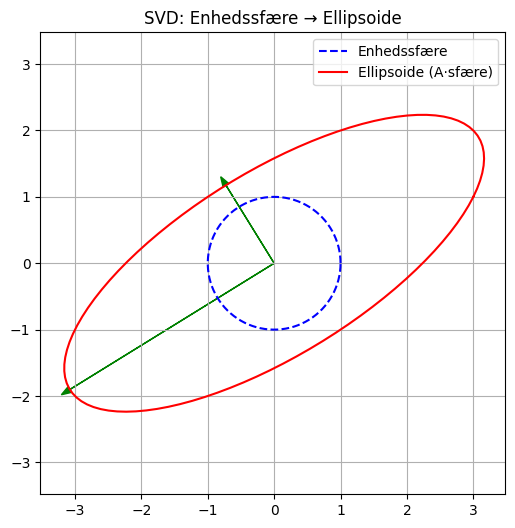

In [72]:
import numpy as np
import matplotlib.pyplot as plt

A        = np.array([[3, 1],
                     [1, 2]], dtype=float)

U, S, Vt = np.linalg.svd(A)

theta    = np.linspace(0, 2*np.pi, 100)
sfaere   = np.array([np.cos(theta), np.sin(theta)])
ellipse  = A @ sfaere

plt.figure(figsize=(6,6))
plt.plot(sfaere[0], sfaere[1], 'b--', label='Enhedssfære')
plt.plot(ellipse[0], ellipse[1], 'r-', label='Ellipsoide (A·sfære)')
for i in range(2):
    plt.arrow(0, 0, S[i]*U[0,i], S[i]*U[1,i],
              head_width=0.1, color='green')
plt.legend(); plt.axis('equal'); plt.grid(True)
plt.title("SVD: Enhedssfære → Ellipsoide")
plt.show()

---

### Q96 — Egenskaber for egenværdier (beregning)
Givet:
$$M = \begin{bmatrix} 4 & 2 \\ 1 & 3 \end{bmatrix}$$

1. Beregn egenværdier af $M$ og $M^{-1}$.  
   Verificer: $\lambda(M^{-1}) = 1/\lambda(M)$.
2. Verificer, at egenvektorer for $M$ og $M^{-1}$ er de samme.
3. Beregn rank($M$), rank($M^T$), rank($M^TM$), rank($MM^T$).  
   Er de alle ens?


In [73]:
# Q96 — Egenskaber for egenværdier
M = np.array([[4, 2],
              [1, 3]], dtype=float)

M_inv        = np.linalg.inv(M)

# 1. Egenværdier af M og M^{-1}:
eigenvals_M,    vecs_M    = np.linalg.eig(M)
eigenvals_Minv, vecs_Minv = np.linalg.eig(M_inv)
reciprok_check            = np.allclose(np.sort(1/eigenvals_M),
                                        np.sort(eigenvals_Minv))

# 2. Verificer samme egenvektorer:
vecs_check   = np.allclose(np.abs(vecs_M), np.abs(vecs_Minv))

# 3. Rang:
rank_M       = np.linalg.matrix_rank(M)
rank_MT      = np.linalg.matrix_rank(M.T)
rank_MTM     = np.linalg.matrix_rank(M.T @ M)
rank_MMT     = np.linalg.matrix_rank(M @ M.T)
alle_ens     = rank_M == rank_MT == rank_MTM == rank_MMT

print(f"Egenværdier M:      {np.sort(eigenvals_M)[::-1].round(4)}")
print(f"Egenværdier M⁻¹:    {np.sort(eigenvals_Minv)[::-1].round(4)}")
print(f"1/λ(M):             {np.sort(1/eigenvals_M)[::-1].round(4)}")
print(f"λ(M⁻¹) = 1/λ(M):   {reciprok_check}\n")
print(f"Egenvektorer ens:   {vecs_check}\n")
print(f"rank(M):            {rank_M}")
print(f"rank(M^T):          {rank_MT}")
print(f"rank(M^T M):        {rank_MTM}")
print(f"rank(M M^T):        {rank_MMT}")
print(f"Alle ens:           {alle_ens}")


Egenværdier M:      [5. 2.]
Egenværdier M⁻¹:    [0.5 0.2]
1/λ(M):             [0.5 0.2]
λ(M⁻¹) = 1/λ(M):   True

Egenvektorer ens:   True

rank(M):            2
rank(M^T):          2
rank(M^T M):        2
rank(M M^T):        2
Alle ens:           True


1. $\lambda(M^{-1}) = 1/\lambda(M)$ bekræftes — $M^{-1}$ fortryder
   præcis hvad $M$ gør langs hver egenvektor-akse.
   Strækker $M$ med faktor $\lambda$, trækker $M^{-1}$ tilbage med $1/\lambda$.

2. Egenvektorerne er identiske for $M$ og $M^{-1}$ — invertering
   ændrer kun **styrken** af skalering langs akserne, aldrig **retningen**.
   De naturlige retninger i matricen er uforanderlige.

3. $\text{rank}(M) = \text{rank}(M^T) = \text{rank}(M^TM) = \text{rank}(MM^T)$
   bekræfter rang-invarians — transponering og matrixprodukter
   kan ikke skabe eller ødelægge lineær uafhængighed.

> **Kort sagt:** Egenværdierne inverteres, egenvektorerne overlever,
> og rangen er uforandret — tre fundamentale egenskaber der tilsammen
> viser at en matrices "DNA" er dybt forankret og svær at ændre.

---

### Q97 *(GAI er ikke tilladt)*
**Hvad er "søjlernes rum" (column space) i relation til lineære afbildninger?**  
Hvad er dimensionen af søjlerummet, og hvad er det lig med?


#### Søjlerummet og lineære afbildninger

$$\text{col}(A) = \{A\mathbf{x} \mid \mathbf{x} \in \mathbb{R}^n\}$$

**Hvad er søjlerummet i relation til lineære afbildninger?**
Søjlerummet er præcis **billedet (image)** af den lineære afbildning $f(\mathbf{x}) = A\mathbf{x}$
— det er mængden af alle mulige outputs når vi sender alle mulige inputs igennem $A$.

Søjlerummet er udspændt af søjlerne i $A$:

$$\text{col}(A) = \text{span}(\mathbf{a}_1, \mathbf{a}_2, \ldots, \mathbf{a}_n)$$

---

**Hvad er dimensionen af søjlerummet?**

$$\dim(\text{col}(A)) = \text{rank}(A)$$

Dimensionen af søjlerummet er præcis rangen af $A$ — antallet af
lineært uafhængige søjler. Via rang-nullitets-sætningen:

$$\underbrace{\text{rank}(A)}_{\dim(\text{col}(A))} + \underbrace{\text{nullity}(A)}_{\dim(\ker(A))} = n$$

---

> **Kort sagt:** Søjlerummet er alt hvad $A$ kan producere —
> rangen fortæller hvor mange dimensioner outputtet spænder over.
> Jo højere rang, jo "rigere" er afbildningens output,
> og jo mere af outputrummet kan $A$ nå.

In [74]:
import numpy as np

A           = np.array([[1, 2, 3],
                        [2, 4, 6],
                        [1, 0, 1]], dtype=float)

rank        = np.linalg.matrix_rank(A)
nullity     = A.shape[1] - rank

print(f"dim(col(A)) = rank(A): {rank}")
print(f"nullity(A):            {nullity}")
print(f"rank + nullity = n:    {rank + nullity} = {A.shape[1]}")

dim(col(A)) = rank(A): 2
nullity(A):            1
rank + nullity = n:    3 = 3


---

### Q98 — Samlet opgave: invertibilitet og rank
Givet:
$$C = \begin{bmatrix} 1 & 2 & 3 \\ 4 & 5 & 6 \\ 7 & 8 & 9 \end{bmatrix}$$

1. Beregn rang.
2. Er søjlerne lineært uafhængige? Begrund med rang.
3. Er $C$ invertibel? Begrund med determinant.
4. Hvad er dim(nullspace)?


In [75]:
# Q98 — Samlet invertibilitet-analyse
C = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]], dtype=float)

# 1. Rang:
rank        = np.linalg.matrix_rank(C)

# 2. Lineært uafhængige?:
lin_uafh    = rank == C.shape[1]

# 3. Invertibel? (brug det):
det         = np.linalg.det(C)
invertibel  = not np.isclose(det, 0)

# 4. dim(nullspace):
nullity     = C.shape[1] - rank

print(f"1. Rang:                  {rank}")
print(f"2. Lineært uafhængige:    {lin_uafh}  (rank={rank} < n={C.shape[1]})")
print(f"3. det(C):                {det:.4f} — Invertibel: {invertibel}")
print(f"4. dim(nullspace):        {nullity}")


1. Rang:                  2
2. Lineært uafhængige:    False  (rank=2 < n=3)
3. det(C):                0.0000 — Invertibel: False
4. dim(nullspace):        1


1. $\text{rank}(C) = 2 < 3$ — ikke fuld rang, den tredje søjle er
   en linearkombination af de første to.

2. Søjlerne er **lineært afhængige** — rang er mindre end antal søjler,
   så mindst én søjle er overflødig.

3. $\det(C) \approx 0$ — $C$ er **ikke invertibel**.
   En singulær matrix kollapser rummet til lavere dimension.

4. $\text{nullity}(C) = 3 - 2 = 1$ — ét frit parameter,
   $C\mathbf{x} = \mathbf{0}$ har uendeligt mange løsninger.

> **Kort sagt:** Alle fire betingelser peger på samme konklusion —
> $C$ er singulær, afhængig og ikke-invertibel.
> Det er den samme egenskab set fra fire forskellige vinkler.

---

### Q99 *(GAI er ikke tilladt)*
**Hvad er relationen mellem Pearson-korrelation og vinklen mellem to vektorer?**  
Forklar: Pearson-korrelation = cosinus til vinklen mellem de *mean-centrerede* vektorer.


## Pearson-korrelation og vinklen mellem vektorer

$$\rho = \frac{\tilde{\mathbf{x}} \cdot \tilde{\mathbf{y}}}{\|\tilde{\mathbf{x}}\| \cdot \|\tilde{\mathbf{y}}\|} = \cos\theta$$

**Hvad er relationen?**
Pearson-korrelationen er præcis **cosinus til vinklen** mellem de
mean-centrerede vektorer $\tilde{\mathbf{x}} = \mathbf{x} - \bar{x}$
og $\tilde{\mathbf{y}} = \mathbf{y} - \bar{y}$.

Det er den samme formel som cosinus-ligningen fra dot-produktet —
bare anvendt på centrerede datavektorer frem for geometriske vektorer.

---

**Hvorfor mean-centrering?**
Uden centrering ville vinklen påvirkes af hvor data *ligger* (middelværdien)
frem for hvordan det *varierer* — præcis samme argument som i PCA.
Centrering sikrer at vi måler **retningen af variation**, ikke positionen.

---

| $\rho = \cos\theta$ | Vinkel | Betydning |
|---------------------|--------|-----------|
| $\rho = 1$ | $\theta = 0°$ | Vektorerne peger præcis samme retning |
| $\rho = 0$ | $\theta = 90°$ | Vektorerne er ortogonale — ingen sammenhæng |
| $\rho = -1$ | $\theta = 180°$ | Vektorerne peger præcis modsat |

---

> **Kort sagt:** Pearson-korrelation er dot-produktet i forklædning —
> når vi normaliserer de centrerede vektorer med deres normer,
> får vi præcis cosinus. Korrelation er derfor geometrisk set
> en vinkel-måling i det centrerede datarum.

In [76]:
import numpy as np

x   = np.array([2, 4, 6, 8, 10], dtype=float)
y   = np.array([1, 5, 3, 9,  7], dtype=float)

xt  = x - np.mean(x)
yt  = y - np.mean(y)

rho     = np.dot(xt, yt) / (np.linalg.norm(xt) * np.linalg.norm(yt))
theta   = np.degrees(np.arccos(rho))

print(f"ρ:      {rho:.4f}")
print(f"θ:      {theta:.4f}°")
print(f"cos(θ): {np.cos(np.radians(theta)):.4f}")

ρ:      0.8000
θ:      36.8699°
cos(θ): 0.8000


---

### Q100 — Formelsamling: Gennemgå hurtig reference
Skriv Python-kodesnippet (uden at slå op) for hvert af følgende:

1. Beregn Frobenius-norm af matrix $A$
2. Tjek om $Q$ er ortogonal
3. Beregn rang af $A$
4. Løs $Ax=b$ (kvadratisk, unik løsning)
5. Løs $Ax=b$ (mindste kvadrater)
6. LU-dekomposition
7. QR-dekomposition
8. Egendekomposition
9. SVD
10. GED (generalized eigendecomposition)
11. Low-rank approksimation (rank-k)
12. PCA (kovariansmatrix + egendekomposition)


In [77]:
# Q100 — Hurtig formelreferance (skriv fra hukommelse)

# 1. Frobenius-norm:
A_frob      = np.linalg.norm(A, 'fro')

# 2. Ortogonalitets-tjek:
er_ortogonal = np.allclose(Q.T @ Q, np.eye(Q.shape[0]))

# 3. Rang:
rank        = np.linalg.matrix_rank(A)

# 4. np.linalg.solve:
x           = np.linalg.solve(A, b)

# 5. np.linalg.lstsq:
x_lstsq     = np.linalg.lstsq(A, b, rcond=None)[0]

# 6. LU:
P, L, U     = scipy.linalg.lu(A)

# 7. QR:
Q, R        = np.linalg.qr(A)

# 8. Eigen:
eigenvals, eigenvecs = np.linalg.eig(A)

# 9. SVD:
U, S, Vt    = np.linalg.svd(A)

# 10. GED:
eigenvals_ged, eigenvecs_ged = scipy.linalg.eig(covB, covW)

# 11. Low-rank approksimation (k=2, givet U, S, Vt):
k           = 2
A_k         = sum(S[i] * np.outer(U[:,i], Vt[i,:]) for i in range(k))

# 12. PCA kovariansmatrix:
X_c         = X - np.mean(X, axis=0)
C           = (X_c.T @ X_c) / (len(X) - 1)
vals, vecs  = np.linalg.eigh(C)


LinAlgError: Singular matrix

---
## Sektion 18 — Ekstra spørgsmål (2. gennemgang)

### Q101 — Scree-plot (beregning)
Givet et datasæt med 8 features (kunstig):

```python
np.random.seed(7)
X_raw = np.random.randn(100, 8)
X_raw[:, 0] *= 5
X_raw[:, 1] *= 3
```

1. Udfør PCA og beregn forklaret varians per komponent.
2. Plot et scree-plot (bar-chart med individuel varians + kurve med kumulativ varians).
3. Hvormange komponenter skal man beholde for at indfange ≥ 90% af variansen?


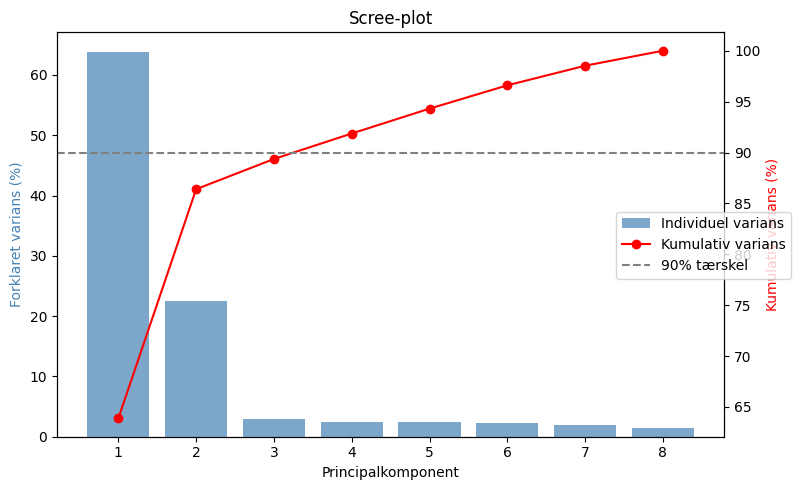

Komponenter til ≥ 90%: 4
PC1: 63.88%  —  kumulativ: 63.88%
PC2: 22.51%  —  kumulativ: 86.40%
PC3: 2.97%  —  kumulativ: 89.36%
PC4: 2.50%  —  kumulativ: 91.87%
PC5: 2.44%  —  kumulativ: 94.31%
PC6: 2.29%  —  kumulativ: 96.60%
PC7: 1.92%  —  kumulativ: 98.52%
PC8: 1.48%  —  kumulativ: 100.00%


In [78]:
# Q101 — Scree-plot
np.random.seed(7)
X_raw = np.random.randn(100, 8)
X_raw[:, 0] *= 5
X_raw[:, 1] *= 3

# PCA:
X_c          = X_raw - np.mean(X_raw, axis=0)
C            = (X_c.T @ X_c) / (len(X_c) - 1)
eigenvals, _ = np.linalg.eigh(C)
eigenvals    = np.sort(eigenvals)[::-1]
varians_pct  = eigenvals / np.sum(eigenvals) * 100
kumulativ    = np.cumsum(varians_pct)

# Hvor mange komponenter til ≥ 90%?:
n_komponenter = np.argmax(kumulativ >= 90) + 1

# Plot scree-plot:
fig, ax1     = plt.subplots(figsize=(8, 5))
x_pos        = range(1, len(eigenvals)+1)

ax1.bar(x_pos, varians_pct, color='steelblue', alpha=0.7, label='Individuel varians')
ax1.set_xlabel('Principalkomponent')
ax1.set_ylabel('Forklaret varians (%)', color='steelblue')
ax1.set_xticks(x_pos)

ax2          = ax1.twinx()
ax2.plot(x_pos, kumulativ, 'ro-', label='Kumulativ varians')
ax2.axhline(y=90, color='gray', linestyle='--', label='90% tærskel')
ax2.set_ylabel('Kumulativ varians (%)', color='red')

plt.title('Scree-plot')
fig.legend(loc='center right')
plt.tight_layout()
plt.show()

print(f"Komponenter til ≥ 90%: {n_komponenter}")
for i, (v, k) in enumerate(zip(varians_pct, kumulativ)):
    print(f"PC{i+1}: {v:.2f}%  —  kumulativ: {k:.2f}%")


---

### Q102 *(GAI er ikke tilladt)*
**Hvad er SVD-baseret GLM?**  
Skriv formlen: Givet $X = U\Sigma V^T$, hvad er $\hat{\beta}$?  
Hvornår er SVD-metoden bedre end normalligningen $(X^TX)^{-1}X^Ty$?


#### SVD-baseret GLM

Givet $X = U\Sigma V^T$ er den mindste kvadraters løsning:

$$\hat{\boldsymbol{\beta}} = X^+\mathbf{y} = V\Sigma^{-1}U^T\mathbf{y}$$

**Hvad er $\hat{\boldsymbol{\beta}}$ trin for trin?**

$$\mathbf{y} \xrightarrow{U^T} \text{projektér på venstre singulærvektorer} \xrightarrow{\Sigma^{-1}} \text{skalér med } 1/\sigma_i \xrightarrow{V} \text{transformér til parameterrummet}$$

---

**Hvornår er SVD bedre end normalligningen?**

Normalligningen $(X^TX)^{-1}X^T\mathbf{y}$ har to svagheder:

1. **Kvadrerer konditionstallet** — $\kappa(X^TX) = \kappa(X)^2$, hvilket
   forstærker numeriske fejl voldsomt ved næsten-singulære matricer.

2. **Fejler ved singulær $X^TX$** — hvis $X$ ikke har fuld rang eksisterer
   $(X^TX)^{-1}$ ikke overhovedet.

SVD håndterer begge problemer:
- Arbejder direkte på $X$ uden at kvadrere konditionstallet
- Håndterer singulære og rektangulære matricer via pseudoinversen
- Næsten-nul singulærværdier kan trunkeres frem for at eksplodere

---

> **Kort sagt:** SVD-baseret GLM er normalligningens robuste storebror —
> den finder præcis den samme løsning når alt er pænt, men overlever
> situationer hvor normalligningen bryder sammen numerisk eller algebraisk.
> I praksis bør SVD foretrækkes når data er højtdimensionelt eller korreleret.

In [79]:
# Q102 — SVD-baseret GLM
hours  = np.array([3, 5, 6, 8, 9, 4, 7], dtype=float)
scores = np.array([55, 70, 75, 88, 90, 62, 82], dtype=float)
X = np.column_stack([hours, np.ones(len(hours))])

# Løs med SVD: beta = V @ diag(1/S) @ U.T @ y (thin SVD):
U, S, Vt    = np.linalg.svd(X, full_matrices=False)
beta_SVD    = Vt.T @ np.diag(1/S) @ U.T @ scores

# Sammenlign med np.linalg.lstsq:
beta_lstsq  = np.linalg.lstsq(X, scores, rcond=None)[0]
verificer   = np.allclose(beta_SVD, beta_lstsq)

print(f"β via SVD:    {beta_SVD.round(4)}")
print(f"β via lstsq:  {beta_lstsq.round(4)}")
print(f"Verificering: {verificer}")
print(f"Model: y = {beta_SVD[0]:.4f}x + {beta_SVD[1]:.4f}")


β via SVD:    [ 6.0357 38.3571]
β via lstsq:  [ 6.0357 38.3571]
Verificering: True
Model: y = 6.0357x + 38.3571


### Q103 *(GAI er ikke tilladt)*
**Skriv formlen for $A^{-1}$ via LU:**  
$A^{-1} = U^{-1} L^{-1} P^T$  
Forklar rækkefølgen (husk: $(PLU)^{-1} = ?$).


#### $A^{-1}$ via LU

$$A = PLU \implies A^{-1} = (PLU)^{-1} = U^{-1}L^{-1}P^{-1} = U^{-1}L^{-1}P^T$$

**Rækkefølgen forklaret:**

Vi bruger $(ABC)^{-1} = C^{-1}B^{-1}A^{-1}$ — rækkefølgen vender om:

$$A^{-1} = \underbrace{U^{-1}}_{\text{3. invertér øvre trekant}} \cdot \underbrace{L^{-1}}_{\text{2. invertér nedre trekant}} \cdot \underbrace{P^T}_{\text{1. fortryd rækkeombytning}}$$

**Hvorfor $P^{-1} = P^T$?**
$P$ er ortogonal — permutationsmatricer er altid ortogonale,
så $P^{-1} = P^T$ er gratis.

**Hvorfor er $L^{-1}$ og $U^{-1}$ billige?**
Trekantssystemer løses med simpel substitution — langt billigere
end en fuld matrixinversion.

---

> **Kort sagt:** LU gør inversionen billig ved at splitte det tunge
> arbejde i tre simple trin — fortryd rækkeombytningen, invertér
> nedre trekant, invertér øvre trekant.
> Hver operation er triviel sammenlignet med direkte inversion.

In [80]:
# Q103 — LU-baseret invers
A = np.array([[3, 1, 2],
              [0, 4, 1],
              [2, 1, 3]], dtype=float)
P, L, U = scipy.linalg.lu(A)

# LU-baseret invers:
A_inv_lu    = np.linalg.inv(U) @ np.linalg.inv(L) @ P.T

# Verificer mod np.linalg.inv(A):
A_inv_numpy = np.linalg.inv(A)
verificer   = np.allclose(A_inv_lu, A_inv_numpy)

print(f"A⁻¹ via LU:\n{A_inv_lu.round(4)}\n")
print(f"A⁻¹ via numpy:\n{A_inv_numpy.round(4)}\n")
print(f"Verificering: {verificer}")


A⁻¹ via LU:
[[ 0.5789 -0.0526 -0.3684]
 [ 0.1053  0.2632 -0.1579]
 [-0.4211 -0.0526  0.6316]]

A⁻¹ via numpy:
[[ 0.5789 -0.0526 -0.3684]
 [ 0.1053  0.2632 -0.1579]
 [-0.4211 -0.0526  0.6316]]

Verificering: True


---

### Q104 *(GAI er ikke tilladt)*
**Verificer to vigtige PCA-egenskaber i ord:**

1. *Variansen af PC$_i$ = egenværdi $\lambda_i$* — forklar hvorfor dette holder matematisk.
2. *PC-komponenterne er ukorrelerede* — hvorfor garanterer PCA dette? (Hint: egenvektorer til en symmetrisk matrix er ortogonale)


#### To vigtige PCA-egenskaber

**1. Variansen af $PC_i = \lambda_i$**

Projektionen på den $i$'te principalkomponent er:

$$\mathbf{z}_i = X_c\mathbf{v}_i$$

Variansen af denne projektion er:

$$\text{var}(\mathbf{z}_i) = \frac{\mathbf{z}_i^T\mathbf{z}_i}{n-1} = \frac{\mathbf{v}_i^T X_c^T X_c \mathbf{v}_i}{n-1} = \mathbf{v}_i^T C \mathbf{v}_i$$

Da $\mathbf{v}_i$ er egenvektor til $C$ med egenværdi $\lambda_i$:

$$\mathbf{v}_i^T C \mathbf{v}_i = \mathbf{v}_i^T \lambda_i \mathbf{v}_i = \lambda_i \underbrace{\|\mathbf{v}_i\|^2}_{=1} = \lambda_i$$

Variansen af $PC_i$ er præcis $\lambda_i$ — egenværdien måler direkte
hvor meget varians den tilhørende komponent forklarer.

---

**2. PC-komponenterne er ukorrelerede**

Kovariansen mellem $PC_i$ og $PC_j$ ($i \neq j$) er:

$$\text{cov}(\mathbf{z}_i, \mathbf{z}_j) = \mathbf{v}_i^T C \mathbf{v}_j = \lambda_j \underbrace{\mathbf{v}_i^T \mathbf{v}_j}_{=0} = 0$$

Kovariansen er nul fordi spektralsætningen garanterer at egenvektorer
til en symmetrisk matrix er **ortogonale** — $\mathbf{v}_i \perp \mathbf{v}_j$.
Nul kovarians betyder nul korrelation — komponenterne er ukorrelerede per konstruktion.

---

> **Kort sagt:** PCA's to vigtigste egenskaber følger begge direkte
> fra spektralsætningen — symmetriske matricer giver ortogonale egenvektorer,
> og ortogonalitet sikrer både at variansen er præcis $\lambda_i$
> og at komponenterne er fuldstændigt ukorrelerede.

---

### Q105 *(GAI er ikke tilladt)*
**Bevis kortfattet: For en ortogonal matrix $Q$ er $|\det(Q)| = 1$.**  
Brug $Q^T Q = I$ og egenskaber ved determinanter.


Hint: $\det(Q^T Q) = \det(Q^T) \cdot \det(Q) = \det(Q)^2 = \det(I) = 1$

#### Bevis: $|\det(Q)| = 1$ for en ortogonal matrix

**Udgangspunkt:** $Q^TQ = I$

Tager vi determinanten på begge sider:

$$\det(Q^TQ) = \det(I) = 1$$

Vi bruger at $\det(AB) = \det(A)\det(B)$ og $\det(Q^T) = \det(Q)$:

$$\det(Q^T)\det(Q) = \det(Q)^2 = 1$$

$$\implies \det(Q) = \pm 1 \implies |\det(Q)| = 1$$

---

**Hvad betyder fortegnet?**

- $\det(Q) = +1$ — ren rotation, ingen spejling
- $\det(Q) = -1$ — rotation med spejling

---

> **Kort sagt:** Beviset følger direkte fra $Q^TQ = I$ med to
> determinantregler — multiplikationsreglen og $\det(Q^T) = \det(Q)$.
> Resultatet $\det(Q)^2 = 1$ tvinger determinanten til præcis $\pm 1$.


---

### Q106 *(GAI er ikke tilladt)*
**Hvad er den præcise forskel på covB og covW i GED/LDA?**  
Skriv beregningsformlen for begge (som de bruges i koden), og forklar hvert led.

covB: $S_b = \sum_c \frac{1}{n_c}(X_c - \bar{X}_c)^T(X_c - \bar{X}_c)$  
covW: $S_w = \frac{1}{N}(X - \bar{X})^T(X - \bar{X})$


#### covB og covW i GED/LDA

covB (between-class): Beregnes som summen af kovarianser inden for HVER klasse,
centreret om klassens eget gennemsnit. Måler hvor kompakte klasserne er internt.

covW (within-class): Beregnes som den GLOBALE kovarians — alle datapunkter
centreret om det samlede gennemsnit. Måler den totale spredning på tværs af klasser.

GED maksimerer covB/covW — vi vil have kompakte klasser (stor covB)
og lille global spredning (lille covW).

**covW — Within-class covariance:**

$$S_W = \frac{1}{N}(X - \bar{X})^T(X - \bar{X})$$

| Led | Betydning |
|-----|-----------|
| $N$ | Totalt antal observationer |
| $X - \bar{X}$ | Hver observation centreret omkring det **globale** gennemsnit |
| $(X-\bar{X})^T(X-\bar{X})$ | Samlet spredning i hele datasættet |

covW måler **den totale spredning** inden i alle klasser samlet —
hvor kompakte klasserne er internt.

---

**covB — Between-class covariance:**

$$S_B = \sum_c \frac{1}{n_c}(X_c - \bar{X}_c)^T(X_c - \bar{X}_c)$$

| Led | Betydning |
|-----|-----------|
| $c$ | Klasse-indeks |
| $n_c$ | Antal observationer i klasse $c$ |
| $X_c$ | Alle observationer i klasse $c$ |
| $\bar{X}_c$ | Middelværdien af klasse $c$ |
| $(X_c - \bar{X}_c)^T(X_c - \bar{X}_c)$ | Spredning inden i klasse $c$ |

covB måler **spredningen inden i hver enkelt klasse** — normaliseret
med klassestørrelsen $n_c$ så store klasser ikke dominerer.

---

**GED-målet:**

$$J(\mathbf{w}) = \frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}}$$

Vi maksimerer $S_B$ (stor spredning mellem klasser) og minimerer $S_W$
(lille spredning inden i klasser) — skarp adskillelse, kompakte klasser.

---

> **Kort sagt:** covW beskriver hvor rodet det er *inden i* klasserne,
> og covB beskriver hvor langt *fra hinanden* klasserne ligger.
> GED finder den retning der maksimerer forholdet mellem de to —
> mest mulig adskillelse for mindst mulig intern spredning.

---

### Q107 *(GAI er ikke tilladt)*
**Bevis med ord:**  
Cauchy-Schwarz: $|u \cdot v| \leq \|u\| \cdot \|v\|$ garanterer $\cos(\theta) = \frac{u \cdot v}{\|u\|\|v\|} \in [-1, 1]$.

Vis algebraisk, at hvis Cauchy-Schwarz holder, så er $\left|\frac{u \cdot v}{\|u\|\|v\|}\right| \leq 1$.


#### Algebraisk bevis: $\cos(\theta) \in [-1, 1]$

**Udgangspunkt:** Cauchy-Schwarz uligheden:

$$|\mathbf{u} \cdot \mathbf{v}| \leq \|\mathbf{u}\| \cdot \|\mathbf{v}\|$$

**Trin 1:** Da $\|\mathbf{u}\| > 0$ og $\|\mathbf{v}\| > 0$ for ikke-nulvektorer,
kan vi dividere begge sider med $\|\mathbf{u}\| \cdot \|\mathbf{v}\|$:

$$\frac{|\mathbf{u} \cdot \mathbf{v}|}{\|\mathbf{u}\| \cdot \|\mathbf{v}\|} \leq 1$$

**Trin 2:** Absolutværdien af en brøk er brøken af absolutværdierne:

$$\left|\frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\| \cdot \|\mathbf{v}\|}\right| \leq 1$$

**Trin 3:** Dette betyder præcis:

$$-1 \leq \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\| \cdot \|\mathbf{v}\|} \leq 1$$

Præcis det interval $\arccos$ er defineret på — så $\theta$ er altid veldefineret. $\square$

---

> **Kort sagt:** Beviset er én simpel division — Cauchy-Schwarz siger
> at tælleren aldrig kan overstige nævneren, så brøken er altid i $[-1, 1]$.
> Det er garantien for at $\cos(\theta)$ altid giver en gyldig vinkel.

---

### Q108 *(GAI er ikke tilladt)*
**Hvorfor bruger vi `ddof=1` (eller $n-1$ i nævneren), når vi beregner kovariansmatricen i PCA?**  
Hvad er Bessel's korrektion, og hvad estimerer vi?


#### Bessel's korrektion — hvorfor $n-1$?

**Hvad estimerer vi?**
I PCA arbejder vi næsten altid med en **stikprøve** af data — ikke
hele populationen. Vi ønsker at estimere populationens sande kovariansmatrix
ud fra vores begrænsede stikprøve.

---

**Hvorfor ikke $n$?**

Med $n$ i nævneren beregner vi:

$$C = \frac{1}{n}X_c^TX_c$$

Dette er et **biased estimat** — det undervurderer systematisk den sande
populationsvarians. Intuitivt fordi vi centrerer data omkring stikprøvens
gennemsnit $\bar{x}$, ikke populationens sande gennemsnit $\mu$ —
det "stjæler" én frihedsgrad.

**Med $n-1$ (Bessels korrektion):**

$$C = \frac{1}{n-1}X_c^TX_c$$

Dette giver et **ubiased estimat** — i gennemsnit rammer vi den sande
populationsvarians præcist.

$$\mathbb{E}\left[\frac{1}{n-1}X_c^TX_c\right] = \Sigma_{\text{population}}$$

---

**`ddof=1` i Python:**
`ddof` står for *degrees of freedom* — ved at sætte `ddof=1` dividerer
`numpy` med $n-1$ frem for $n$.

---

> **Kort sagt:** Vi bruger $n-1$ fordi vi estimerer fra en stikprøve —
> centrering omkring stikprøvens gennemsnit koster én frihedsgrad,
> og $n-1$ kompenserer for dette så vi ikke systematisk undervurderer variansen.

In [81]:
import numpy as np

x           = np.array([2, 4, 6, 8, 10], dtype=float)

var_biased   = np.var(x, ddof=0)   # dividerer med n
var_unbiased = np.var(x, ddof=1)   # dividerer med n-1

print(f"Varians (n):   {var_biased:.4f}   — biased")
print(f"Varians (n-1): {var_unbiased:.4f} — ubiased (Bessel)")

Varians (n):   8.0000   — biased
Varians (n-1): 10.0000 — ubiased (Bessel)


---

### Q109 *(GAI er ikke tilladt)*
**Kort svar — sandt eller falsk? Forklar hvert:**

1. Alle kvadratiske matricer kan diagonaliseres.
2. En symmetrisk matrix har altid reelle egenværdier.
3. Egenvektorer til en symmetrisk matrix er altid ortogonale.
4. SVD virker kun for kvadratiske matricer.
5. En ortogonal matrix bevarer altid vektorers længder.
6. Det(A) = 0 medfører, at A's nullrum kun indeholder nulvektoren.
7. Rang(A) + nullitet(A) = antal rækker i A.


1. **FALSK** — En matrix kan kun diagonaliseres hvis den har $n$ lineært
   uafhængige egenvektorer. Matricer med gentagne egenværdier og for få
   tilhørende egenvektorer (defekte matricer) kan ikke diagonaliseres.

2. **SANDT** — Spektralsætningen garanterer at alle egenværdier er reelle
   for symmetriske matricer. Ingen undtagelser.

3. **SANDT** — Spektralsætningen garanterer ortogonale egenvektorer for
   forskellige egenværdier. Ved gentagne egenværdier kan vi altid
   konstruere ortogonale egenvektorer via Gram-Schmidt.

4. **FALSK** — SVD virker for **alle** $m \times n$ matricer, uanset form.
   Det er netop SVD's styrke over egendekomposition der kun virker for kvadratiske matricer.

5. **SANDT** — Per definition er $\|Q\mathbf{v}\|_2 = \|\mathbf{v}\|_2$ for
   alle ortogonale matricer $Q$. Det følger direkte fra $Q^TQ = I$.

6. **FALSK** — $\det(A) = 0$ betyder præcis det modsatte — nullrummet
   indeholder **flere end bare nulvektoren**. Der findes en ikke-triviel
   løsning til $A\mathbf{x} = \mathbf{0}$.

7. **FALSK** — Rang-nullitets-sætningen siger at rang + nullitet = **antal søjler**,
   ikke antal rækker:
   $$\text{rank}(A) + \text{nullity}(A) = n \quad \text{(antal søjler)}$$


---

### Q110 — Stor sammenfatningsopgave *(GAI er ikke tilladt)*

Forklar med *egne ord* (2-4 sætninger pr. punkt), hvad følgende er og hvornår du bruger det:

| Metode | Hvad er det? | Hvornår bruger du det? |
|---|---|---|
| LU-dekomposition | | |
| QR-dekomposition | | |
| Egendekomposition | | |
| SVD | | |
| PCA | | |
| GED/LDA | | |
| Mindste kvadrater (GLM) | | |
| Low-rank approksimation | | |


| Metode | Hvad er det? | Hvornår bruger du det? |
|--------|--------------|------------------------|
| **LU-dekomposition** | Splitter $A = PLU$ i en permutation, nedre og øvre trekantsmatrix. Gør løsning af ligningssystemer billigt ved at forberede $A$ én gang. | Når du skal løse $A\mathbf{x} = \mathbf{b}$ for mange forskellige $\mathbf{b}$ med samme $A$, eller beregne $\det(A)$ effektivt. |
| **QR-dekomposition** | Splitter $A = QR$ i en ortogonal matrix og øvre trekantsmatrix. Numerisk stabil fordi $Q$ har konditionstal 1. | Når du løser mindste kvadrater eller inverterer matricer og vil undgå konditionstals-problemer fra normalligningen. |
| **Egendekomposition** | Finder $A = V\Lambda V^{-1}$ — matrixens naturlige retninger og skaleringer. Kun mulig for kvadratiske matricer med $n$ uafhængige egenvektorer. | Når du vil forstå en matrices geometriske effekt, beregne $A^k$, eller diagonalisere en symmetrisk matrix. |
| **SVD** | Splitter $A = U\Sigma V^T$ — virker på **alle** matricer. Generalisering af egendekomposition til rektangulære og singulære matricer. | Når du beregner pseudoinvers, low-rank approksimation, rang, eller vil have numerisk stabil GLM-løsning. |
| **PCA** | Finder de retninger i data der indeholder mest varians via egendekomposition af kovariansmatricen. Reducerer dimensioner uden at miste for meget information. | Når du vil reducere dimensionalitet, visualisere højtdimensionelt data, eller fjerne støj fra data. |
| **GED/LDA** | Løser $S_B\mathbf{v} = \lambda S_W\mathbf{v}$ — finder retningen der maksimerer adskillelsen mellem klasser relativt til intern spredning. Kræver klasseetiketter. | Når målet er klassifikation og du vil finde den retning der bedst separerer kendte klasser. |
| **Mindste kvadrater (GLM)** | Finder $\hat{\boldsymbol{\beta}}$ der minimerer $\|X\boldsymbol{\beta} - \mathbf{y}\|_2^2$ — den bedst mulige lineære tilpasning til data. | Når du har flere ligninger end ubekendte og vil finde den bedste lineære model der beskriver sammenhængen i data. |
| **Low-rank approksimation** | Approksimerer $A \approx A_k = \sum_{i=1}^k \sigma_i\mathbf{u}_i\mathbf{v}_i^T$ ved at beholde de $k$ vigtigste SVD-lag. Eckart-Young garanterer optimalitet. | Når du vil komprimere data, fjerne støj, eller reducere kompleksitet ved at kassere de mindste singulærværdier. |